# Milestone 1: Insurance Price Prediction - Data Report, EDA, and Preprocessing

In [1]:
from IPython.display import HTML, display
display(HTML('\n    <style>\n    body, .jp-Notebook {\n        background: #F8FAFC;\n        color: #1F2937;\n        font-family: Inter, Segoe UI, Arial, sans-serif;\n    }\n    h1 {\n        color: #12355B;\n        font-size: 2.15rem;\n        font-weight: 800;\n        letter-spacing: 0;\n        padding: 0.55rem 0 0.35rem;\n        border-bottom: 4px solid #2A9D8F;\n    }\n    h2 {\n        color: #12355B;\n        font-size: 1.45rem;\n        font-weight: 760;\n        letter-spacing: 0;\n        margin-top: 1.45rem;\n        padding: 0.35rem 0 0.35rem 0.7rem;\n        border-left: 5px solid #2A9D8F;\n        background: linear-gradient(90deg, #E8F4F1 0%, rgba(232,244,241,0) 78%);\n        border-radius: 6px;\n    }\n    h3 {\n        color: #457B9D;\n        font-size: 1.12rem;\n        font-weight: 720;\n        margin-top: 1.1rem;\n    }\n    p, li {\n        font-size: 0.98rem;\n        line-height: 1.58;\n    }\n    div.insight-card {\n        background: #FFFFFF;\n        border: 1px solid #D9E6EF;\n        border-left: 5px solid #2A9D8F;\n        border-radius: 8px;\n        box-shadow: 0 6px 18px rgba(18, 53, 91, 0.08);\n        margin: 0.85rem 0 1.05rem;\n        padding: 0.95rem 1.05rem;\n    }\n    div.insight-row {\n        display: flex;\n        gap: 0.65rem;\n        align-items: flex-start;\n        margin: 0.25rem 0;\n    }\n    span.insight-label {\n        border-radius: 999px;\n        color: #FFFFFF;\n        display: inline-block;\n        font-size: 0.74rem;\n        font-weight: 760;\n        letter-spacing: 0;\n        min-width: 5.25rem;\n        padding: 0.18rem 0.55rem;\n        text-align: center;\n    }\n    span.insight-label.tech { background: #12355B; }\n    span.insight-label.biz { background: #2A9D8F; }\n    span.insight-label.caution { background: #E76F51; }\n    div.output_png img, img {\n        background: #FFFFFF;\n        border: 1px solid #DDE7F0;\n        border-radius: 8px;\n        box-shadow: 0 8px 24px rgba(18, 53, 91, 0.10);\n        padding: 6px;\n    }\n    table.dataframe {\n        border-collapse: collapse;\n        border: 1px solid #D9E6EF;\n        border-radius: 8px;\n        box-shadow: 0 4px 14px rgba(18, 53, 91, 0.06);\n        overflow: hidden;\n    }\n    table.dataframe thead tr {\n        background: #12355B;\n        color: #FFFFFF;\n    }\n    table.dataframe th, table.dataframe td {\n        border: 1px solid #E5E7EB;\n        padding: 0.42rem 0.55rem;\n        font-size: 0.86rem;\n    }\n    table.dataframe tbody tr:nth-child(even) {\n        background: #F3F8FA;\n    }\n    div.input_area {\n        border-radius: 8px;\n        border: 1px solid #D9E6EF;\n    }\n    code {\n        color: #12355B;\n    }\n    </style>\n    '))

## 1. Project Context and Business Objective

The capstone objective is to predict `insurance_cost` from applicant health, lifestyle, habit,
demographic, medical-history, and insurance-history variables. Milestone 1 focuses on data
understanding, EDA, preprocessing decisions, and evidence-backed business insight before
the Milestone 2 modeling workflow.

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>Milestone 1 is treated as the analytical foundation: data quality, target behavior, missingness, and important relationships are documented before model fitting.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>A pricing model is only useful if reviewers can see why the data is usable, what the target means, and which applicant characteristics drive the estimate.</span>
    </div>

</div>

## 2. Import Libraries and Set Paths

In [2]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
if not (ROOT / "Insurance Data.csv").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from insurance_modeling import RAW_MODEL_COLUMNS, clean_column_names
from run_all import (
    add_report_features,
    ensure_dirs,
    generate_eda_figures,
    save_profile_tables,
    set_visual_theme,
    summarize_eda,
    write_milestone1_rubric_coverage_matrix,
)

TABLE_DIR = ROOT / "outputs" / "tables"
FIG_DIR = ROOT / "outputs" / "figures"
MODEL_DIR = ROOT / "outputs" / "models"
REPORT_DIR = ROOT / "outputs" / "reports"

ensure_dirs()
set_visual_theme()
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)
print(ROOT)

C:\Users\anupk\Documents\PGP\Capstone


<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>The notebook resolves the project root, creates output folders, and imports the same helper functions used by the automated pipeline.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>A reviewer can execute the notebook from the supplied dataset without needing pre-generated EDA tables or figures.</span>
    </div>

</div>

## 3. End-to-End EDA Artifact Generation

In [3]:
DATA_PATH = ROOT / "Insurance Data.csv"
raw_df = pd.read_csv(DATA_PATH)
report_df = add_report_features(raw_df)
tables = save_profile_tables(raw_df, report_df)
figures = generate_eda_figures(raw_df, report_df)
eda_summary = summarize_eda(report_df)
rubric_path = write_milestone1_rubric_coverage_matrix()

print(f"Loaded dataset: {DATA_PATH.name} -> {raw_df.shape[0]:,} rows, {raw_df.shape[1]:,} columns")
print(f"Generated {len(tables)} named profile tables and {len(figures)} EDA figures.")
print(f"Rubric coverage matrix: {rubric_path.relative_to(ROOT)}")

Loaded dataset: Insurance Data.csv -> 25,000 rows, 24 columns
Generated 24 named profile tables and 53 EDA figures.
Rubric coverage matrix: outputs\reports\milestone1_rubric_coverage_matrix.csv


<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>This cell regenerates the Milestone 1 tables, cleaned analysis dataset, univariate plot index, and EDA figures directly from `Insurance Data.csv`.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The rest of the notebook reads artifacts created in this run, so the HTML/notebook evidence is reproducible from the raw dataset.</span>
    </div>

</div>

## 4. Load Raw Dataset

In [4]:
raw_df = pd.read_csv(ROOT / "Insurance Data.csv")
raw_df.shape, raw_df.size

((25000, 24), 600000)

In [5]:
display(raw_df.head())
display(raw_df.tail())
display(raw_df.sample(5, random_state=42))

,applicant_id,years_of_insurance_with_us,regular_checkup_lasy_year,adventure_sports,Occupation,visited_doctor_last_1_year,cholesterol_level,daily_avg_steps,age,heart_decs_history,other_major_decs_history,Gender,avg_glucose_level,bmi,smoking_status,Year_last_admitted,Location,weight,covered_by_any_other_company,Alcohol,exercise,weight_change_in_last_one_year,fat_percentage,insurance_cost
0,5000,3,1,1,Salried,2,125 to 150,4866,28,1,0,Male,97,31.2,Unknown,NaN,Chennai,67,N,Rare,Moderate,1,25,20978
1,5001,0,0,0,Student,4,150 to 175,6411,50,0,0,Male,212,34.2,formerly smoked,NaN,Jaipur,58,N,Rare,Moderate,3,27,6170
2,5002,1,0,0,Business,4,200 to 225,4509,68,0,0,Female,166,40.4,formerly smoked,NaN,Jaipur,73,N,Daily,Extreme,0,32,28382
3,5003,7,4,0,Business,2,175 to 200,6214,51,0,0,Female,109,22.9,Unknown,NaN,Chennai,71,Y,Rare,No,3,37,27148
4,5004,3,1,0,Student,2,150 to 175,4938,44,0,1,Male,118,26.5,never smoked,2004.0,Bangalore,74,N,No,Extreme,0,34,29616


,applicant_id,years_of_insurance_with_us,regular_checkup_lasy_year,adventure_sports,Occupation,visited_doctor_last_1_year,cholesterol_level,daily_avg_steps,age,heart_decs_history,other_major_decs_history,Gender,avg_glucose_level,bmi,smoking_status,Year_last_admitted,Location,weight,covered_by_any_other_company,Alcohol,exercise,weight_change_in_last_one_year,fat_percentage,insurance_cost
24995,29995,3,0,0,Salried,4,225 to 250,5614,22,0,0,Male,145,36.1,smokes,2000.0,Kanpur,79,Y,Rare,Moderate,4,40,39488
24996,29996,6,0,0,Business,4,200 to 225,4719,58,0,0,Male,134,31.3,never smoked,2009.0,Kanpur,66,N,Rare,Moderate,2,28,14808
24997,29997,7,0,1,Student,2,150 to 175,5624,34,0,1,Male,151,NaN,Unknown,NaN,Bhubaneswar,76,N,Rare,Moderate,1,35,33318
24998,29998,1,0,0,Salried,2,225 to 250,10777,27,0,0,Male,66,26.6,Unknown,NaN,Surat,74,N,Rare,Moderate,0,40,30850
24999,29999,8,2,0,Business,4,150 to 175,5882,22,1,0,Male,245,41.6,formerly smoked,2014.0,Chennai,57,N,No,No,4,21,6170


,applicant_id,years_of_insurance_with_us,regular_checkup_lasy_year,adventure_sports,Occupation,visited_doctor_last_1_year,cholesterol_level,daily_avg_steps,age,heart_decs_history,other_major_decs_history,Gender,avg_glucose_level,bmi,smoking_status,Year_last_admitted,Location,weight,covered_by_any_other_company,Alcohol,exercise,weight_change_in_last_one_year,fat_percentage,insurance_cost
6868,11868,3,3,0,Student,3,125 to 150,5207,51,0,0,Male,93,24.5,formerly smoked,2013.0,Kolkata,59,N,Rare,Moderate,3,38,7404
24016,29016,6,0,0,Student,3,125 to 150,5000,67,0,0,Male,267,26.0,never smoked,2006.0,Delhi,66,N,Rare,Extreme,2,38,20978
9668,14668,3,2,0,Salried,7,125 to 150,4570,38,0,0,Female,90,21.5,Unknown,2009.0,Ahmedabad,63,Y,Rare,Moderate,2,25,13574
13640,18640,1,0,0,Business,4,150 to 175,6515,32,0,0,Female,228,19.4,formerly smoked,NaN,Mumbai,82,N,Rare,No,1,21,38254
14018,19018,1,0,0,Business,2,175 to 200,6859,69,0,0,Male,133,28.1,smokes,NaN,Ahmedabad,70,Y,Rare,Moderate,2,37,20978


<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>The raw file loads successfully with 25,000 rows and 24 original columns, and visual inspection confirms mixed numeric and categorical applicant fields.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The dataset is large enough for supervised learning while still small enough for transparent EDA and report-level validation.</span>
    </div>

</div>

## 5. Initial Data Inspection

In [6]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   applicant_id                    25000 non-null  int64  
 1   years_of_insurance_with_us      25000 non-null  int64  
 2   regular_checkup_lasy_year       25000 non-null  int64  
 3   adventure_sports                25000 non-null  int64  
 4   Occupation                      25000 non-null  str    
 5   visited_doctor_last_1_year      25000 non-null  int64  
 6   cholesterol_level               25000 non-null  str    
 7   daily_avg_steps                 25000 non-null  int64  
 8   age                             25000 non-null  int64  
 9   heart_decs_history              25000 non-null  int64  
 10  other_major_decs_history        25000 non-null  int64  
 11  Gender                          25000 non-null  str    
 12  avg_glucose_level               25000 non-n

In [7]:
display(raw_df.describe().T)
display(raw_df.describe(include="object").T)
display(raw_df.nunique().sort_values())
display(raw_df.isna().sum().sort_values(ascending=False))
print("Duplicate rows:", raw_df.duplicated().sum())

,count,mean,std,min,25%,50%,75%,max
applicant_id,25000.0,17499.500000,7217.022701,5000.0,11249.75,17499.5,23749.25,29999.0
years_of_insurance_with_us,25000.0,4.089040,2.606612,0.0,2.00,4.0,6.00,8.0
regular_checkup_lasy_year,25000.0,0.773680,1.199449,0.0,0.00,0.0,1.00,5.0
adventure_sports,25000.0,0.081720,0.273943,0.0,0.00,0.0,0.00,1.0
visited_doctor_last_1_year,25000.0,3.104200,1.141663,0.0,2.00,3.0,4.00,12.0
daily_avg_steps,25000.0,5215.889320,1053.179748,2034.0,4543.00,5089.0,5730.00,11255.0
age,25000.0,44.918320,16.107492,16.0,31.00,45.0,59.00,74.0
heart_decs_history,25000.0,0.054640,0.227281,0.0,0.00,0.0,0.00,1.0
other_major_decs_history,25000.0,0.098160,0.297537,0.0,0.00,0.0,0.00,1.0
avg_glucose_level,25000.0,167.530000,62.729712,57.0,113.00,168.0,222.00,277.0


C:\Users\anupk\AppData\Local\Temp\ipykernel_25200\1070344443.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(raw_df.describe(include="object").T)


,count,unique,top,freq
Occupation,25000,3,Student,10169
cholesterol_level,25000,5,150 to 175,8763
Gender,25000,2,Male,16422
smoking_status,25000,4,never smoked,9249
Location,25000,15,Bangalore,1742
covered_by_any_other_company,25000,2,N,17418
Alcohol,25000,3,Rare,13752
exercise,25000,3,Moderate,14638


adventure_sports                      2
Gender                                2
other_major_decs_history              2
heart_decs_history                    2
covered_by_any_other_company          2
Occupation                            3
Alcohol                               3
exercise                              3
smoking_status                        4
cholesterol_level                     5
regular_checkup_lasy_year             6
weight_change_in_last_one_year        7
years_of_insurance_with_us            9
visited_doctor_last_1_year           12
Location                             15
Year_last_admitted                   29
fat_percentage                       32
weight                               45
insurance_cost                       54
age                                  59
avg_glucose_level                   221
bmi                                 465
daily_avg_steps                    4914
applicant_id                      25000
dtype: int64

Year_last_admitted                11881
bmi                                 990
applicant_id                          0
years_of_insurance_with_us            0
Occupation                            0
visited_doctor_last_1_year            0
regular_checkup_lasy_year             0
adventure_sports                      0
daily_avg_steps                       0
cholesterol_level                     0
age                                   0
heart_decs_history                    0
Gender                                0
other_major_decs_history              0
avg_glucose_level                     0
smoking_status                        0
Location                              0
weight                                0
covered_by_any_other_company          0
Alcohol                               0
exercise                              0
weight_change_in_last_one_year        0
fat_percentage                        0
insurance_cost                        0
dtype: int64

Duplicate rows: 0


<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>The initial inspection finds no duplicate rows, a unique `applicant_id`, and missing values only in BMI and admission-year fields.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The data can move forward after targeted preprocessing rather than broad row deletion or aggressive cleanup.</span>
    </div>

</div>

## 6. Data Dictionary and Variable Understanding

In [8]:
dataset_profile = pd.DataFrame(
    {
        "Metric": ["Rows", "Columns", "Cells", "Duplicate rows", "Unique applicant_id"],
        "Value": [raw_df.shape[0], raw_df.shape[1], raw_df.size, raw_df.duplicated().sum(), raw_df["applicant_id"].nunique()],
    }
)
dataset_profile.to_csv(TABLE_DIR / "dataset_profile.csv", index=False)
numeric_summary = raw_df.describe().T.reset_index().rename(columns={"index": "column"})
numeric_summary.to_csv(TABLE_DIR / "numeric_summary.csv", index=False)
display(dataset_profile)
display(numeric_summary.head(12))

,Metric,Value
0,Rows,25000
1,Columns,24
2,Cells,600000
3,Duplicate rows,0
4,Unique applicant_id,25000


,column,count,mean,std,min,25%,50%,75%,max
0,applicant_id,25000.0,17499.500000,7217.022701,5000.0,11249.75,17499.5,23749.25,29999.0
1,years_of_insurance_with_us,25000.0,4.089040,2.606612,0.0,2.00,4.0,6.00,8.0
2,regular_checkup_lasy_year,25000.0,0.773680,1.199449,0.0,0.00,0.0,1.00,5.0
3,adventure_sports,25000.0,0.081720,0.273943,0.0,0.00,0.0,0.00,1.0
4,visited_doctor_last_1_year,25000.0,3.104200,1.141663,0.0,2.00,3.0,4.00,12.0
5,daily_avg_steps,25000.0,5215.889320,1053.179748,2034.0,4543.00,5089.0,5730.00,11255.0
6,age,25000.0,44.918320,16.107492,16.0,31.00,45.0,59.00,74.0
7,heart_decs_history,25000.0,0.054640,0.227281,0.0,0.00,0.0,0.00,1.0
8,other_major_decs_history,25000.0,0.098160,0.297537,0.0,0.00,0.0,0.00,1.0
9,avg_glucose_level,25000.0,167.530000,62.729712,57.0,113.00,168.0,222.00,277.0


In [9]:
data_dictionary = pd.read_csv(TABLE_DIR / "data_dictionary_summary.csv")
variable_types = pd.read_csv(TABLE_DIR / "variable_type_classification.csv")
display(data_dictionary)
display(variable_types[["original_column", "clean_column", "analysis_type", "role", "preprocessing_action"]])

,column,clean_column,dtype,missing,missing_pct,unique_values
0,applicant_id,applicant_id,int64,0,0.00,25000
1,years_of_insurance_with_us,years_of_insurance_with_us,int64,0,0.00,9
2,regular_checkup_lasy_year,regular_checkup_last_year,int64,0,0.00,6
3,adventure_sports,adventure_sports,int64,0,0.00,2
4,Occupation,Occupation,str,0,0.00,3
5,visited_doctor_last_1_year,visited_doctor_last_1_year,int64,0,0.00,12
6,cholesterol_level,cholesterol_level,str,0,0.00,5
7,daily_avg_steps,daily_avg_steps,int64,0,0.00,4914
8,age,age,int64,0,0.00,59
9,heart_decs_history,heart_disease_history,int64,0,0.00,2


,original_column,clean_column,analysis_type,role,preprocessing_action
0,applicant_id,applicant_id,identifier,identifier,retain for audit only; drop from modeling
1,years_of_insurance_with_us,years_of_insurance_with_us,ordinal discrete numeric,predictor,"validate type, preserve for EDA, and feed thro..."
2,regular_checkup_lasy_year,regular_checkup_last_year,ordinal discrete numeric,predictor,normalize misspelled source name; preserve num...
3,adventure_sports,adventure_sports,binary categorical,predictor,"validate type, preserve for EDA, and feed thro..."
4,Occupation,Occupation,nominal categorical,predictor,"validate type, preserve for EDA, and feed thro..."
5,visited_doctor_last_1_year,visited_doctor_last_1_year,ordinal discrete numeric,predictor,"validate type, preserve for EDA, and feed thro..."
6,cholesterol_level,cholesterol_level,ordinal categorical,predictor,retain ordinal category and engineer cholester...
7,daily_avg_steps,daily_avg_steps,continuous numeric,predictor,"validate type, preserve for EDA, and feed thro..."
8,age,age,continuous numeric,predictor,"validate type, preserve for EDA, and feed thro..."
9,heart_decs_history,heart_disease_history,binary categorical,predictor,normalize misspelled source name; preserve num...


<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>The variable classification distinguishes identifiers, the quote-grid target, continuous numeric features, ordinal numeric features, binary flags, and nominal categories.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>`applicant_id` is retained for audit only and excluded from modeling and the Streamlit schema.</span>
    </div>

</div>

## 7. Column Renaming and Data Cleanup

In [10]:
cleaned_df = clean_column_names(raw_df)
renaming = pd.read_csv(TABLE_DIR / "renaming_and_cleanup.csv")
display(renaming)
display(pd.DataFrame({"raw_column": raw_df.columns, "clean_column": cleaned_df.columns}))

,original,cleaned_or_action,reason
0,regular_checkup_lasy_year,regular_checkup_last_year,column typo normalized
1,heart_decs_history,heart_disease_history,column typo normalized
2,other_major_decs_history,other_major_disease_history,column typo normalized
3,Occupation value: Salried,Salaried,category typo normalized
4,applicant_id,dropped from modeling,"unique identifier, not predictive signal"


,raw_column,clean_column
0,applicant_id,applicant_id
1,years_of_insurance_with_us,years_of_insurance_with_us
2,regular_checkup_lasy_year,regular_checkup_last_year
3,adventure_sports,adventure_sports
4,Occupation,Occupation
5,visited_doctor_last_1_year,visited_doctor_last_1_year
6,cholesterol_level,cholesterol_level
7,daily_avg_steps,daily_avg_steps
8,age,age
9,heart_decs_history,heart_disease_history


<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>The cleanup normalizes misspelled source columns and category labels while preserving the original data meaning.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>Clean names reduce downstream coding errors and make the final app schema easier for reviewers to inspect.</span>
    </div>

</div>

## 8. Dataset Profile and Descriptive Statistics

In [11]:
categorical_cols = raw_df.select_dtypes(include=["object"]).columns.tolist()
cat_rows = []
for col in categorical_cols:
    for category, count in raw_df[col].value_counts(dropna=False).items():
        cat_rows.append({"column": col, "category": category, "count": int(count), "pct": round(count / len(raw_df) * 100, 2)})
categorical_frequency = pd.DataFrame(cat_rows)
categorical_frequency.to_csv(TABLE_DIR / "categorical_frequency.csv", index=False)
display(categorical_frequency.head(20))

C:\Users\anupk\AppData\Local\Temp\ipykernel_25200\1000163396.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = raw_df.select_dtypes(include=["object"]).columns.tolist()


,column,category,count,pct
0,Occupation,Student,10169,40.68
1,Occupation,Business,10020,40.08
2,Occupation,Salried,4811,19.24
3,cholesterol_level,150 to 175,8763,35.05
4,cholesterol_level,125 to 150,8339,33.36
5,cholesterol_level,200 to 225,2963,11.85
6,cholesterol_level,175 to 200,2881,11.52
7,cholesterol_level,225 to 250,2054,8.22
8,Gender,Male,16422,65.69
9,Gender,Female,8578,34.31


<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>Descriptive statistics and frequency tables cover both numeric spread and categorical level balance.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>This satisfies the rubric requirement to describe variables before jumping into model building.</span>
    </div>

</div>

## 9. Missing Value Analysis

In [12]:
missing_values = pd.read_csv(TABLE_DIR / "missing_values.csv")
missing_bmi = pd.read_csv(TABLE_DIR / "missing_bmi_profile.csv")
missing_admission = pd.read_csv(TABLE_DIR / "missing_year_last_admitted_profile.csv")
display(missing_values)
display(missing_bmi)
display(missing_admission)

,column,missing_count,missing_pct
0,Year_last_admitted,11881,47.52
1,bmi,990,3.96
2,applicant_id,0,0.00
3,years_of_insurance_with_us,0,0.00
4,Occupation,0,0.00
5,visited_doctor_last_1_year,0,0.00
6,regular_checkup_lasy_year,0,0.00
7,adventure_sports,0,0.00
8,daily_avg_steps,0,0.00
9,cholesterol_level,0,0.00


,bmi_missing,customer_count,mean_cost,median_cost,mean_age,mean_weight,mean_medical_risk,mean_lifestyle_risk
0,False,24010,27160.64,27148.0,44.92,71.62,2.08,2.41
1,True,990,26826.41,27148.0,44.91,71.40,2.84,2.67


,year_last_admitted_missing,customer_count,mean_cost,median_cost,mean_age,mean_bmi,mean_medical_risk,mean_lifestyle_risk
0,False,13119,29384.51,29616.0,44.97,31.23,2.43,2.42
1,True,11881,24677.20,23446.0,44.87,31.42,1.76,2.42


**Missing values by column**

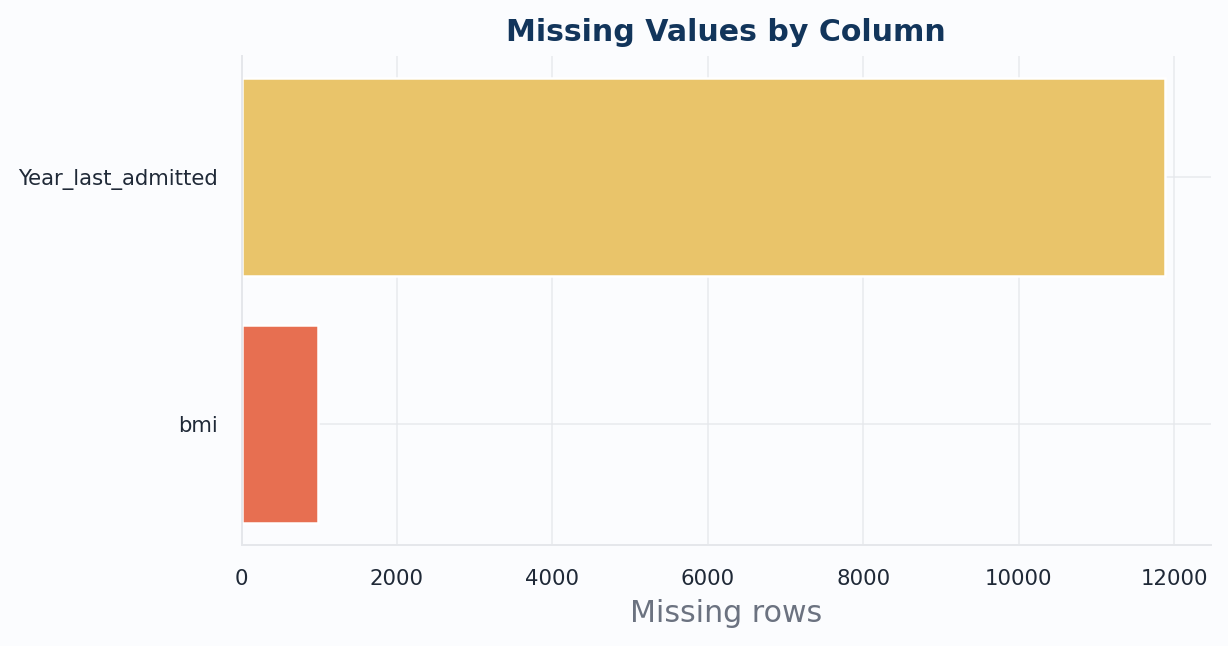

In [13]:
image_path = ROOT / 'outputs/figures/missing_values.png'
display(Markdown("**Missing values by column**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

**Target impact of missingness**

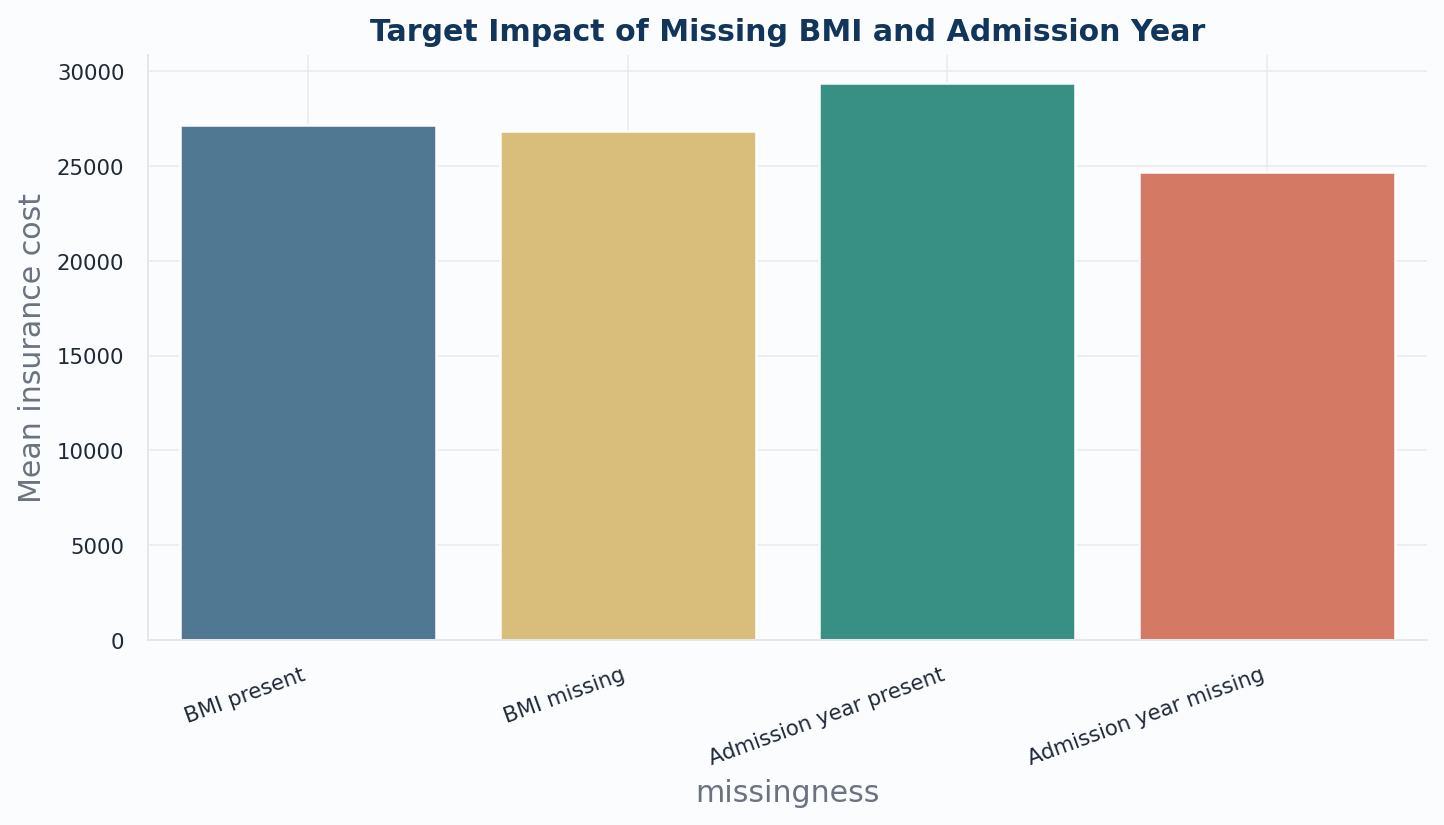

In [14]:
image_path = ROOT / 'outputs/figures/missingness_target_impact.png'
display(Markdown("**Target impact of missingness**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>BMI missingness is limited, but Year_last_admitted missingness is substantial and structurally meaningful.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The model should preserve missingness indicators because missing admission history changes customer context.</span>
    </div>

</div>

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>The missingness-impact chart shows target mean differences between present and missing groups.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>A reviewer can see why the pipeline uses flags and imputation instead of dropping incomplete records.</span>
    </div>

</div>

## 10. Duplicate and Unwanted Variable Analysis

In [15]:
duplicate_summary = pd.DataFrame(
    {
        "check": ["duplicate_rows", "unique_applicant_id", "applicant_id_in_model_columns"],
        "value": [int(raw_df.duplicated().sum()), int(raw_df["applicant_id"].nunique()), "applicant_id" in RAW_MODEL_COLUMNS],
    }
)
duplicate_summary

,check,value
0,duplicate_rows,0
1,unique_applicant_id,25000
2,applicant_id_in_model_columns,False


<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>`applicant_id` is unique for every row and is not included in the modeling feature list.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>Removing the identifier avoids memorization and supports a deployable applicant-input form.</span>
    </div>

</div>

## 11. Target Variable Analysis

In [16]:
target_summary = raw_df["insurance_cost"].agg(["count", "mean", "median", "std", "min", "max", "skew"]).round(3)
target_summary

count     25000.000
mean      27147.408
median    27148.000
std       14323.692
min        2468.000
max       67870.000
skew          0.332
Name: insurance_cost, dtype: float64

**Target distribution**

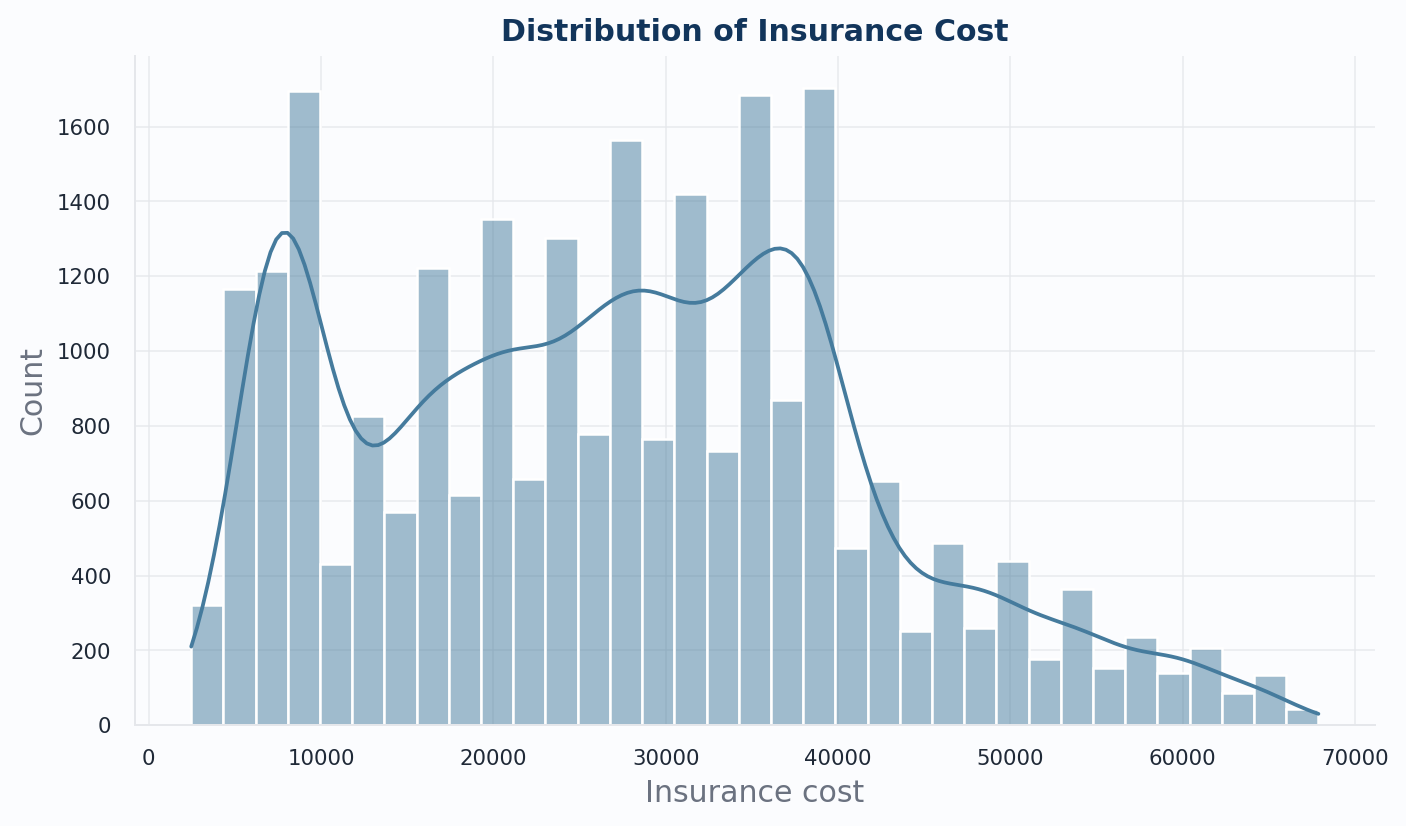

In [17]:
image_path = ROOT / 'outputs/figures/target_distribution.png'
display(Markdown("**Target distribution**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

**Target boxplot**

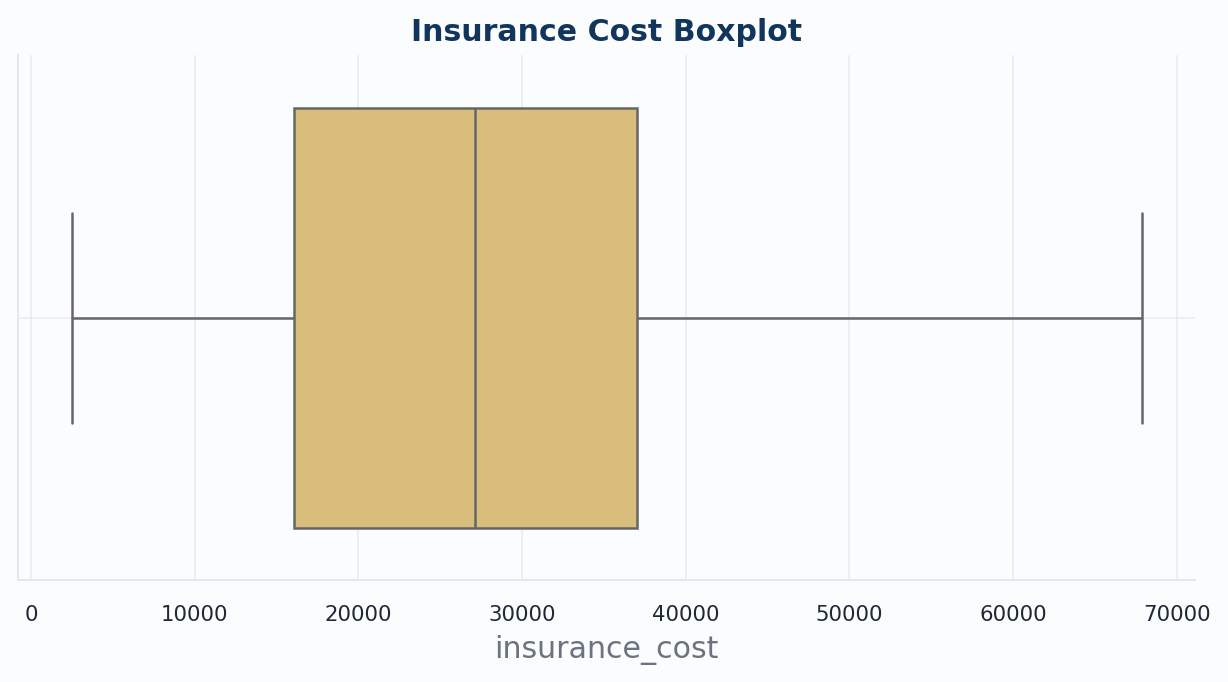

In [18]:
image_path = ROOT / 'outputs/figures/target_boxplot.png'
display(Markdown("**Target boxplot**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>The target is mildly right-skewed, with valid high-cost values that should remain in the dataset.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>High-cost applicants represent legitimate pricing cases, not noise to be removed.</span>
    </div>

</div>

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>The boxplot identifies upper-tail premiums, but these align with valid quote bands rather than impossible values.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The business needs accurate estimates for expensive cases, so target outlier removal would be harmful.</span>
    </div>

</div>

## 12. Target Pricing Grid Analysis

In [19]:
target_grid = pd.read_csv(TABLE_DIR / "target_grid_summary.csv")
target_frequency = pd.read_csv(TABLE_DIR / "target_price_band_frequency.csv")
display(target_grid)
display(target_frequency.head(12))
display(target_frequency.tail(12))

,metric,value
0,target_unique_count,54
1,target_grid_step,1234
2,target_min,2468
3,target_max,67870
4,first_10_levels,"2468, 3702, 4936, 6170, 7404, 8638, 9872, 1110..."
5,last_10_levels,"56764, 57998, 59232, 60466, 61700, 62934, 6416..."


,insurance_cost,customer_count,pct
0,2468,12,0.048
1,3702,309,1.236
2,4936,197,0.788
3,6170,970,3.880
4,7404,1214,4.856
5,8638,954,3.816
6,9872,742,2.968
7,11106,431,1.724
8,12340,373,1.492
9,13574,454,1.816


,insurance_cost,customer_count,pct
42,54296,172,0.688
43,55530,152,0.608
44,56764,122,0.488
45,57998,113,0.452
46,59232,140,0.560
47,60466,137,0.548
48,61700,70,0.280
49,62934,87,0.348
50,64168,77,0.308
51,65402,56,0.224


**Insurance quote-band frequency**

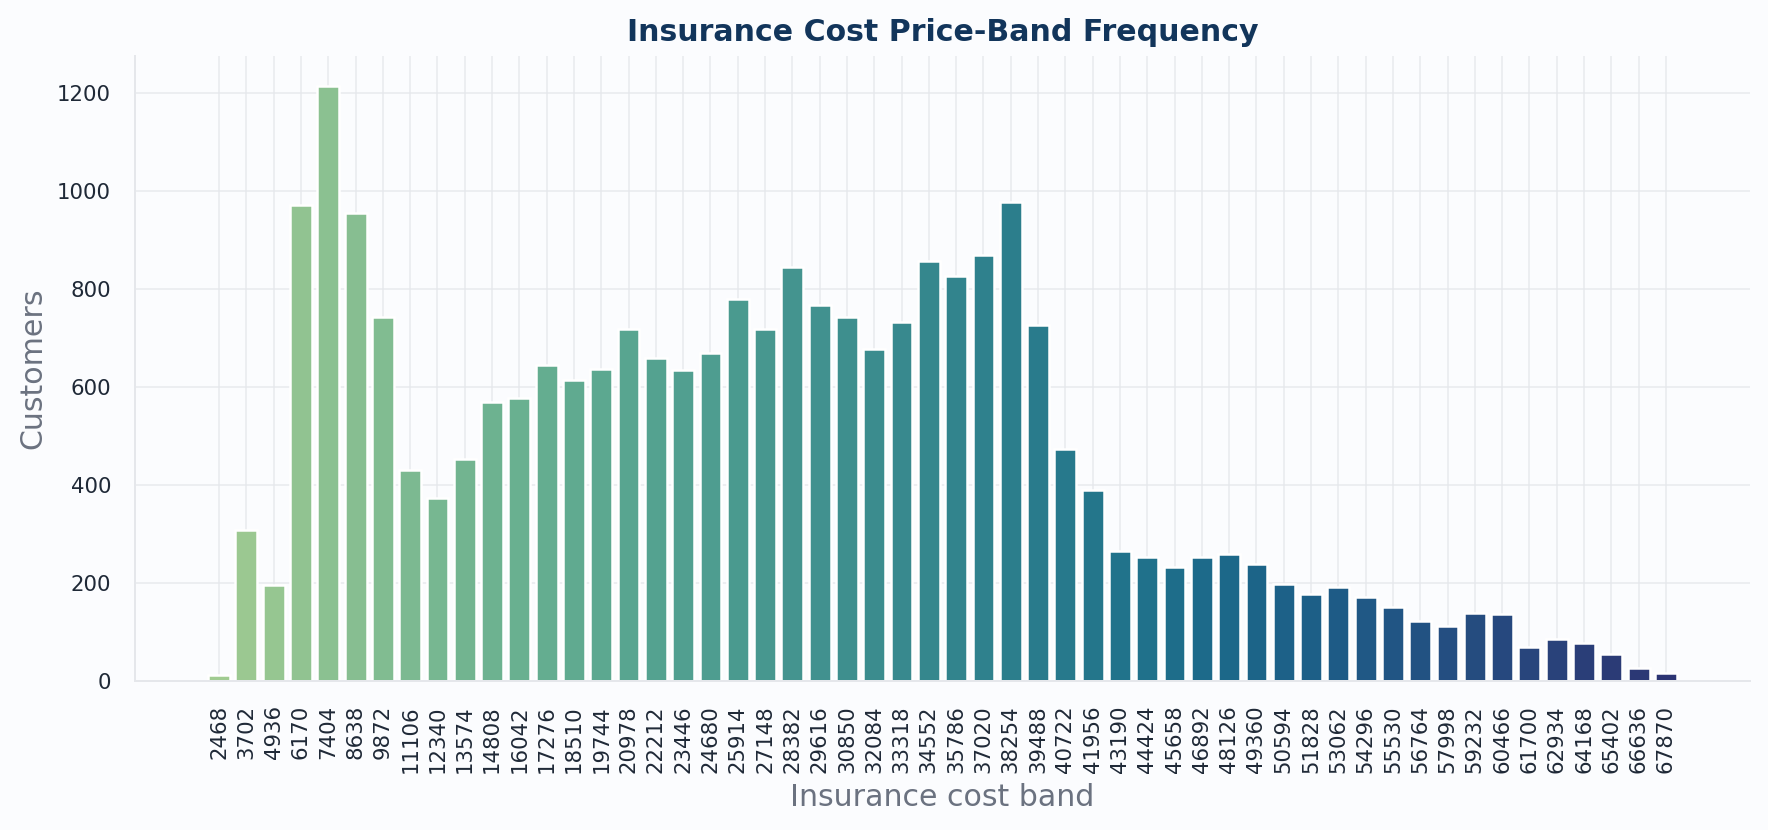

In [20]:
image_path = ROOT / 'outputs/figures/target_price_grid_frequency.png'
display(Markdown("**Insurance quote-band frequency**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>The target has 54 unique levels and a 1,234 unit grid step, proving that `insurance_cost` is a business quote grid.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>Deployment should show raw prediction plus nearest quote band instead of pretending the target is fully continuous.</span>
    </div>

</div>

## 13. Univariate Analysis: Numeric Variables

In [21]:
numeric_summary = pd.read_csv(TABLE_DIR / "numeric_summary.csv")
display(numeric_summary)

,column,count,mean,std,min,25%,50%,75%,max
0,applicant_id,25000.0,17499.500000,7217.022701,5000.0,11249.75,17499.5,23749.25,29999.0
1,years_of_insurance_with_us,25000.0,4.089040,2.606612,0.0,2.00,4.0,6.00,8.0
2,regular_checkup_lasy_year,25000.0,0.773680,1.199449,0.0,0.00,0.0,1.00,5.0
3,adventure_sports,25000.0,0.081720,0.273943,0.0,0.00,0.0,0.00,1.0
4,visited_doctor_last_1_year,25000.0,3.104200,1.141663,0.0,2.00,3.0,4.00,12.0
5,daily_avg_steps,25000.0,5215.889320,1053.179748,2034.0,4543.00,5089.0,5730.00,11255.0
6,age,25000.0,44.918320,16.107492,16.0,31.00,45.0,59.00,74.0
7,heart_decs_history,25000.0,0.054640,0.227281,0.0,0.00,0.0,0.00,1.0
8,other_major_decs_history,25000.0,0.098160,0.297537,0.0,0.00,0.0,0.00,1.0
9,avg_glucose_level,25000.0,167.530000,62.729712,57.0,113.00,168.0,222.00,277.0


**Outlier review for numeric variables**

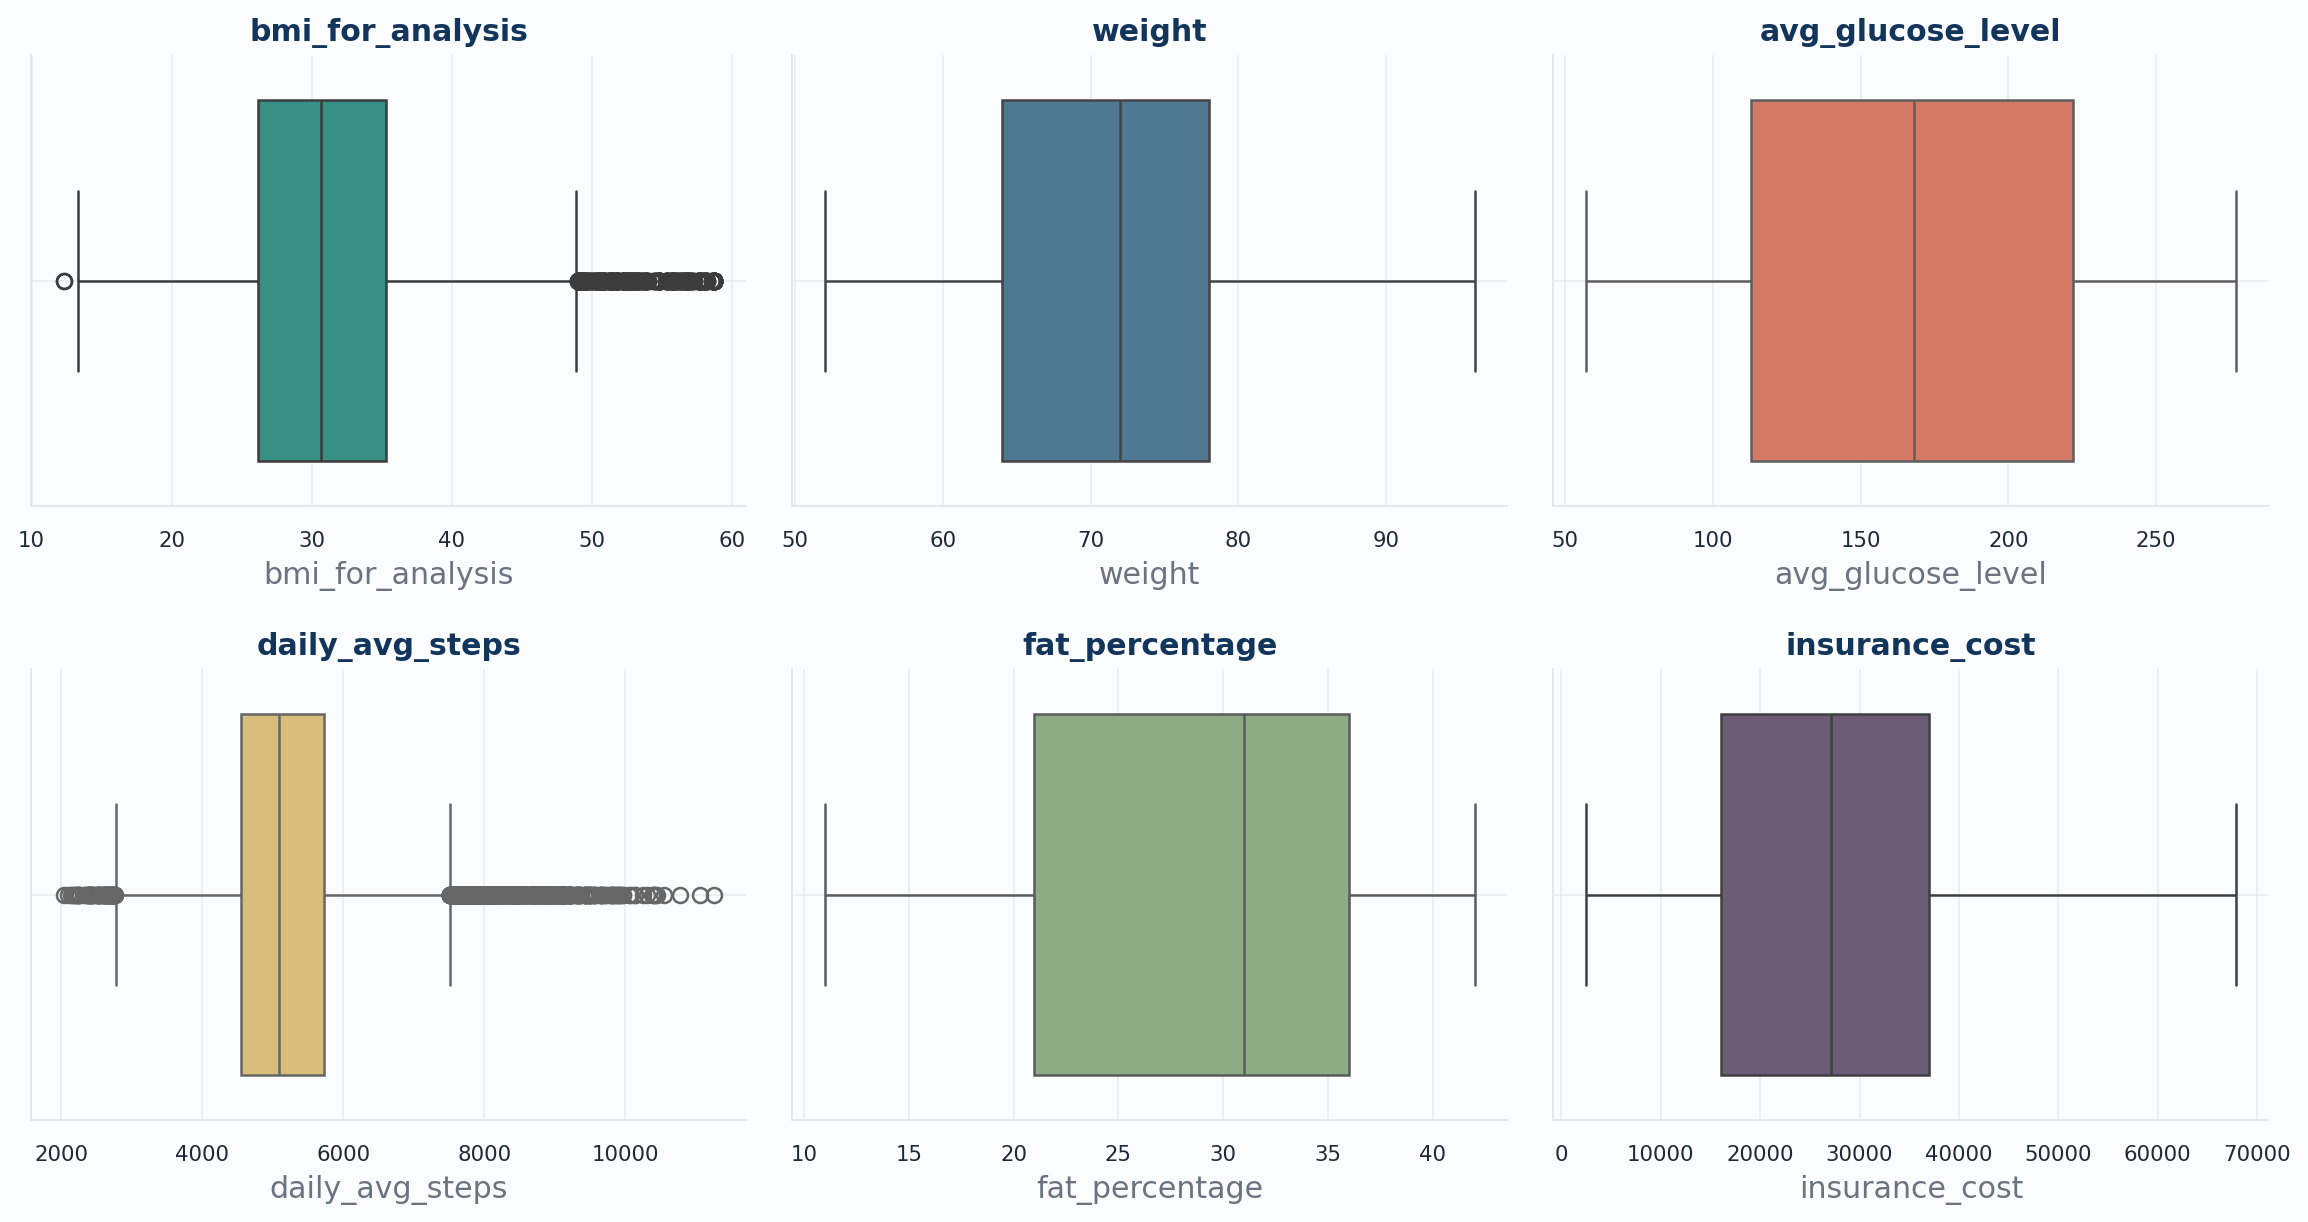

In [22]:
image_path = ROOT / 'outputs/figures/outlier_boxplots.png'
display(Markdown("**Outlier review for numeric variables**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>Numeric variables show wide but plausible ranges; BMI is stabilized for analysis while valid premium outliers are retained.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The preprocessing strategy protects model stability without deleting legitimate high-risk applicants.</span>
    </div>

</div>

## 14. Univariate Analysis: Categorical, Binary, and Ordinal Variables

In [23]:
categorical_frequency = pd.read_csv(TABLE_DIR / "categorical_frequency.csv")
display(categorical_frequency)
for name in ["covered_by_any_other_company", "regular_checkup_last_year", "weight_change_in_last_one_year", "admission_status"]:
    print("\n", name)
    display(pd.read_csv(TABLE_DIR / f"group_summary_{name}.csv").head(10))

,column,category,count,pct
0,Occupation,Student,10169,40.68
1,Occupation,Business,10020,40.08
2,Occupation,Salried,4811,19.24
3,cholesterol_level,150 to 175,8763,35.05
4,cholesterol_level,125 to 150,8339,33.36
5,cholesterol_level,200 to 225,2963,11.85
6,cholesterol_level,175 to 200,2881,11.52
7,cholesterol_level,225 to 250,2054,8.22
8,Gender,Male,16422,65.69
9,Gender,Female,8578,34.31



 covered_by_any_other_company


,covered_by_any_other_company,count,mean,median
0,Y,7582,29353.64,29616.0
1,N,17418,26187.04,25914.0



 regular_checkup_last_year


,regular_checkup_last_year,count,mean,median
0,0,15215,29002.77,29616.0
1,1,4644,26214.79,24680.0
2,4,777,23530.17,24680.0
3,2,2198,23143.39,22212.0
4,3,1818,21681.20,22212.0
5,5,348,20396.46,20361.0



 weight_change_in_last_one_year


,weight_change_in_last_one_year,count,mean,median
0,2,4037,31452.79,30850.0
1,0,4012,31102.21,30850.0
2,1,3925,31005.63,30850.0
3,3,5006,27166.24,27148.0
4,4,5076,26460.74,25914.0
5,5,2036,14220.09,11106.0
6,6,908,6574.99,6170.0



 admission_status


,admission_status,count,mean,median
0,Previously admitted,13119,29384.51,29616.0
1,No known admission,11881,24677.20,23446.0


<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>Categorical and ordinal summaries show class balance and average-cost separation before multivariate modeling.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>This helps prevent overclaiming weak fields while still documenting business-relevant segments.</span>
    </div>

</div>

## 15. Bivariate Analysis with Target

**Insurance cost versus weight with jitter**

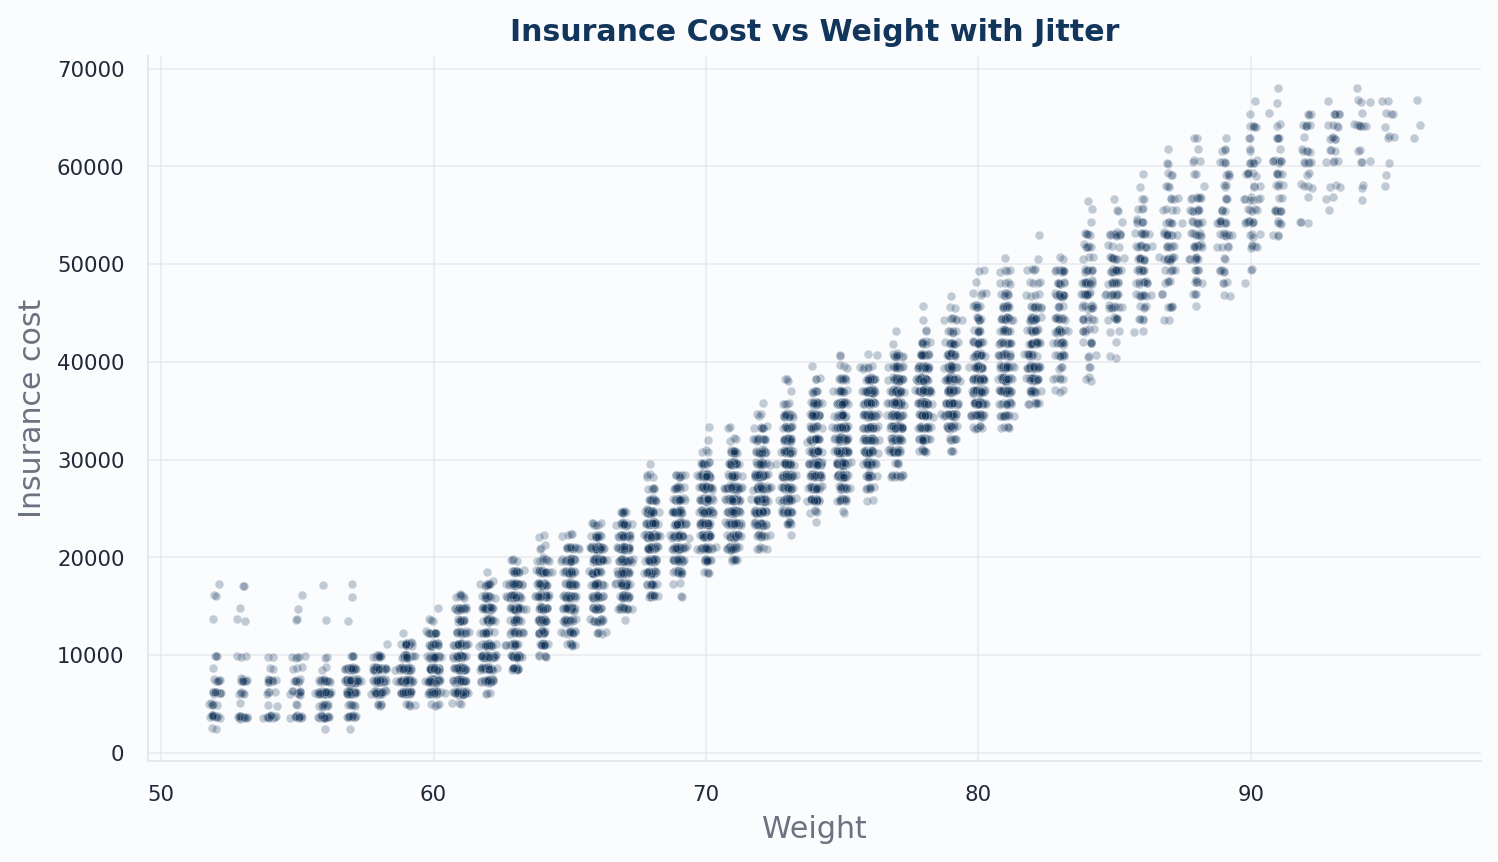

In [24]:
image_path = ROOT / 'outputs/figures/weight_vs_cost_jitter.png'
display(Markdown("**Insurance cost versus weight with jitter**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

**Average insurance cost by weight**

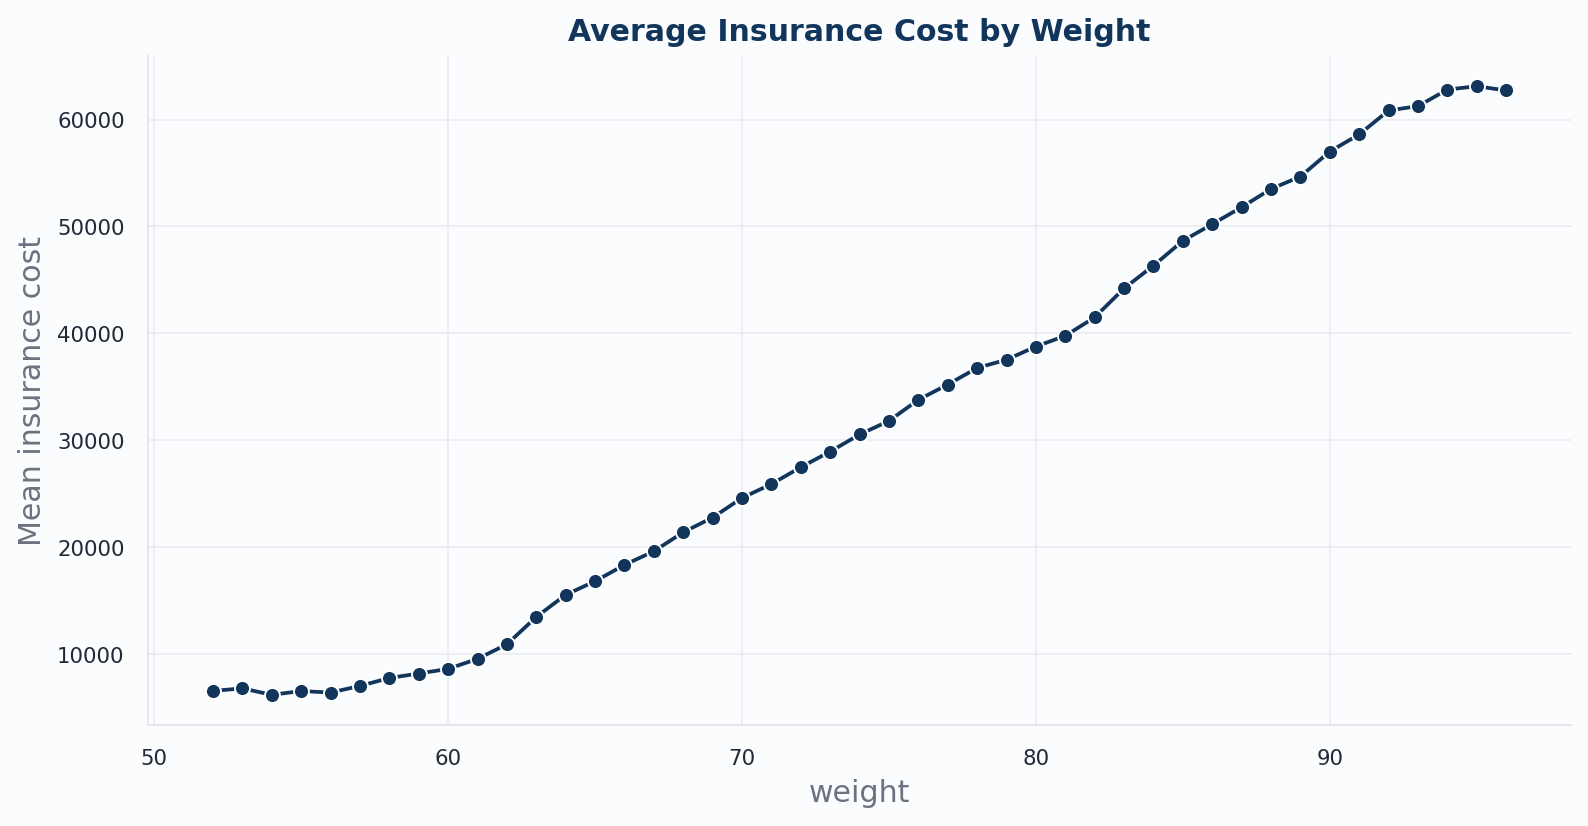

In [25]:
image_path = ROOT / 'outputs/figures/cost_by_weight_line.png'
display(Markdown("**Average insurance cost by weight**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>Weight is the clearest marginal relationship, and jitter reveals quote-grid bands that would otherwise overlap.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>Weight dominates the submitted dataset, so policy and fairness review should focus on how this feature is used.</span>
    </div>

</div>

**Average insurance cost by weight band**

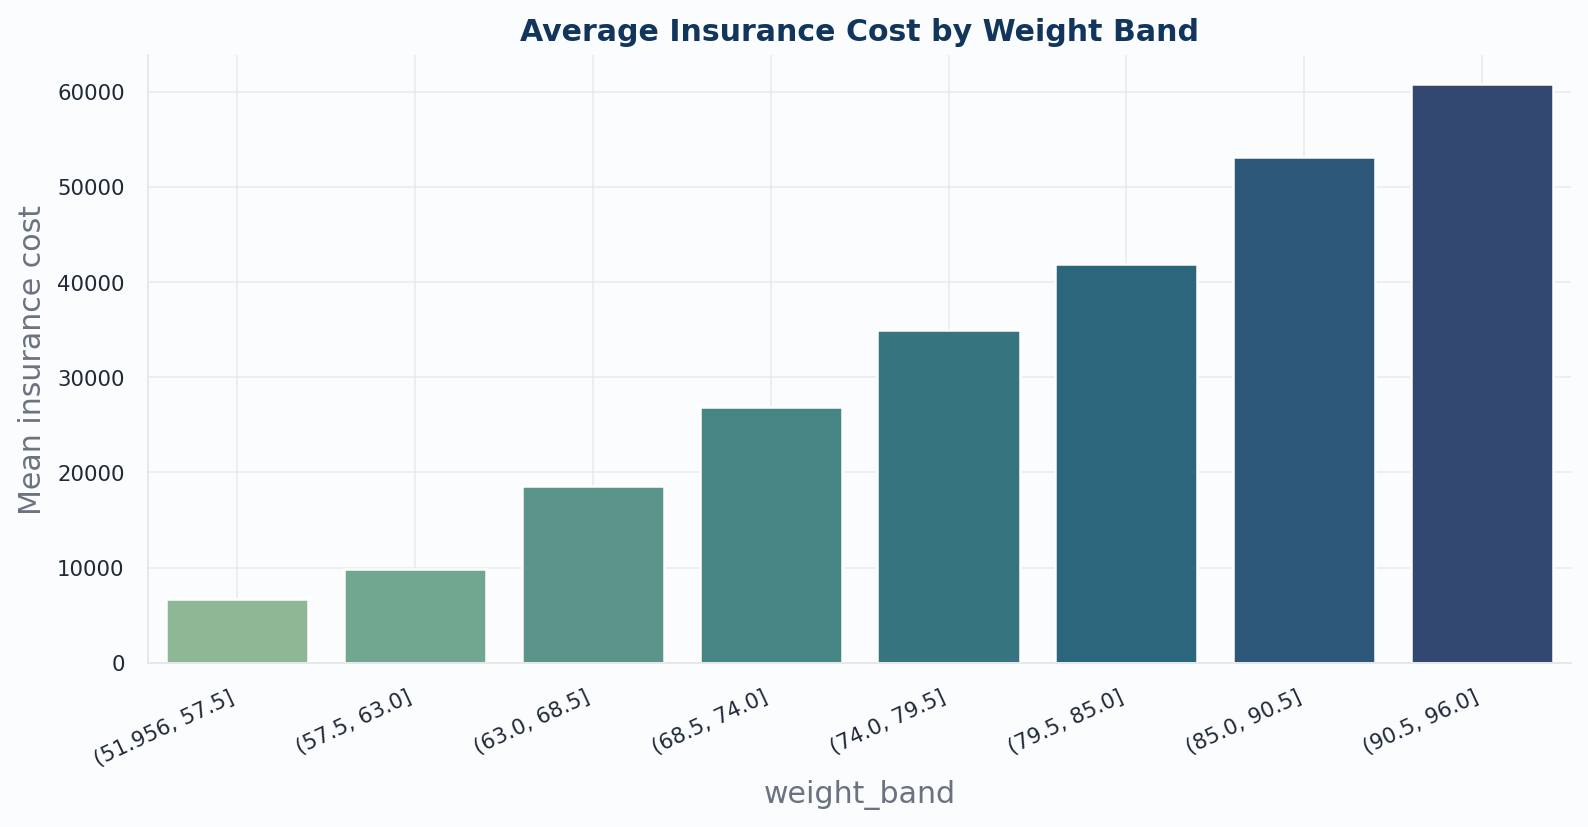

In [26]:
image_path = ROOT / 'outputs/figures/cost_by_weight_band.png'
display(Markdown("**Average insurance cost by weight band**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

**Insurance cost by other-company coverage**

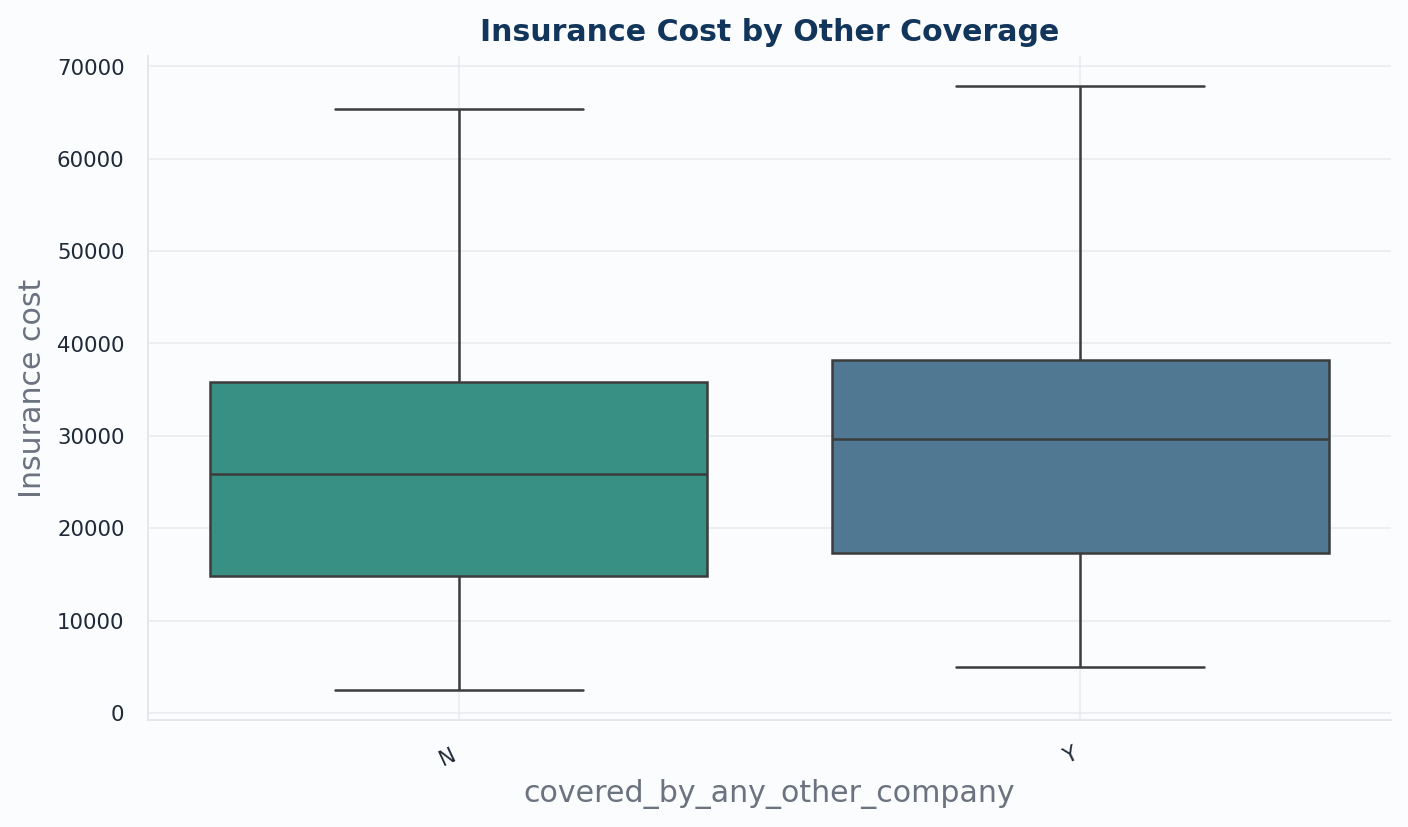

In [27]:
image_path = ROOT / 'outputs/figures/cost_by_other_coverage.png'
display(Markdown("**Insurance cost by other-company coverage**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>Weight bands confirm the main gradient; other-company coverage adds a separate categorical signal.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The pricing story is not a single-variable story, but weight is the primary observed driver.</span>
    </div>

</div>

**Cost by regular checkup count**

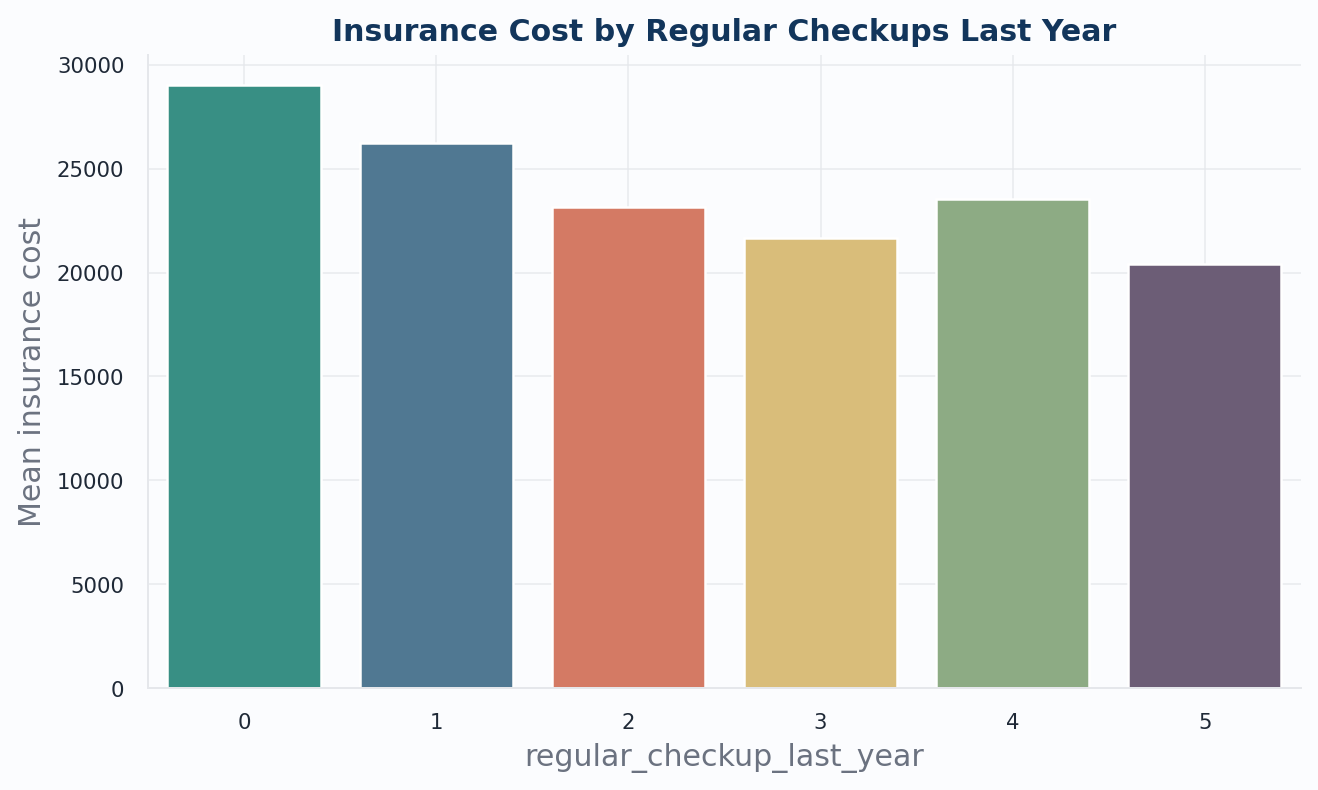

In [28]:
image_path = ROOT / 'outputs/figures/cost_by_regular_checkup_last_year.png'
display(Markdown("**Cost by regular checkup count**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

**Cost by weight-change category**

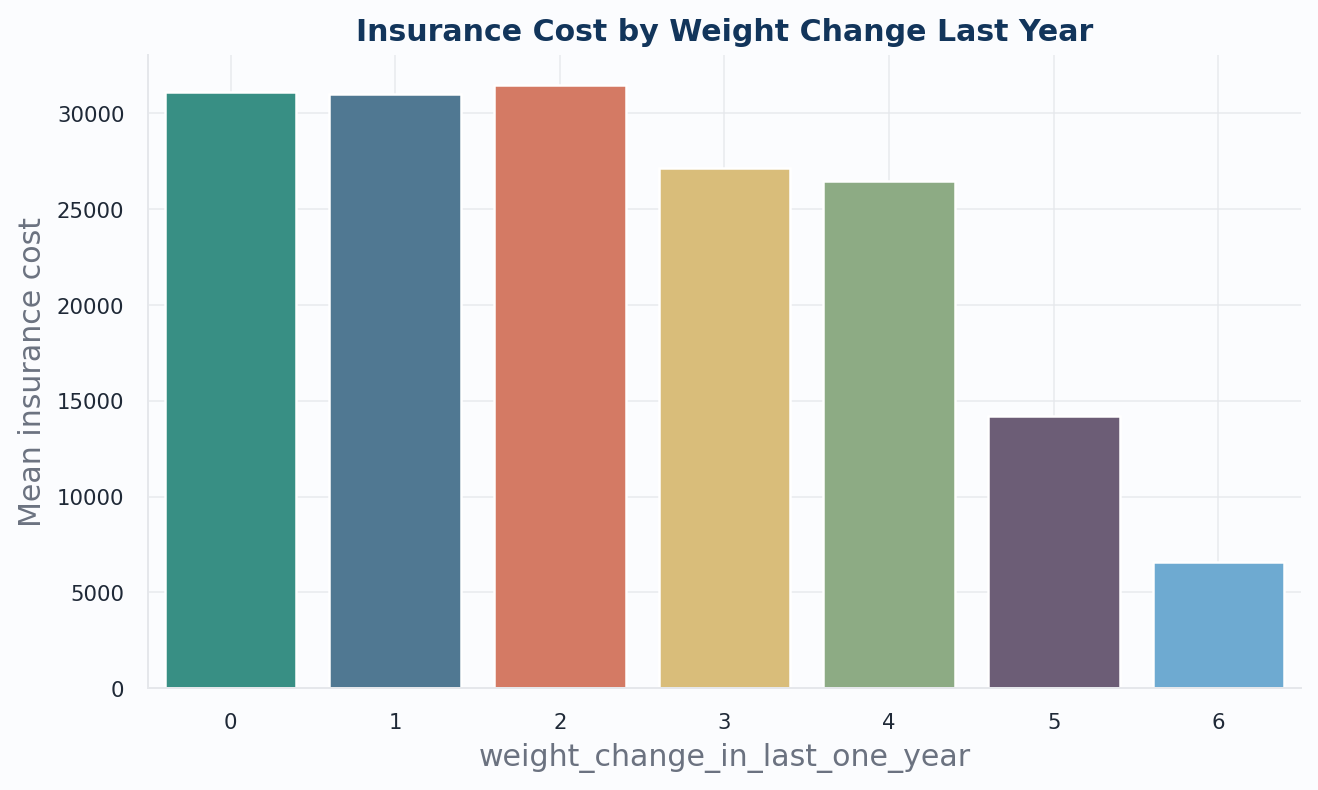

In [29]:
image_path = ROOT / 'outputs/figures/cost_by_weight_change.png'
display(Markdown("**Cost by weight-change category**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>Regular checkups and weight-change categories have stronger target separation than many simple habit flags.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>These variables can support applicant segmentation, but the report frames them as associations rather than causal levers.</span>
    </div>

</div>

**Cost by year last admitted**

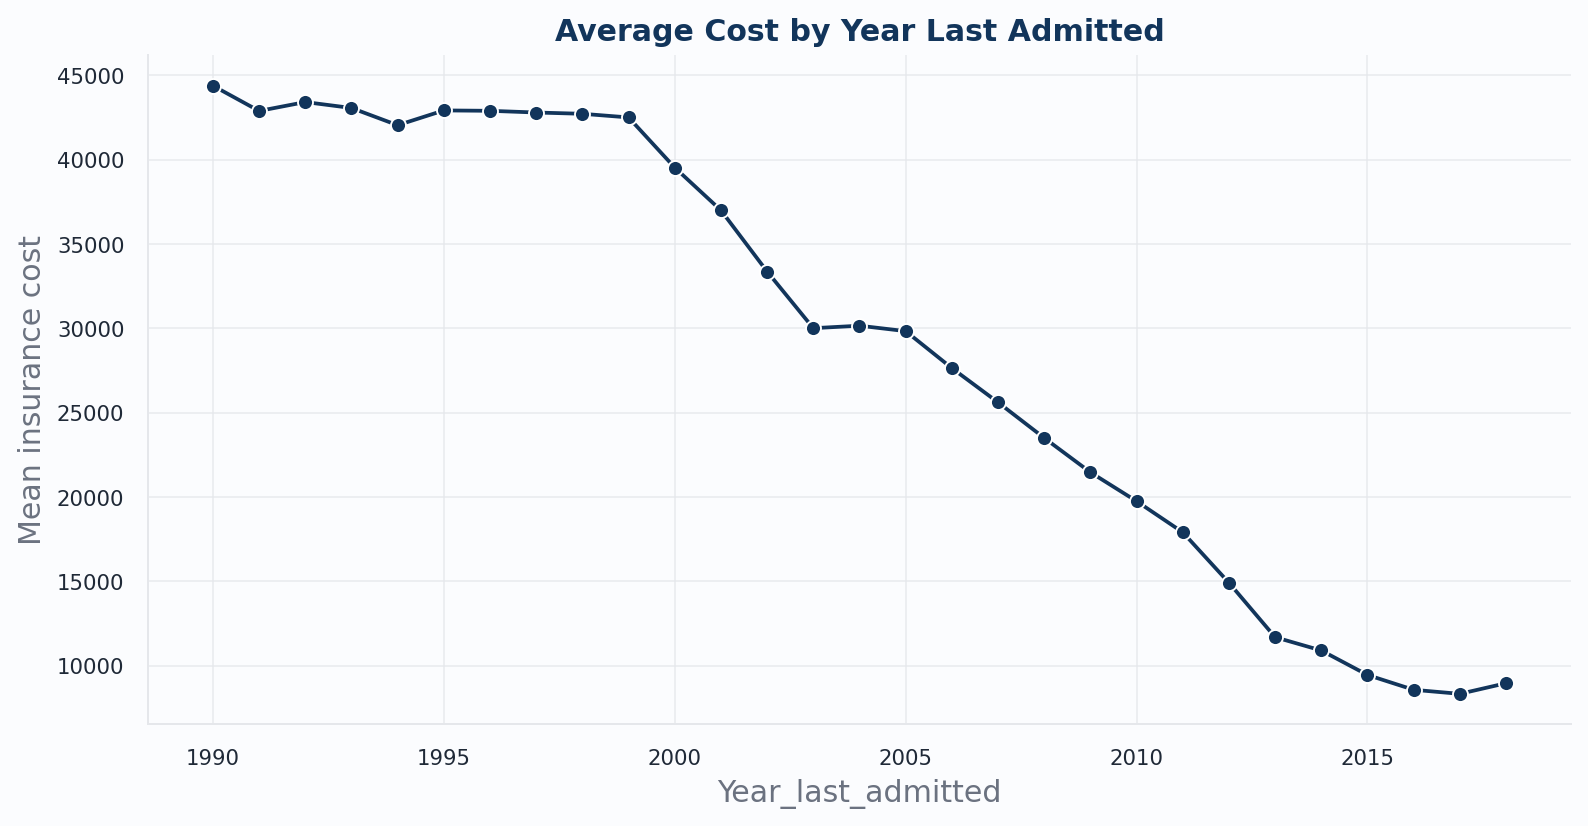

In [30]:
image_path = ROOT / 'outputs/figures/cost_by_year_last_admitted.png'
display(Markdown("**Cost by year last admitted**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

**Cost by admission status**

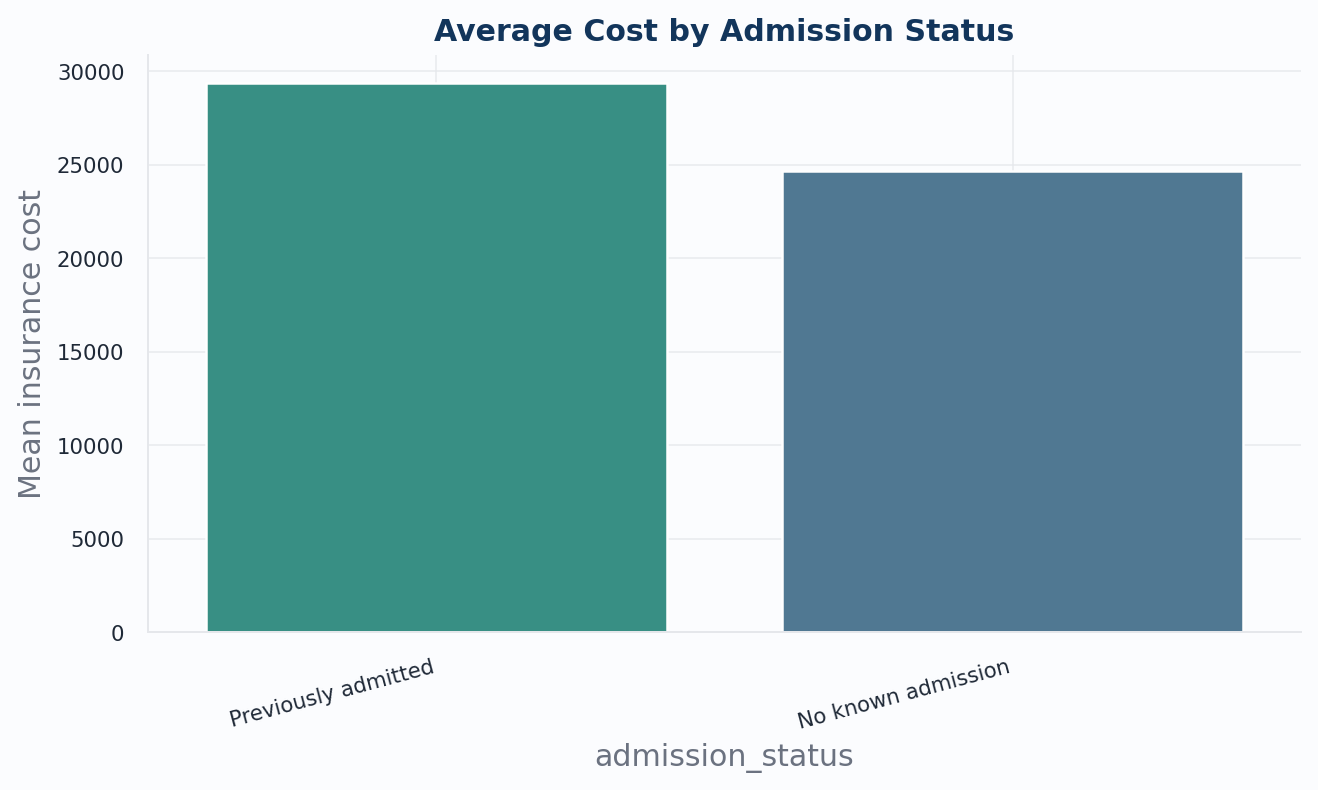

In [31]:
image_path = ROOT / 'outputs/figures/cost_by_admission_status.png'
display(Markdown("**Cost by admission status**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>Admission-year and admission-status plots show that recency/history information is meaningful when represented carefully.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>Applicants without known admission history should not be forced into an arbitrary numeric admission year.</span>
    </div>

</div>

## 16. Correlation and Association Analysis

**Correlation heatmap**

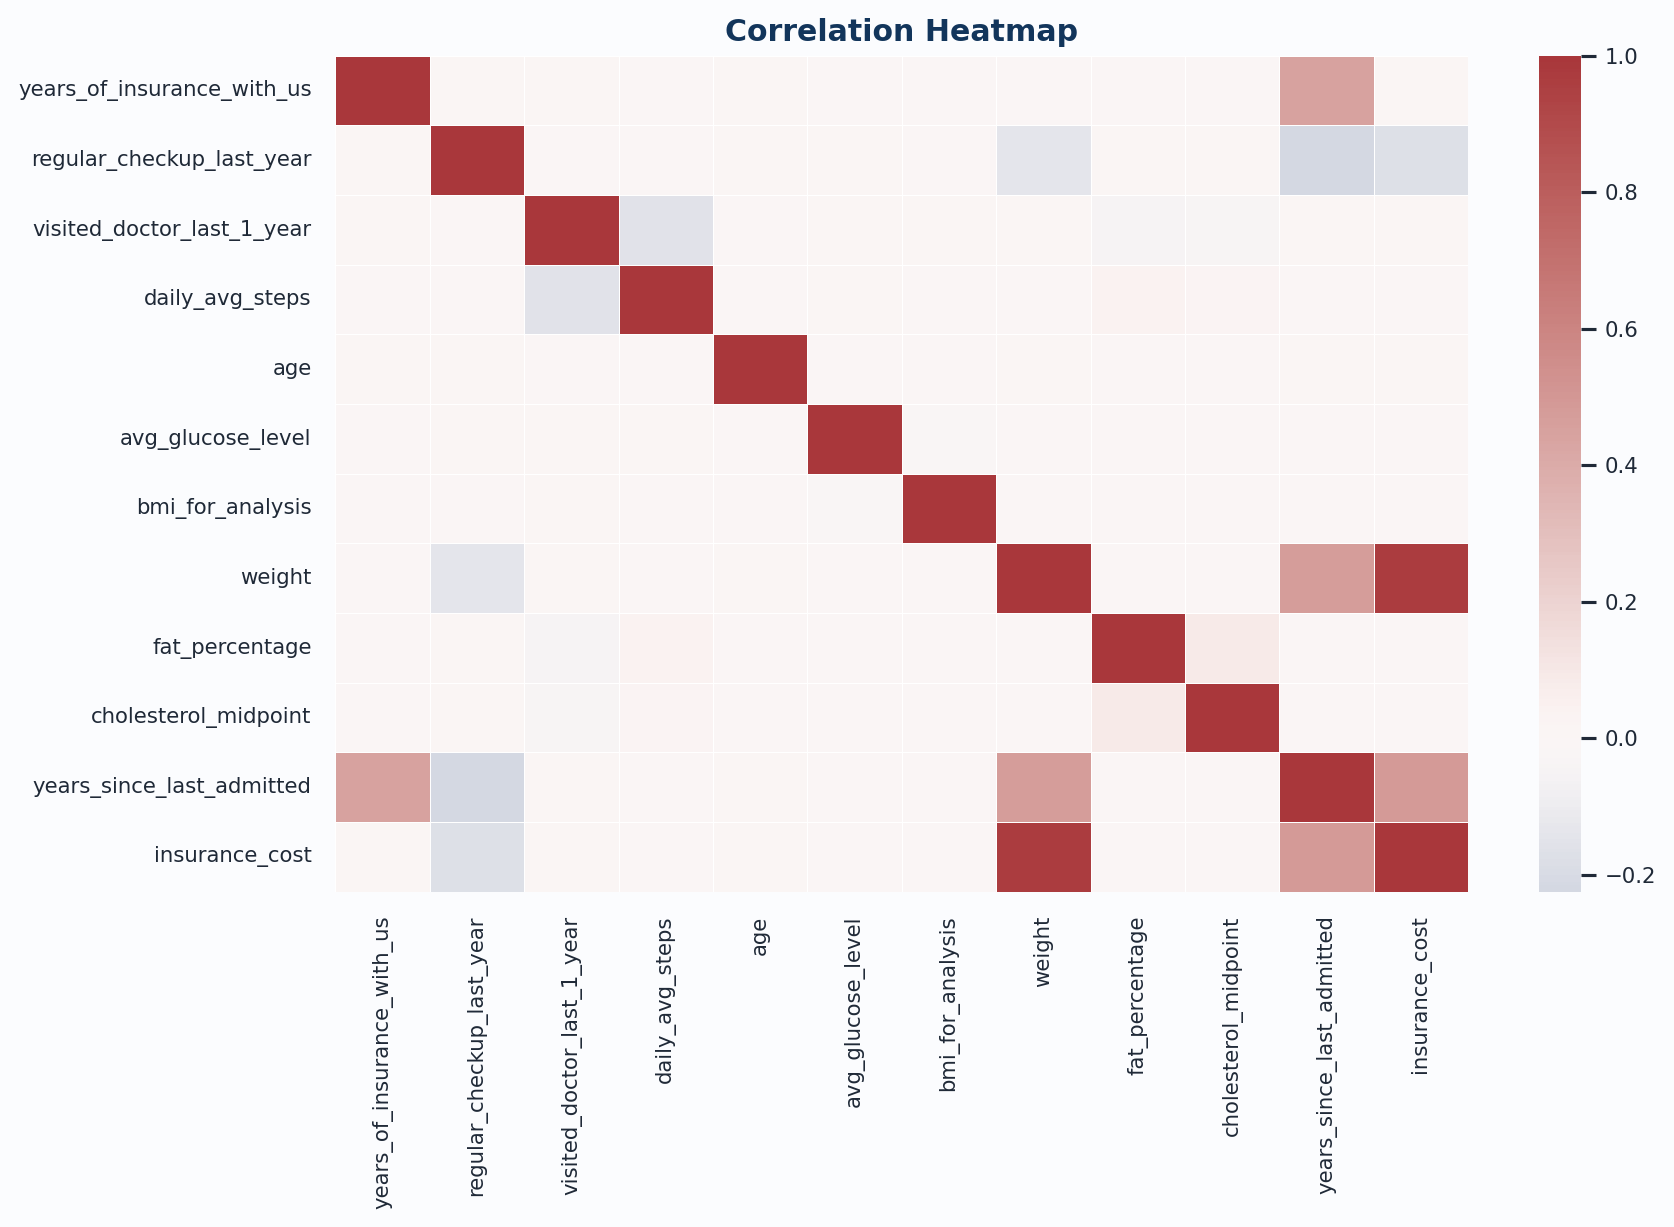

In [32]:
image_path = ROOT / 'outputs/figures/correlation_heatmap.png'
display(Markdown("**Correlation heatmap**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

In [33]:
feature_signal = pd.read_csv(TABLE_DIR / "feature_signal_strength.csv")
display(feature_signal)

,feature,feature_type,target_mean_range,correlation_or_eta_squared,statistic_name,business_interpretation
0,weight,numeric,46308.56,0.97036,absolute_correlation,strong observed signal
1,Year_last_admitted,numeric_missing,36072.69,0.41503,eta_squared,strong observed signal
2,years_since_last_admitted,numeric_engineered,30329.25,0.49017,absolute_correlation,strong observed signal
3,weight_change_in_last_one_year,ordinal,24877.80,0.17994,eta_squared,strong observed signal
4,regular_checkup_last_year,ordinal,8606.31,0.03354,eta_squared,strong observed signal
5,adventure_sports,binary,3898.57,0.00556,eta_squared,strong observed signal
6,covered_by_any_other_company,categorical,3166.60,0.01033,eta_squared,strong observed signal
7,bmi_for_analysis,numeric,1072.59,0.00839,absolute_correlation,secondary signal; monitor with interactions
8,cholesterol_midpoint,numeric,897.09,0.00021,eta_squared,weak marginal signal in this dataset
9,age,numeric,792.72,0.00520,absolute_correlation,secondary signal; monitor with interactions


<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>The association table confirms strong observed signals for weight, admission recency/year, other coverage, checkups, weight change, and adventure sports.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The report honestly labels smoking, alcohol, exercise, age, BMI, glucose, cholesterol, and disease flags as weak marginal signals in this dataset.</span>
    </div>

</div>

## 17. Multivariate and Segmented EDA

**Average cost by age band and BMI category**

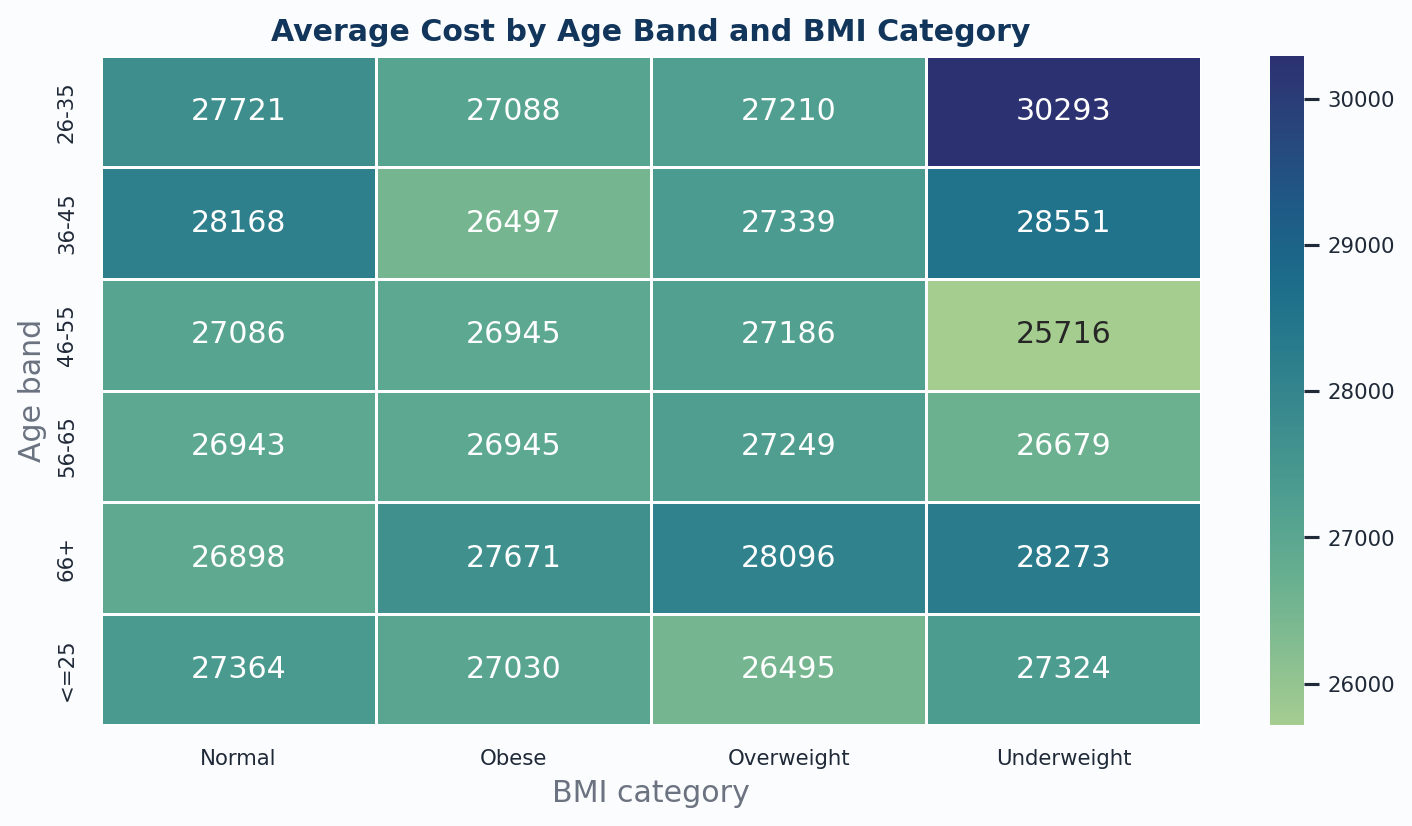

In [34]:
image_path = ROOT / 'outputs/figures/cost_age_bmi_heatmap.png'
display(Markdown("**Average cost by age band and BMI category**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

**Average cost by medical and lifestyle risk bands**

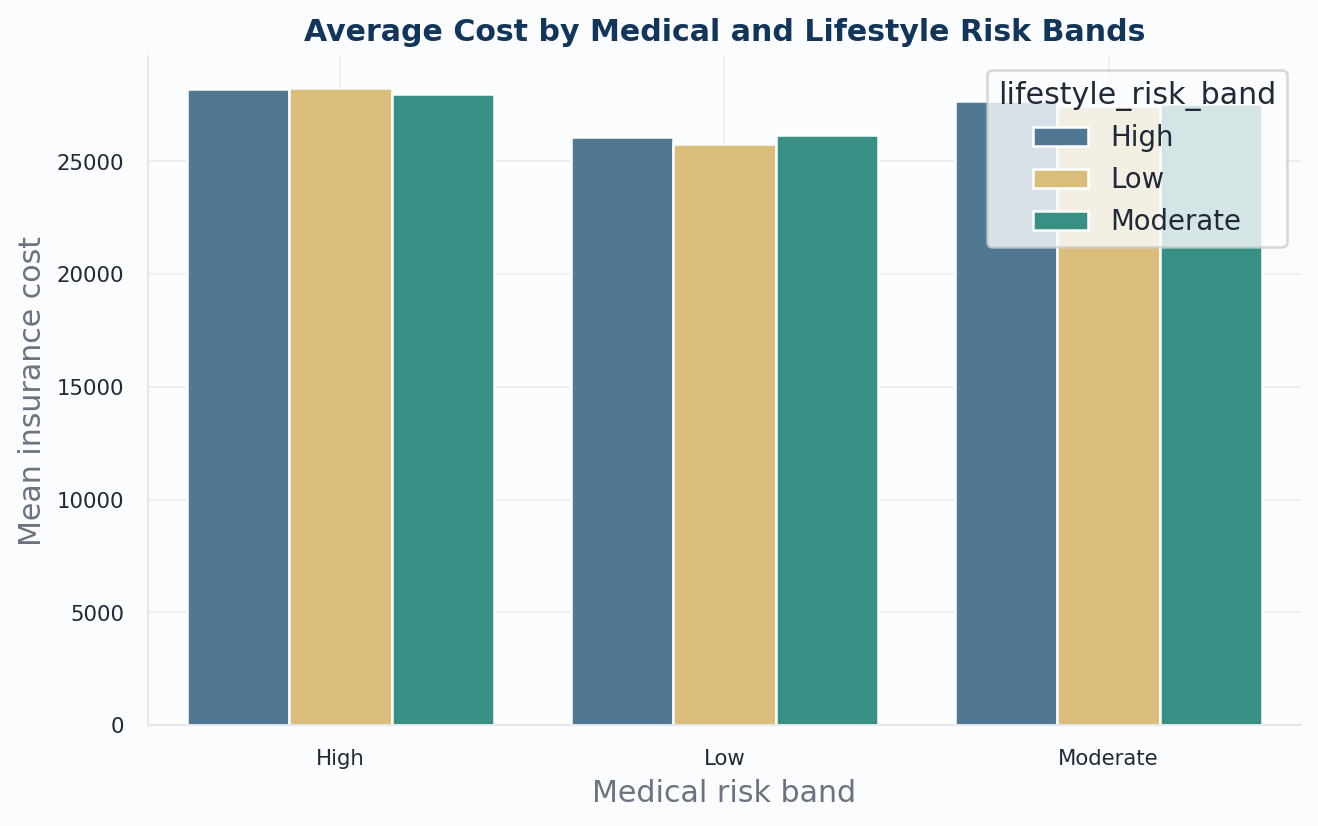

In [35]:
image_path = ROOT / 'outputs/figures/cost_by_combined_risk_bands.png'
display(Markdown("**Average cost by medical and lifestyle risk bands**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>Segmented EDA checks whether weak marginal variables become more useful in combination with age, BMI, medical, or lifestyle bands.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>Business users get a more realistic view of applicant risk than from one-way charts alone.</span>
    </div>

</div>

**Average cost by smoking status across age bands**

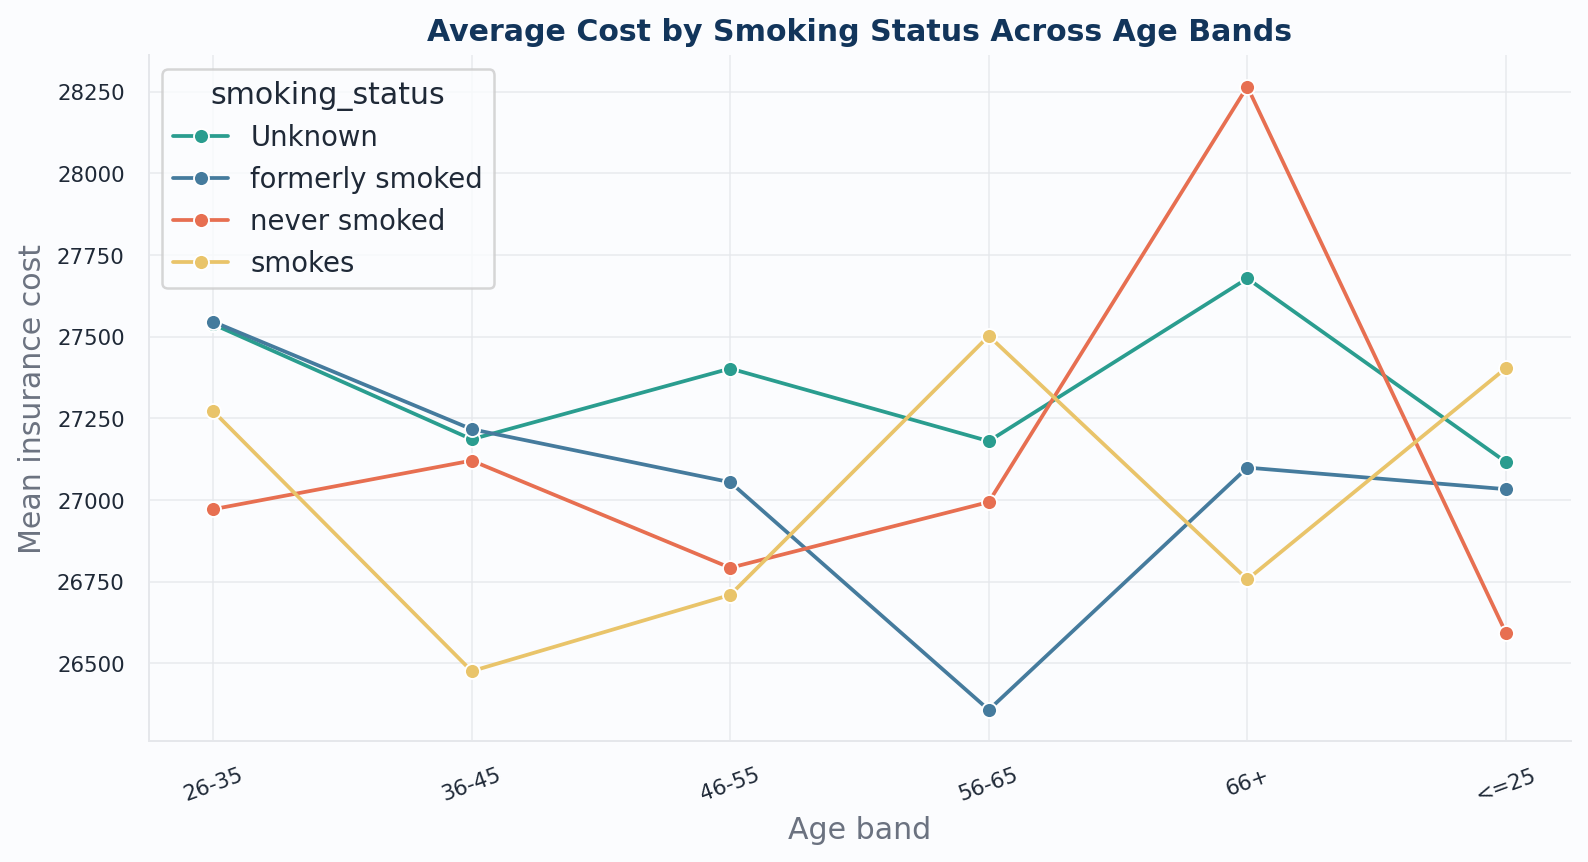

In [36]:
image_path = ROOT / 'outputs/figures/cost_smoking_by_age_band.png'
display(Markdown("**Average cost by smoking status across age bands**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

**Average cost by disease-history combination**

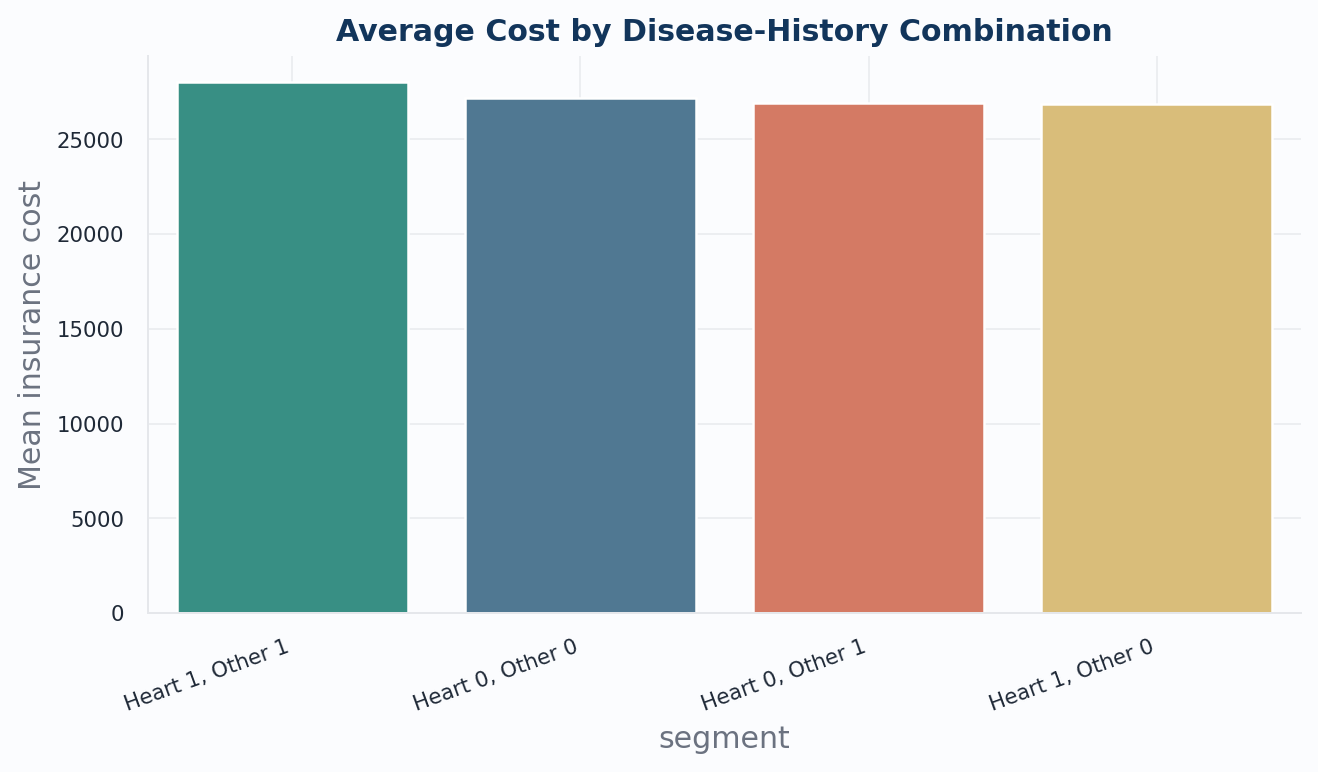

In [37]:
image_path = ROOT / 'outputs/figures/disease_history_means.png'
display(Markdown("**Average cost by disease-history combination**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>Smoking and disease-history views are retained for transparency, but they do not overturn the stronger weight and admission-history findings.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The submission avoids overclaiming expected health variables when the supplied data shows weaker marginal effects.</span>
    </div>

</div>

## 18. Outlier Detection and Treatment Strategy

In [38]:
outliers = pd.read_csv(TABLE_DIR / "outlier_summary.csv")
display(outliers)

,column,q1,q3,iqr,lower_fence,upper_fence,outlier_count,outlier_pct
0,bmi,26.1,35.6,9.5,11.85,49.85,549,2.29
1,weight,64.0,78.0,14.0,43.00,99.00,0,0.00
2,avg_glucose_level,113.0,222.0,109.0,-50.50,385.50,0,0.00
3,daily_avg_steps,4543.0,5730.0,1187.0,2762.50,7510.50,952,3.81
4,fat_percentage,21.0,36.0,15.0,-1.50,58.50,0,0.00
5,insurance_cost,16042.0,37020.0,20978.0,-15425.00,68487.00,0,0.00


<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>The outlier strategy separates true target extremes from numeric stabilization needs such as BMI capping.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>This is a balanced preprocessing decision: keep valid expensive customers, but avoid letting implausible BMI values distort analysis.</span>
    </div>

</div>

## 19. Feature Engineering and Transformations

In [39]:
engineered_cols = [
    "age_band", "bmi_missing_flag", "bmi_for_analysis", "bmi_category",
    "was_admitted_before", "admission_year_missing_flag", "years_since_last_admitted",
    "cholesterol_midpoint", "any_major_disease_history", "weight_bmi_interaction",
    "steps_per_age", "medical_risk_score", "lifestyle_risk_score",
]
cleaned_analysis = pd.read_csv(TABLE_DIR / "cleaned_analysis_data.csv")
display(cleaned_analysis[engineered_cols].head())

,age_band,bmi_missing_flag,bmi_for_analysis,bmi_category,was_admitted_before,admission_year_missing_flag,years_since_last_admitted,cholesterol_midpoint,any_major_disease_history,weight_bmi_interaction,steps_per_age,medical_risk_score,lifestyle_risk_score
0,26-35,0,31.2,Obese,0,1,0.0,137.5,1,2090.4,173.785714,3.2,3.15
1,46-55,0,34.2,Obese,0,1,0.0,162.5,0,1983.6,128.220000,2.2,2.00
2,66+,0,40.4,Obese,0,1,0.0,212.5,0,2949.2,66.308824,3.0,3.80
3,46-55,0,22.9,Normal,0,1,0.0,187.5,0,1625.9,121.843137,0.0,4.05
4,36-45,0,26.5,Overweight,1,0,15.0,162.5,1,1961.0,112.227273,2.7,0.80


<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>Feature engineering converts missingness, ranges, and history fields into model-ready representations without leaking target information.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The engineered variables give reviewers interpretable risk context and prepare the data for the Milestone 2 pipeline.</span>
    </div>

</div>

## 20. Preprocessing Summary

In [40]:
preprocessing_summary = pd.DataFrame(
    [
        ["applicant_id", "Drop from modeling", "Unique identifier"],
        ["bmi", "Flag missingness and impute", "Limited missingness with health meaning"],
        ["Year_last_admitted", "Create admission-status and recency features", "Structural missingness"],
        ["cholesterol_level", "Engineer midpoint", "Ordinal range"],
        ["insurance_cost", "Keep target outliers", "Valid quote bands"],
    ],
    columns=["field", "action", "reason"],
)
preprocessing_summary

,field,action,reason
0,applicant_id,Drop from modeling,Unique identifier
1,bmi,Flag missingness and impute,Limited missingness with health meaning
2,Year_last_admitted,Create admission-status and recency features,Structural missingness
3,cholesterol_level,Engineer midpoint,Ordinal range
4,insurance_cost,Keep target outliers,Valid quote bands


<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>The preprocessing plan is explicit, limited, and tied to each field&#x27;s business meaning.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>This meets the rubric expectation for justifying unwanted-variable removal, missing-value handling, transformations, and new variables.</span>
    </div>

</div>

## 21. Extensive EDA Summary

In [41]:
strong = feature_signal[feature_signal["business_interpretation"].str.contains("strong", case=False, na=False)]
weak = feature_signal[feature_signal["business_interpretation"].str.contains("weak", case=False, na=False)]
display(strong)
display(weak)

,feature,feature_type,target_mean_range,correlation_or_eta_squared,statistic_name,business_interpretation
0,weight,numeric,46308.56,0.97036,absolute_correlation,strong observed signal
1,Year_last_admitted,numeric_missing,36072.69,0.41503,eta_squared,strong observed signal
2,years_since_last_admitted,numeric_engineered,30329.25,0.49017,absolute_correlation,strong observed signal
3,weight_change_in_last_one_year,ordinal,24877.80,0.17994,eta_squared,strong observed signal
4,regular_checkup_last_year,ordinal,8606.31,0.03354,eta_squared,strong observed signal
5,adventure_sports,binary,3898.57,0.00556,eta_squared,strong observed signal
6,covered_by_any_other_company,categorical,3166.60,0.01033,eta_squared,strong observed signal


,feature,feature_type,target_mean_range,correlation_or_eta_squared,statistic_name,business_interpretation
8,cholesterol_midpoint,numeric,897.09,0.00021,eta_squared,weak marginal signal in this dataset
11,exercise,categorical,388.37,0.00012,eta_squared,weak marginal signal in this dataset
12,smoking_status,categorical,312.31,0.00008,eta_squared,weak marginal signal in this dataset
13,Alcohol,categorical,287.81,0.00004,eta_squared,weak marginal signal in this dataset
14,other_major_disease_history,binary,109.19,0.00001,eta_squared,weak marginal signal in this dataset
15,heart_disease_history,binary,28.04,0.00000,eta_squared,weak marginal signal in this dataset


<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>The strongest observed variables are weight, admission-year/recency, other-company coverage, regular checkups, weight change, and adventure sports.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>This focused ranking helps the report explain what actually matters in the supplied data rather than listing every variable equally.</span>
    </div>

</div>

## 22. Business Insights from EDA

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>Quote bands and target-grid behavior mean RMSE/MAE should be supplemented with nearest-band evaluation in Milestone 2.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>Pricing teams need a business-ready quote band, not only a floating-point model prediction.</span>
    </div>

</div>

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>Weak marginal signals are documented rather than discarded because interactions can still matter in tree-based models.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The business gets transparent caveats: weak standalone fields are not presented as major pricing drivers.</span>
    </div>

</div>

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>Missing admission history and prior admission recency are different concepts and should not be collapsed into one imputed number.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>This distinction gives a more defensible applicant-history signal for downstream pricing triage.</span>
    </div>

</div>

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>The EDA supports target-band stratification for train/test splitting because every quote band is a meaningful target level.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The final model evaluation should preserve quote-band representation across train and test data.</span>
    </div>

</div>

## 23. Milestone 1 Conclusion and Next Steps

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>The cleaned analytical dataset is ready for modeling after ID removal, targeted missingness treatment, feature engineering, and quote-grid-aware evaluation planning.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>Milestone 2 should compare baseline, linear, tree, boosted, calibrated, rounded, and deployment-ready variants with honest metric reporting.</span>
    </div>

</div>

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>EDA findings are association-based and should not be interpreted as underwriting policy or causal medical conclusions.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The model can support pricing analysis, but final insurance decisions require policy, fairness, compliance, and human review.</span>
    </div>

</div>

## 24. Appendix: Additional Tables and Plots

In [42]:
appendix_files = sorted(p.name for p in TABLE_DIR.glob("*.csv"))
pd.DataFrame({"available_table": appendix_files}).head(80)

,available_table
0,admission_recency_summary.csv
1,calibration_comparison.csv
2,categorical_frequency.csv
3,cleaned_analysis_data.csv
4,data_dictionary_summary.csv
5,dataset_profile.csv
6,fairness_error_summary.csv
7,feature_importance.csv
8,feature_signal_strength.csv
9,final_model_summary.csv


### Complete Univariate Plot Appendix for All Original Variables

In [43]:
univariate_index = pd.read_csv(TABLE_DIR / "univariate_plot_interpretations.csv")
display(univariate_index[[
    "original_column", "clean_column", "analysis_type", "plot_type",
    "missing_count", "unique_count", "plot_file"
]])

,original_column,clean_column,analysis_type,plot_type,missing_count,unique_count,plot_file
0,applicant_id,applicant_id,identifier,identifier audit bar chart,0,25000,outputs/figures/univariate_applicant_id.png
1,years_of_insurance_with_us,years_of_insurance_with_us,ordinal discrete numeric,frequency bar chart,0,9,outputs/figures/univariate_years_of_insurance_...
2,regular_checkup_lasy_year,regular_checkup_last_year,ordinal discrete numeric,frequency bar chart,0,6,outputs/figures/univariate_regular_checkup_las...
3,adventure_sports,adventure_sports,binary categorical,frequency bar chart,0,2,outputs/figures/univariate_adventure_sports.png
4,Occupation,Occupation,nominal categorical,frequency bar chart,0,3,outputs/figures/univariate_occupation.png
5,visited_doctor_last_1_year,visited_doctor_last_1_year,ordinal discrete numeric,frequency bar chart,0,12,outputs/figures/univariate_visited_doctor_last...
6,cholesterol_level,cholesterol_level,ordinal categorical,frequency bar chart,0,5,outputs/figures/univariate_cholesterol_level.png
7,daily_avg_steps,daily_avg_steps,continuous numeric,histogram and boxplot,0,4914,outputs/figures/univariate_daily_avg_steps.png
8,age,age,continuous numeric,histogram and boxplot,0,59,outputs/figures/univariate_age.png
9,heart_decs_history,heart_disease_history,binary categorical,frequency bar chart,0,2,outputs/figures/univariate_heart_disease_histo...


<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>This appendix provides one generated univariate plot for every original source variable, including identifiers, target, numeric fields, ordinal fields, binary flags, and nominal categories.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The reviewer can verify that no variable was skipped in the initial EDA; high-signal variables receive deeper bivariate treatment elsewhere in the notebook.</span>
    </div>

</div>

**Univariate plot: applicant_id**

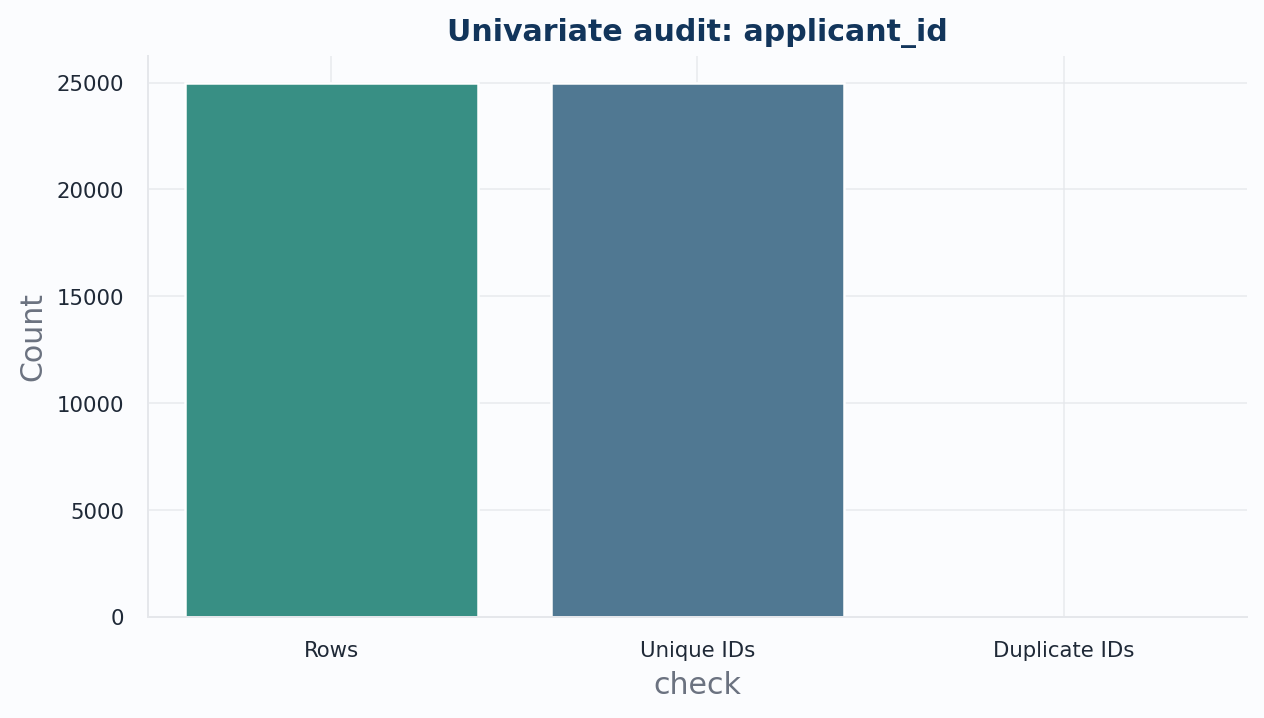

In [44]:
image_path = ROOT / 'outputs/figures/univariate_applicant_id.png'
display(Markdown("**Univariate plot: applicant_id**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>`applicant_id` has 25,000 unique values across 25,000 rows and 0 duplicate ID values.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The field is useful for audit traceability only and is excluded from modeling and app input because an identifier does not generalize to new applicants.</span>
    </div>

</div>

**Univariate plot: years_of_insurance_with_us**

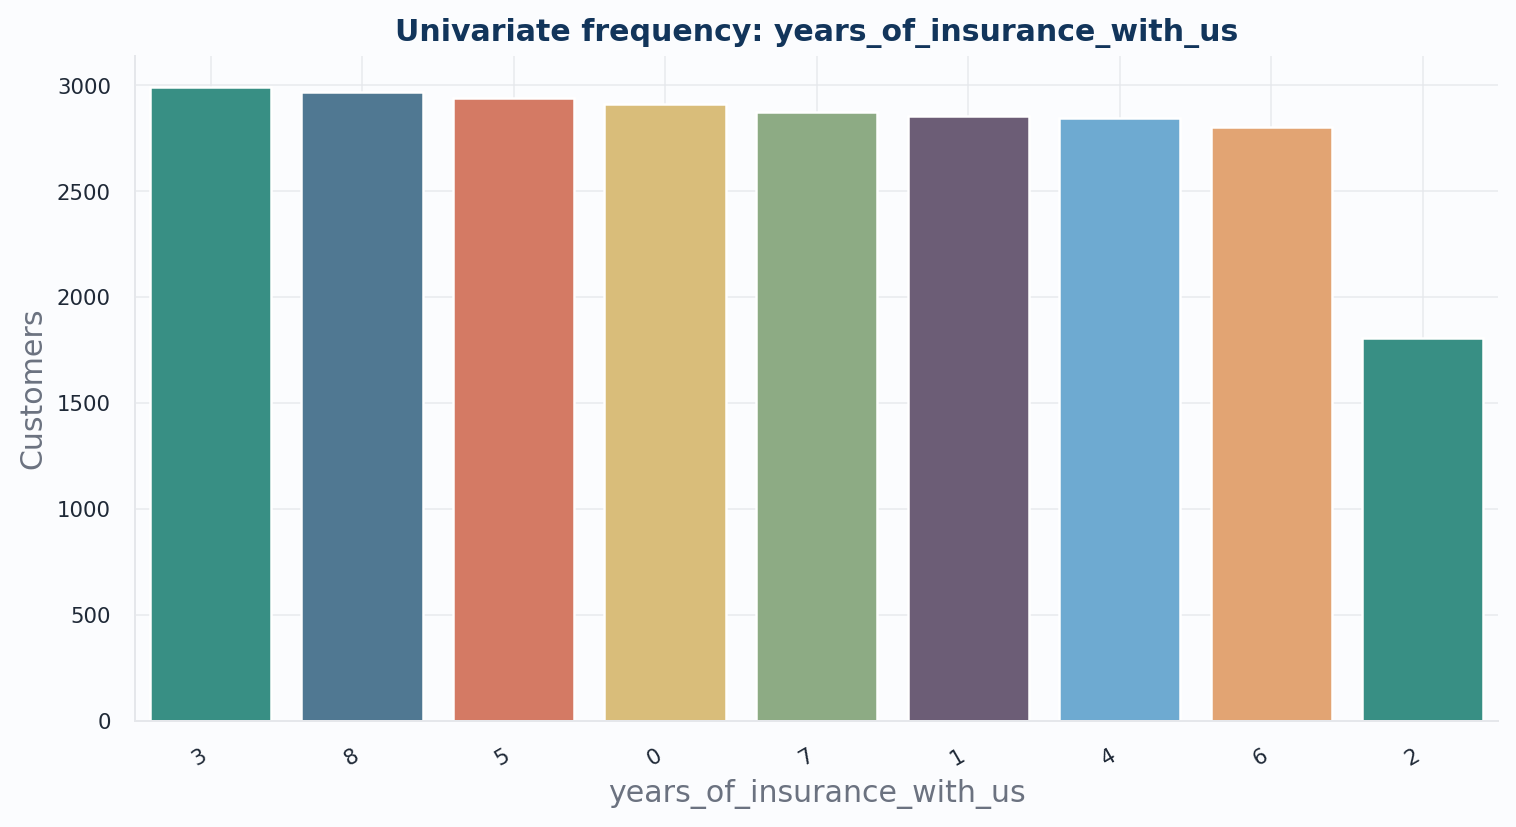

In [45]:
image_path = ROOT / 'outputs/figures/univariate_years_of_insurance_with_us.png'
display(Markdown("**Univariate plot: years_of_insurance_with_us**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>`years_of_insurance_with_us` has 9 non-missing levels and 0 missing values; the most frequent level is `3` at 12.0% of rows.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The frequency view checks whether `years_of_insurance_with_us` is balanced enough for EDA and downstream encoding; the preprocessing action is: validate type, preserve for EDA, and feed through modeling pipeline.</span>
    </div>

</div>

**Univariate plot: regular_checkup_last_year**

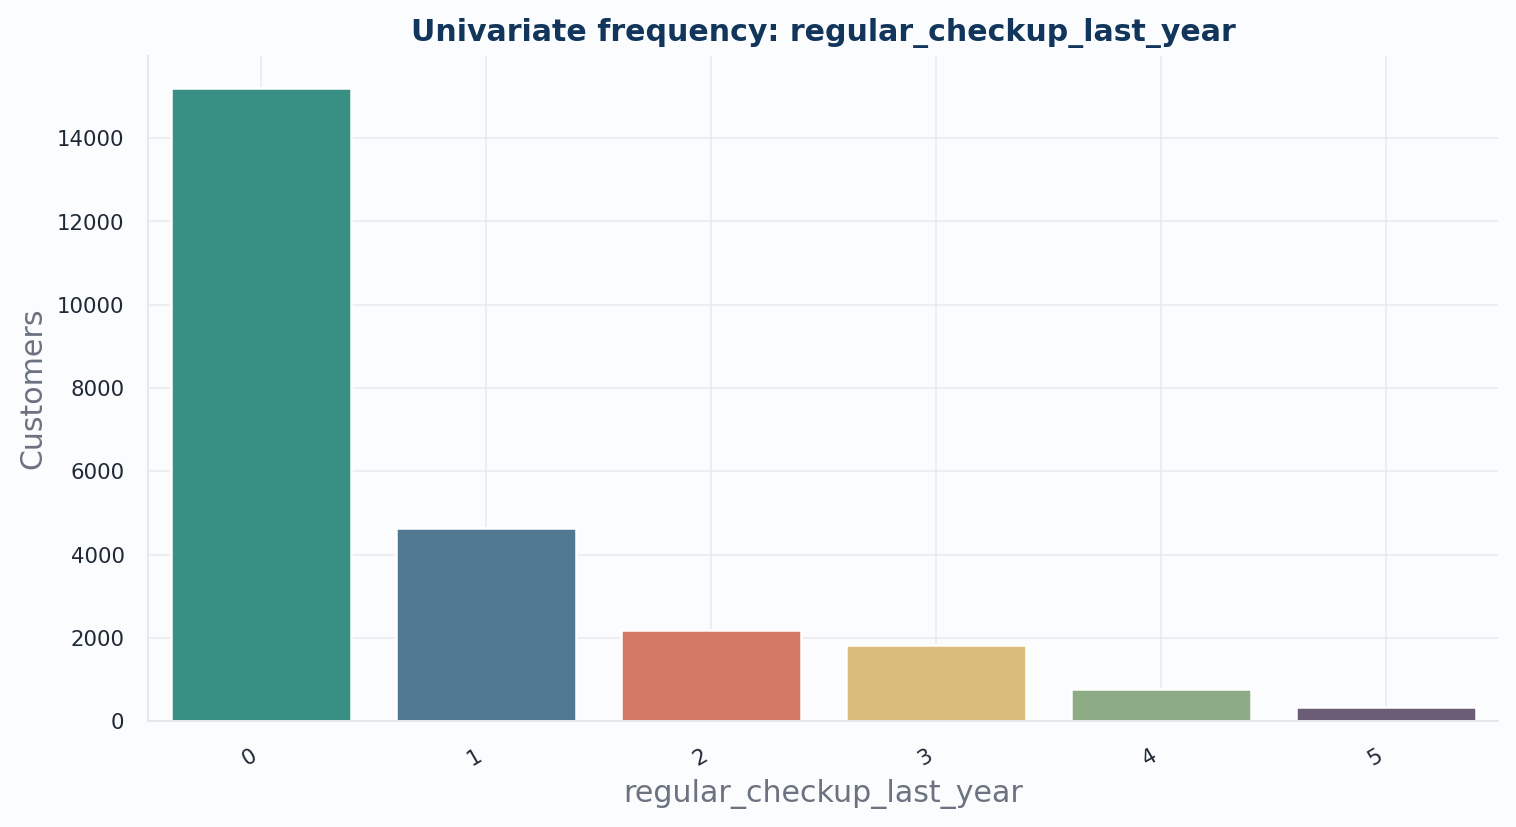

In [46]:
image_path = ROOT / 'outputs/figures/univariate_regular_checkup_last_year.png'
display(Markdown("**Univariate plot: regular_checkup_last_year**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>`regular_checkup_last_year` has 6 non-missing levels and 0 missing values; the most frequent level is `0` at 60.9% of rows.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The frequency view checks whether `regular_checkup_last_year` is balanced enough for EDA and downstream encoding; the preprocessing action is: normalize misspelled source name; preserve numeric/category meaning.</span>
    </div>

</div>

**Univariate plot: adventure_sports**

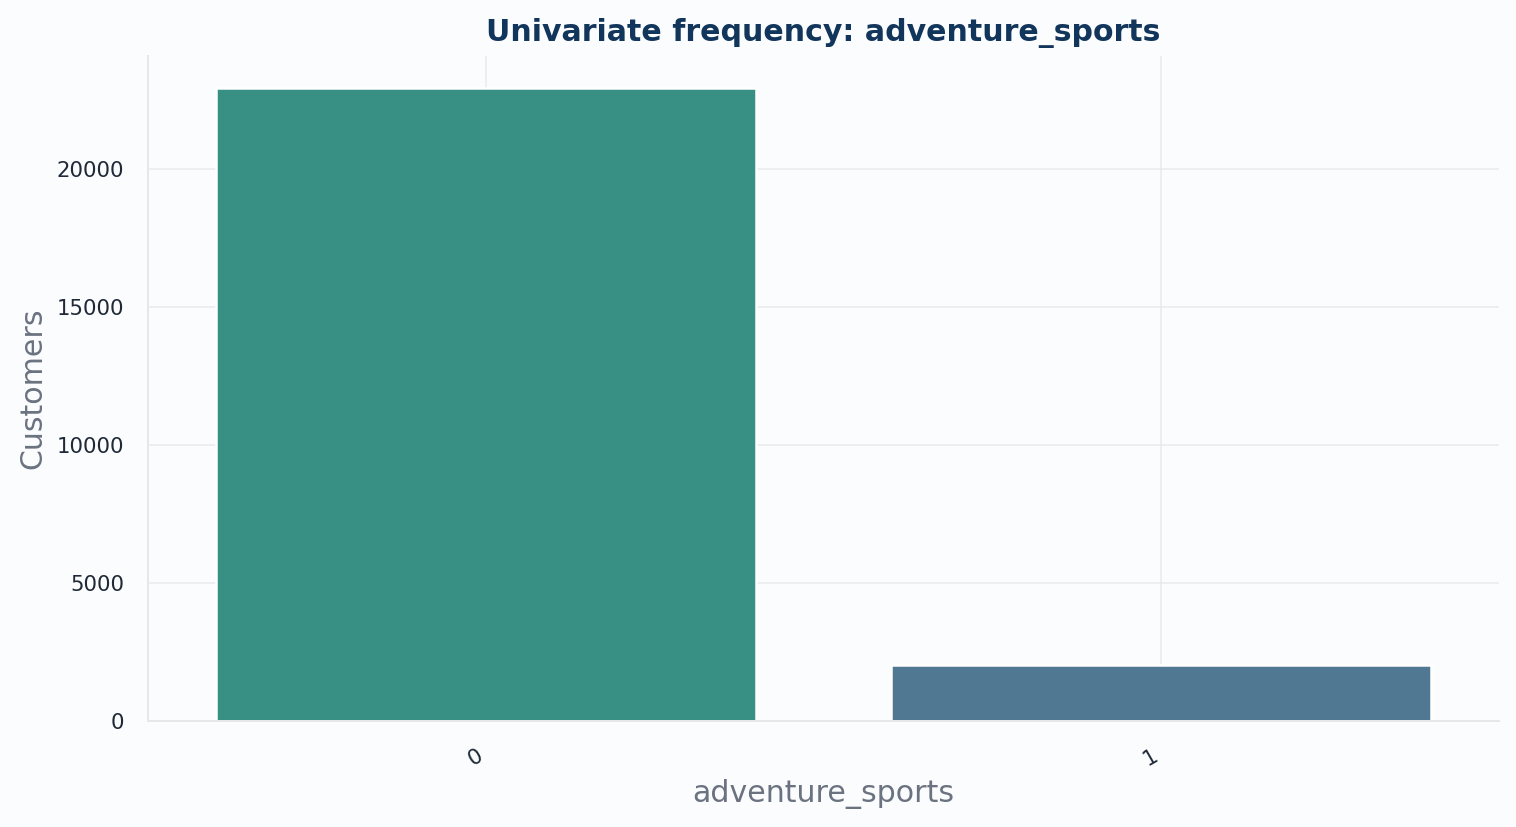

In [47]:
image_path = ROOT / 'outputs/figures/univariate_adventure_sports.png'
display(Markdown("**Univariate plot: adventure_sports**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>`adventure_sports` has 2 non-missing levels and 0 missing values; the most frequent level is `0` at 91.8% of rows.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The frequency view checks whether `adventure_sports` is balanced enough for EDA and downstream encoding; the preprocessing action is: validate type, preserve for EDA, and feed through modeling pipeline.</span>
    </div>

</div>

**Univariate plot: Occupation**

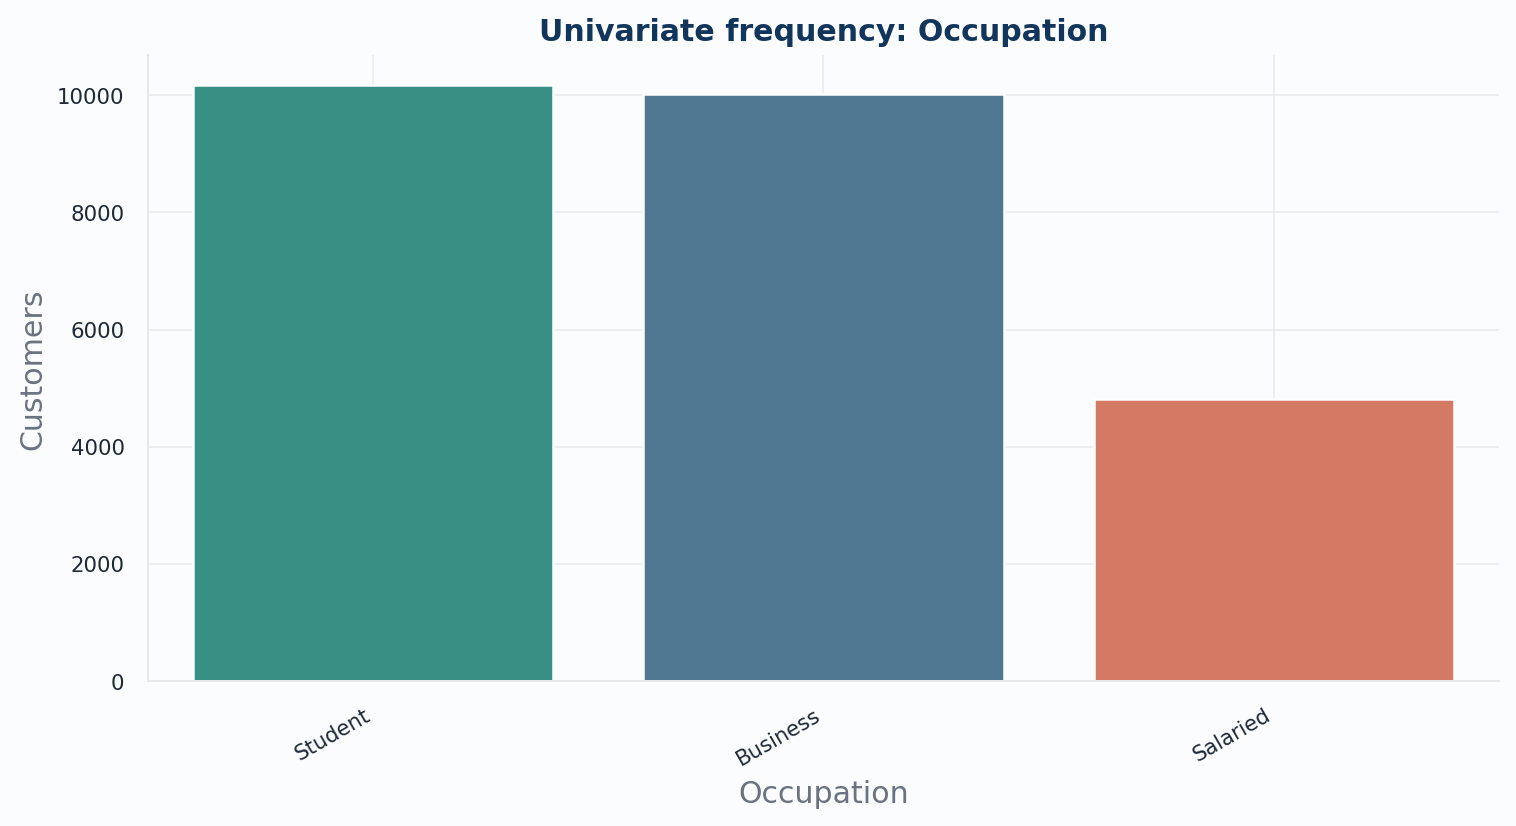

In [48]:
image_path = ROOT / 'outputs/figures/univariate_occupation.png'
display(Markdown("**Univariate plot: Occupation**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>`Occupation` has 3 non-missing levels and 0 missing values; the most frequent level is `Student` at 40.7% of rows.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The frequency view checks whether `Occupation` is balanced enough for EDA and downstream encoding; the preprocessing action is: validate type, preserve for EDA, and feed through modeling pipeline.</span>
    </div>

</div>

**Univariate plot: visited_doctor_last_1_year**

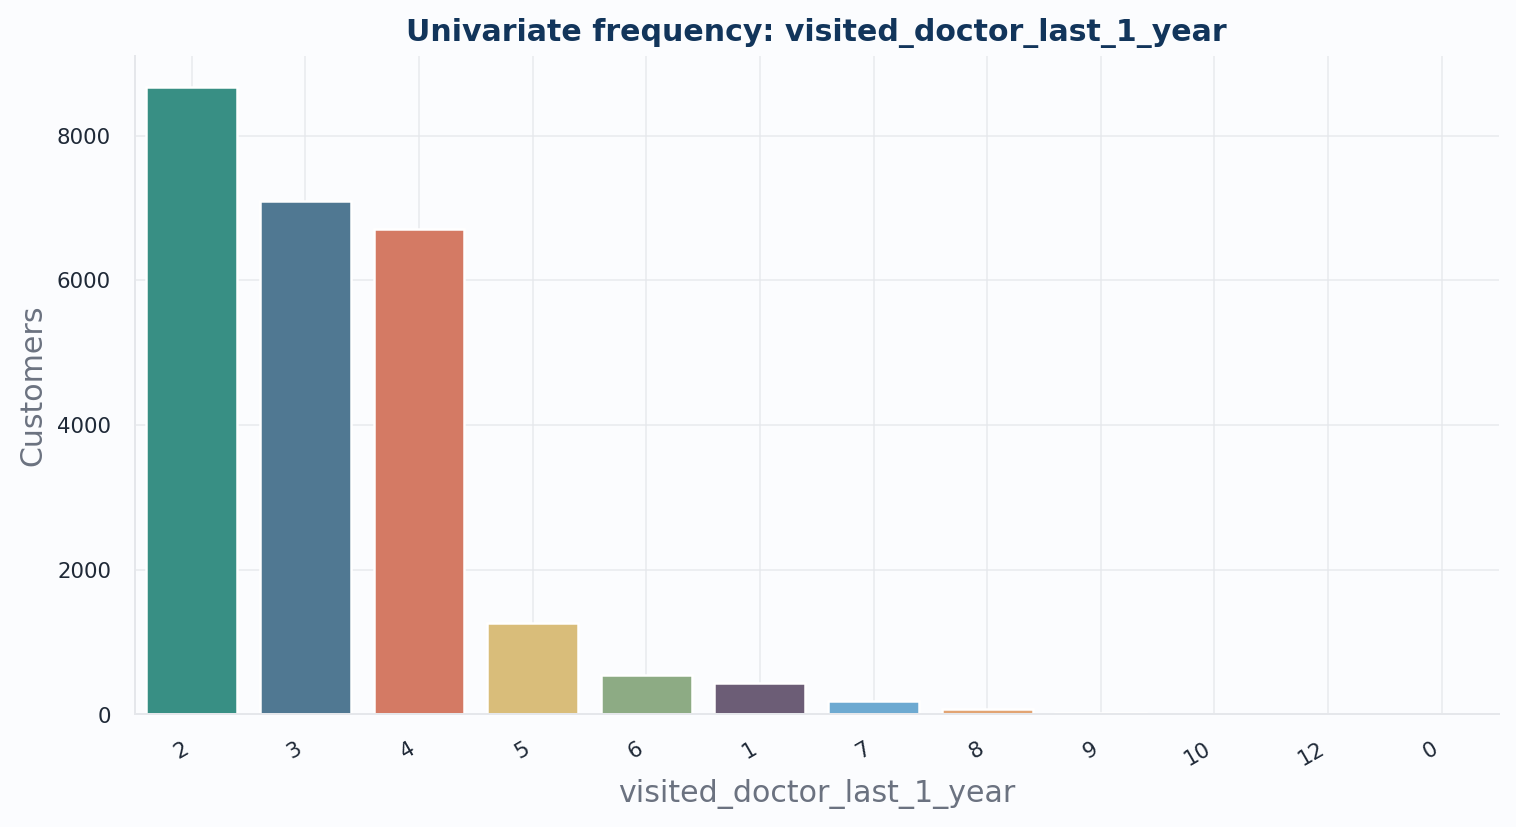

In [49]:
image_path = ROOT / 'outputs/figures/univariate_visited_doctor_last_1_year.png'
display(Markdown("**Univariate plot: visited_doctor_last_1_year**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>`visited_doctor_last_1_year` has 12 non-missing levels and 0 missing values; the most frequent level is `2` at 34.7% of rows.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The frequency view checks whether `visited_doctor_last_1_year` is balanced enough for EDA and downstream encoding; the preprocessing action is: validate type, preserve for EDA, and feed through modeling pipeline.</span>
    </div>

</div>

**Univariate plot: cholesterol_level**

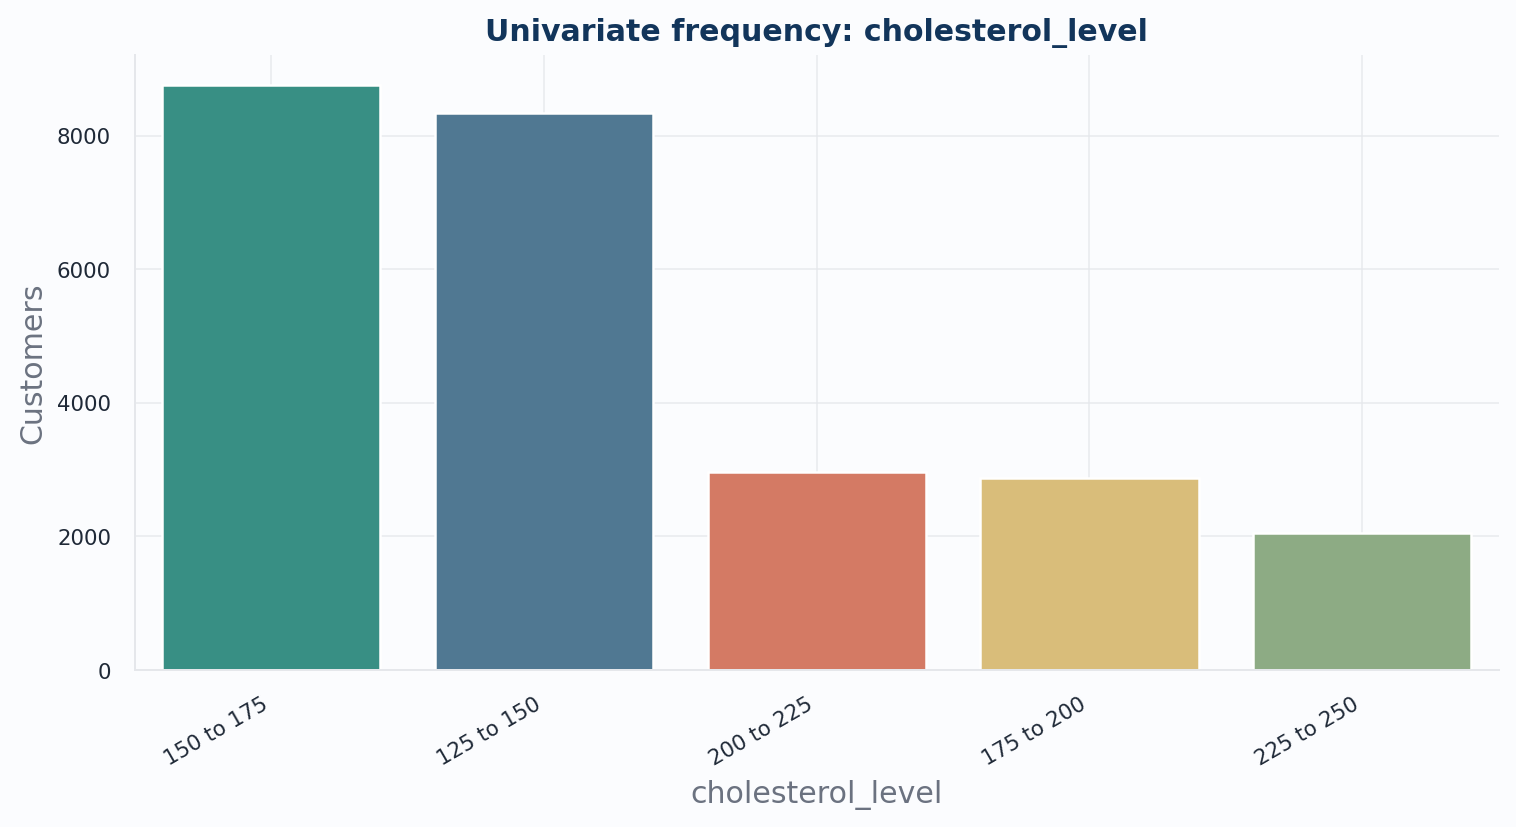

In [50]:
image_path = ROOT / 'outputs/figures/univariate_cholesterol_level.png'
display(Markdown("**Univariate plot: cholesterol_level**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>`cholesterol_level` has 5 non-missing levels and 0 missing values; the most frequent level is `150 to 175` at 35.1% of rows.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The frequency view checks whether `cholesterol_level` is balanced enough for EDA and downstream encoding; the preprocessing action is: retain ordinal category and engineer cholesterol midpoint.</span>
    </div>

</div>

**Univariate plot: daily_avg_steps**

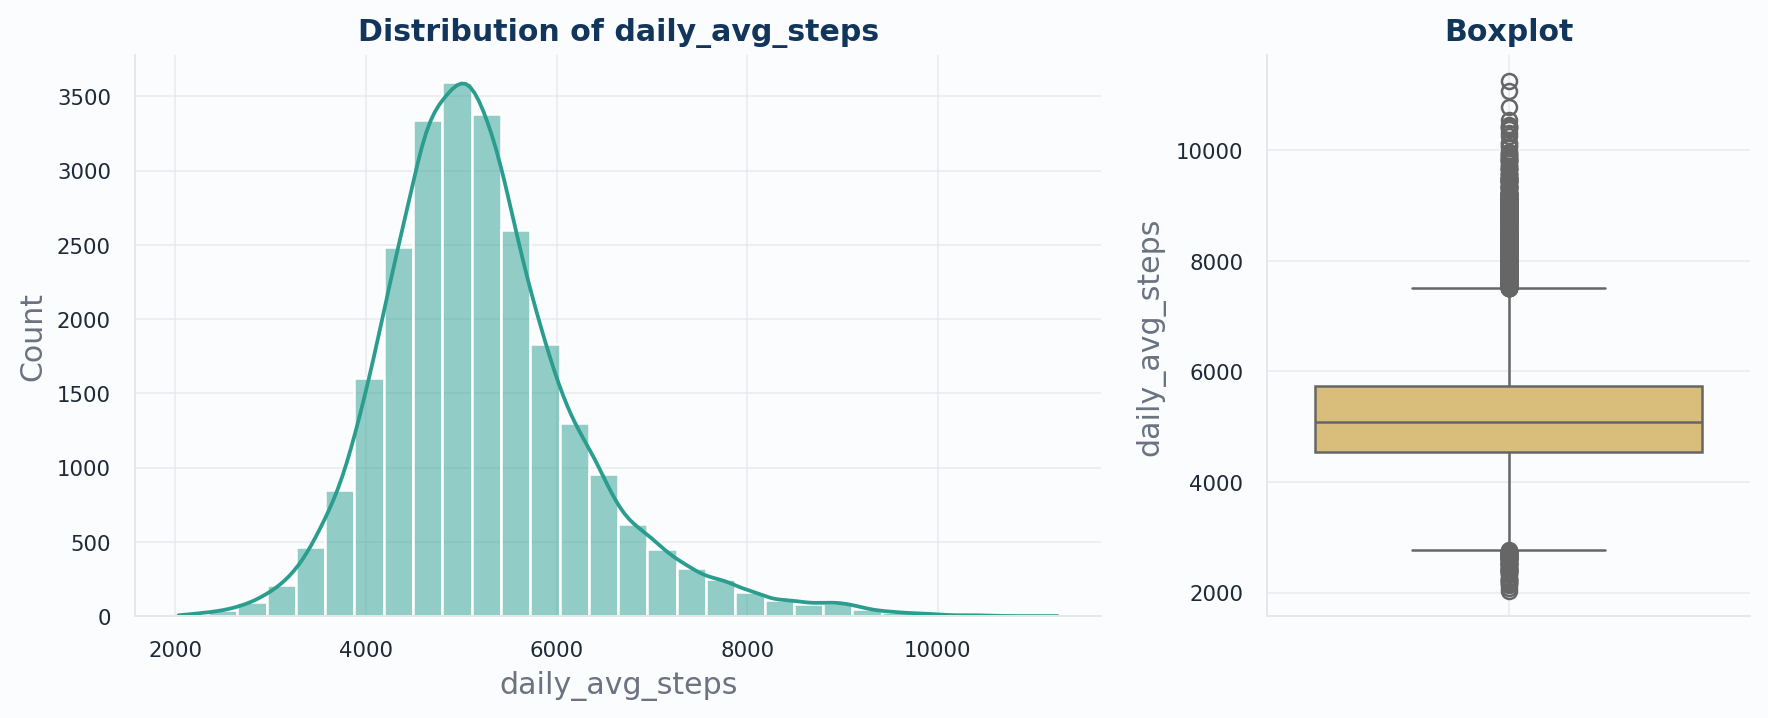

In [51]:
image_path = ROOT / 'outputs/figures/univariate_daily_avg_steps.png'
display(Markdown("**Univariate plot: daily_avg_steps**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>`daily_avg_steps` is numeric with 4,914 unique values, median 5,089.00, range 2,034.00 to 11,255.00, and 0 missing values.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The distribution documents the applicant spread for `daily_avg_steps` before modeling; the preprocessing action is: validate type, preserve for EDA, and feed through modeling pipeline.</span>
    </div>

</div>

**Univariate plot: age**

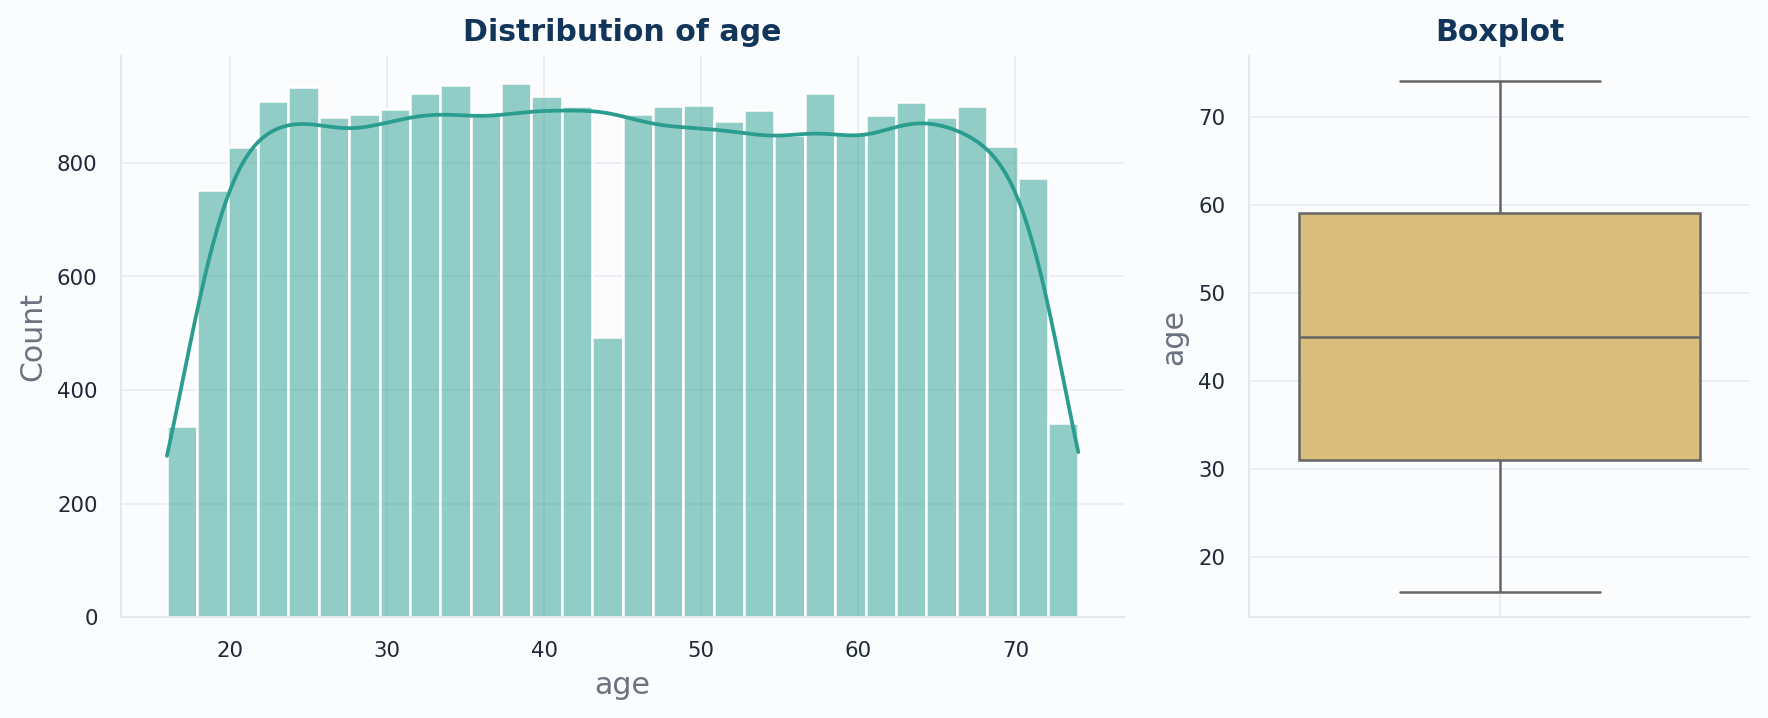

In [52]:
image_path = ROOT / 'outputs/figures/univariate_age.png'
display(Markdown("**Univariate plot: age**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>`age` is numeric with 59 unique values, median 45.00, range 16.00 to 74.00, and 0 missing values.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The distribution documents the applicant spread for `age` before modeling; the preprocessing action is: validate type, preserve for EDA, and feed through modeling pipeline.</span>
    </div>

</div>

**Univariate plot: heart_disease_history**

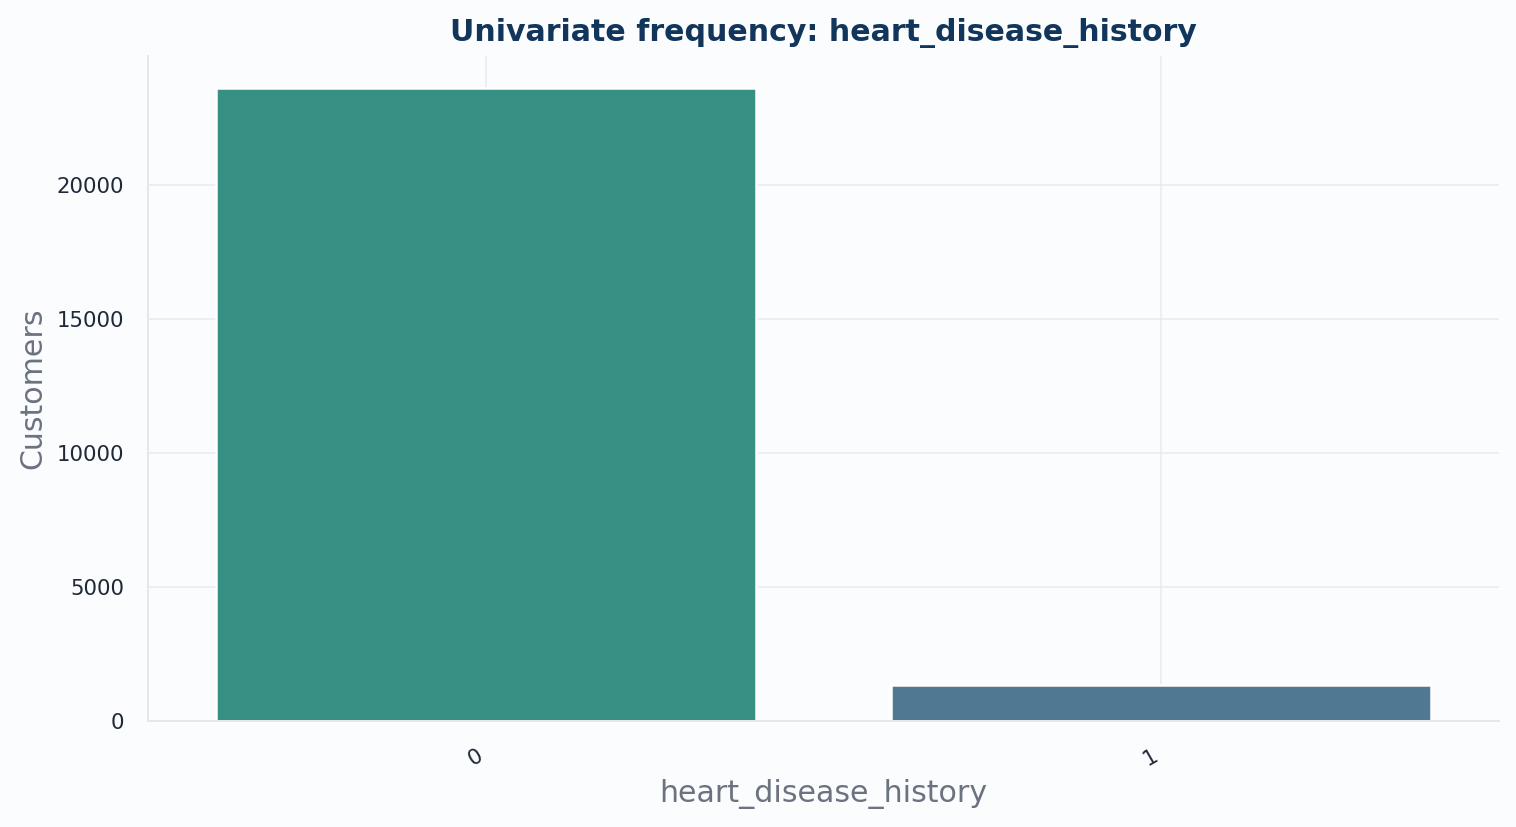

In [53]:
image_path = ROOT / 'outputs/figures/univariate_heart_disease_history.png'
display(Markdown("**Univariate plot: heart_disease_history**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>`heart_disease_history` has 2 non-missing levels and 0 missing values; the most frequent level is `0` at 94.5% of rows.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The frequency view checks whether `heart_disease_history` is balanced enough for EDA and downstream encoding; the preprocessing action is: normalize misspelled source name; preserve numeric/category meaning.</span>
    </div>

</div>

**Univariate plot: other_major_disease_history**

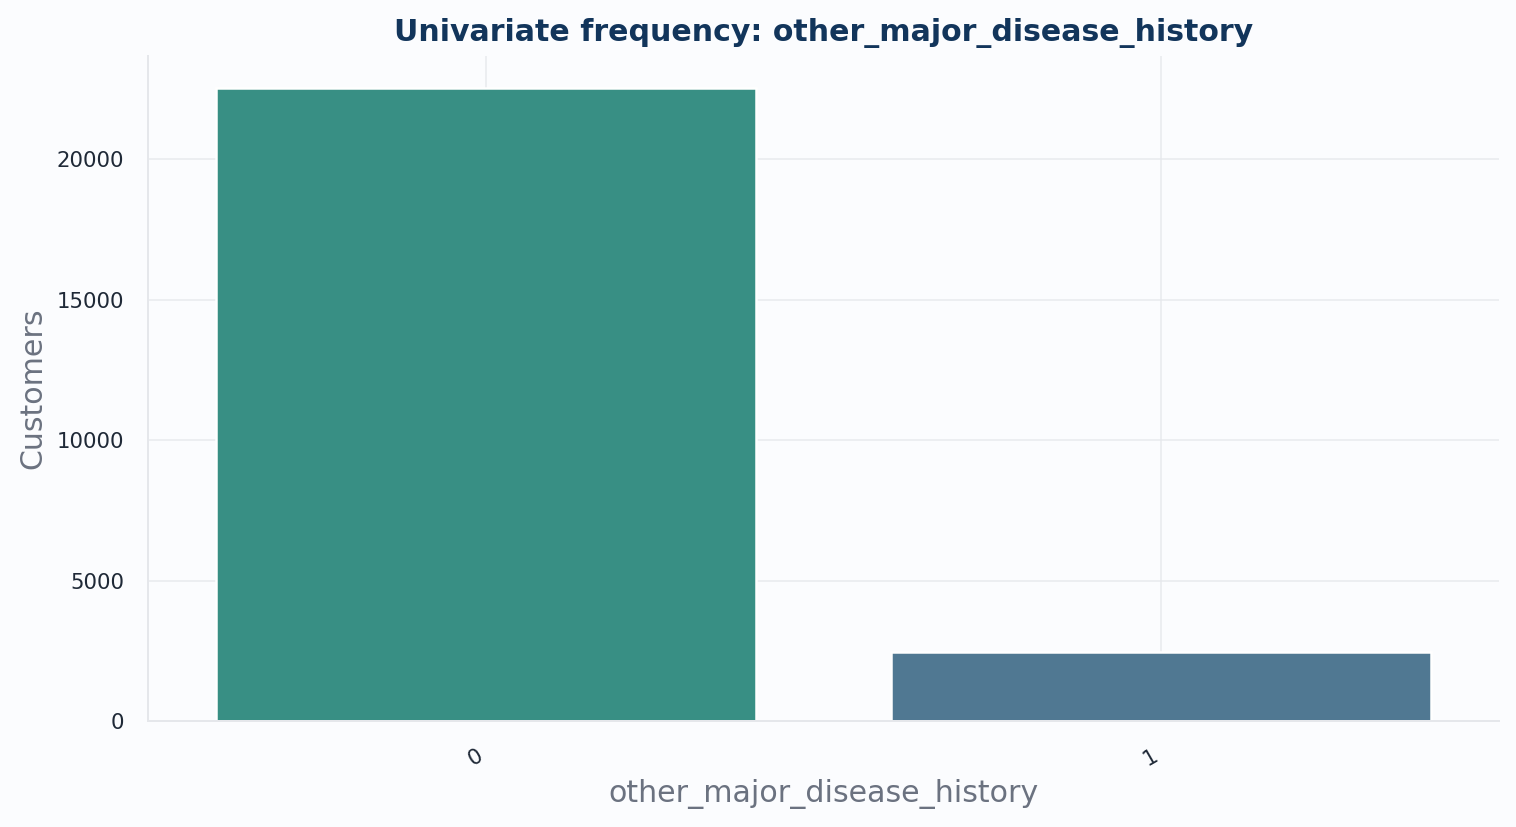

In [54]:
image_path = ROOT / 'outputs/figures/univariate_other_major_disease_history.png'
display(Markdown("**Univariate plot: other_major_disease_history**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>`other_major_disease_history` has 2 non-missing levels and 0 missing values; the most frequent level is `0` at 90.2% of rows.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The frequency view checks whether `other_major_disease_history` is balanced enough for EDA and downstream encoding; the preprocessing action is: normalize misspelled source name; preserve numeric/category meaning.</span>
    </div>

</div>

**Univariate plot: Gender**

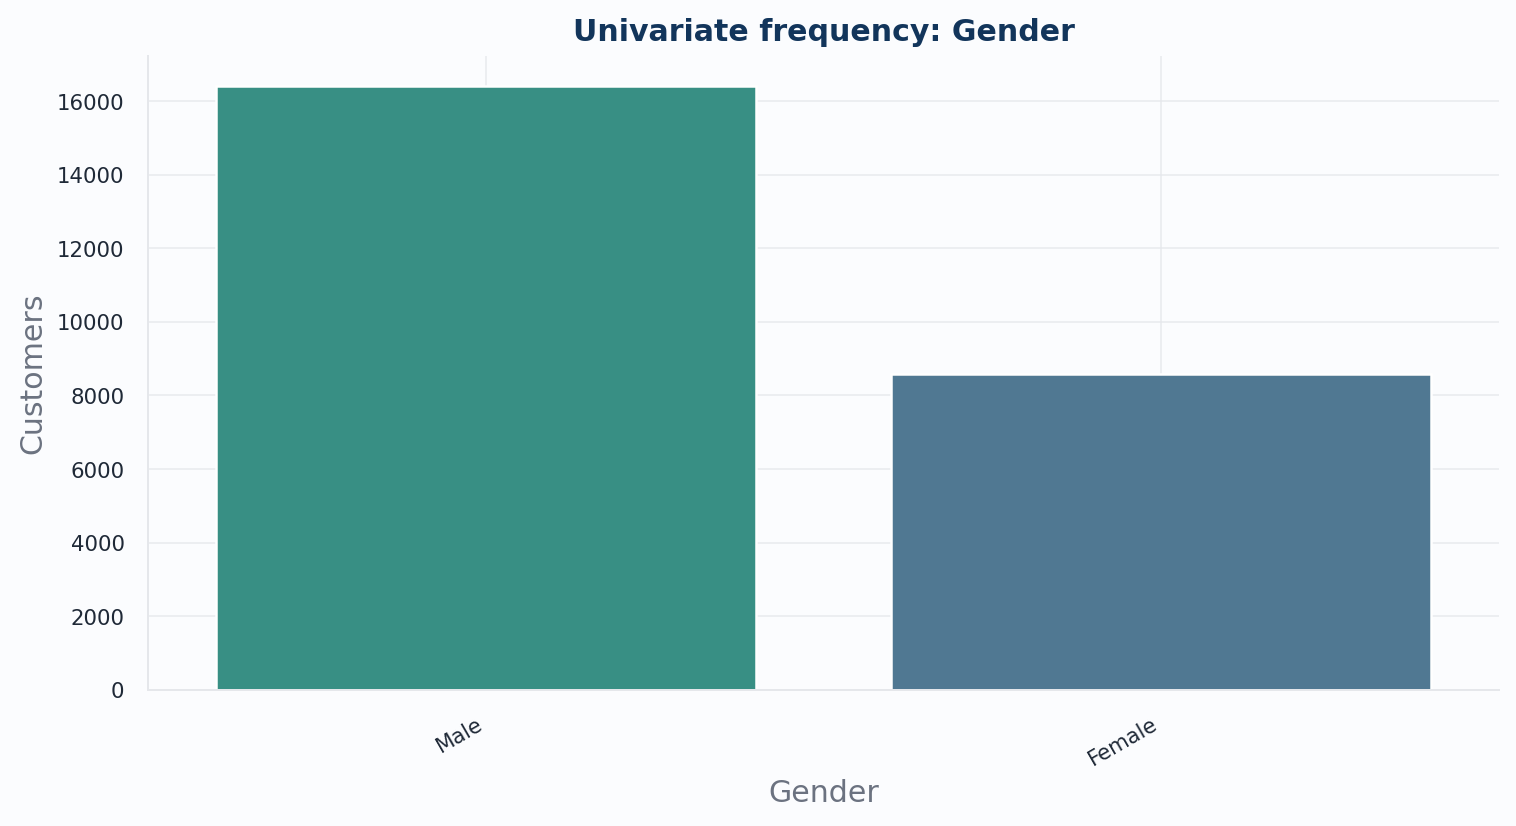

In [55]:
image_path = ROOT / 'outputs/figures/univariate_gender.png'
display(Markdown("**Univariate plot: Gender**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>`Gender` has 2 non-missing levels and 0 missing values; the most frequent level is `Male` at 65.7% of rows.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The frequency view checks whether `Gender` is balanced enough for EDA and downstream encoding; the preprocessing action is: validate type, preserve for EDA, and feed through modeling pipeline.</span>
    </div>

</div>

**Univariate plot: avg_glucose_level**

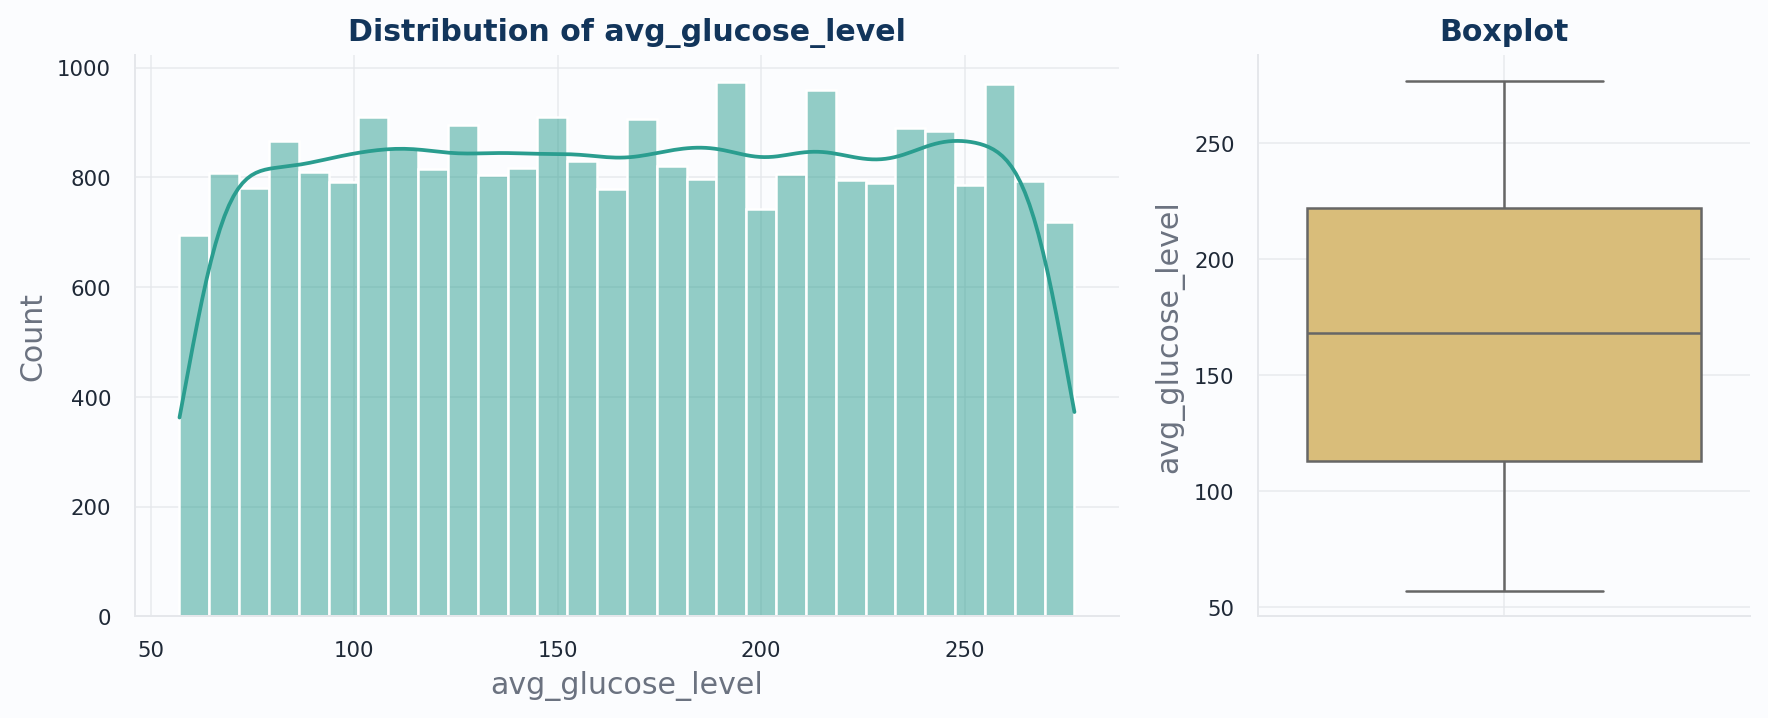

In [56]:
image_path = ROOT / 'outputs/figures/univariate_avg_glucose_level.png'
display(Markdown("**Univariate plot: avg_glucose_level**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>`avg_glucose_level` is numeric with 221 unique values, median 168.00, range 57.00 to 277.00, and 0 missing values.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The distribution documents the applicant spread for `avg_glucose_level` before modeling; the preprocessing action is: validate type, preserve for EDA, and feed through modeling pipeline.</span>
    </div>

</div>

**Univariate plot: bmi**

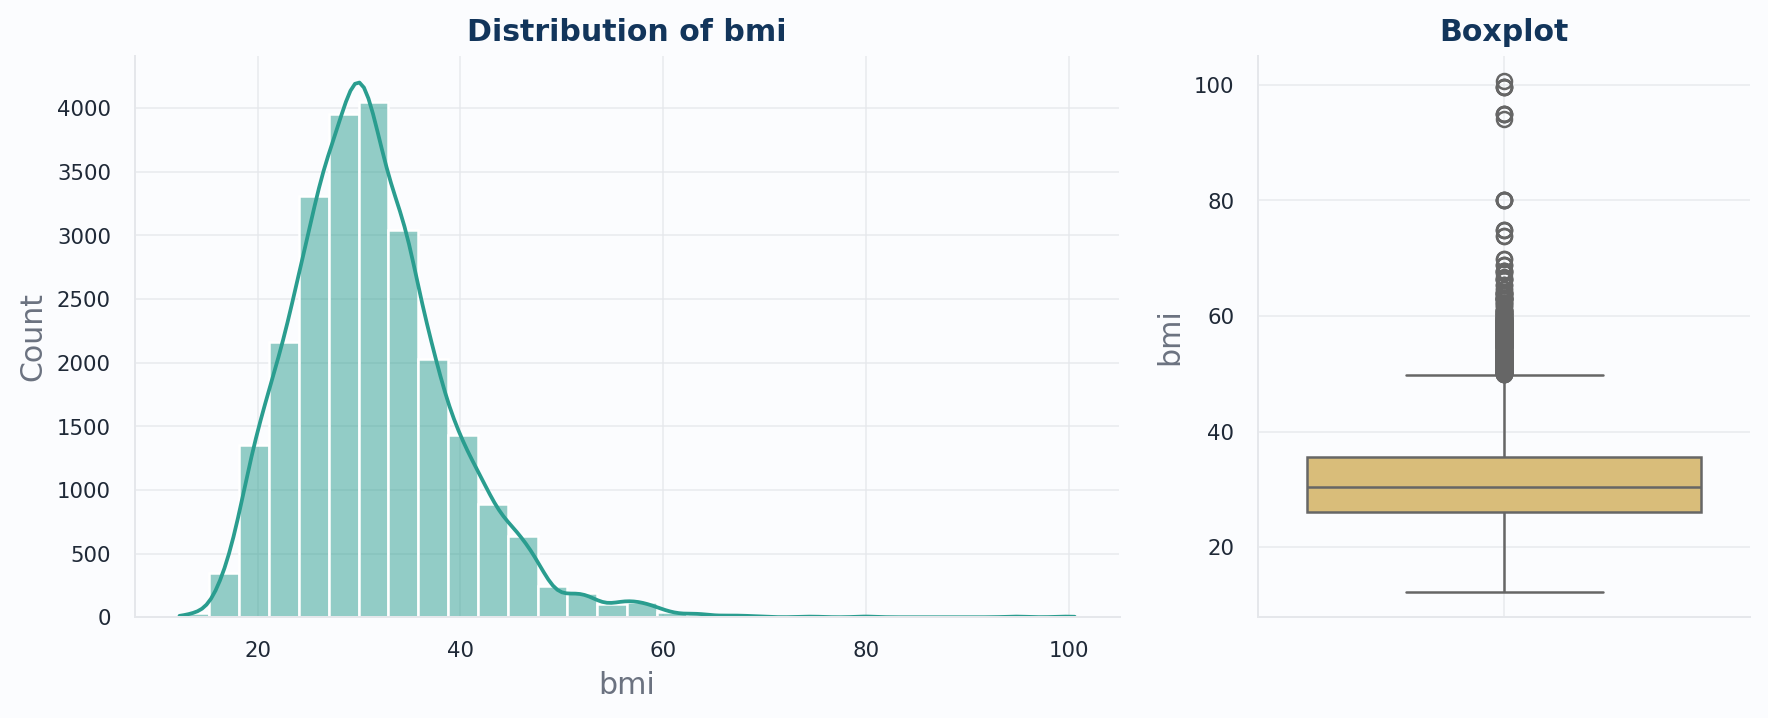

In [57]:
image_path = ROOT / 'outputs/figures/univariate_bmi.png'
display(Markdown("**Univariate plot: bmi**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>`bmi` is numeric with 465 unique values, median 30.50, range 12.30 to 100.60, and 990 missing values.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The distribution documents the applicant spread for `bmi` before modeling; the preprocessing action is: create missingness flag; impute using train-fitted median logic.</span>
    </div>

</div>

**Univariate plot: smoking_status**

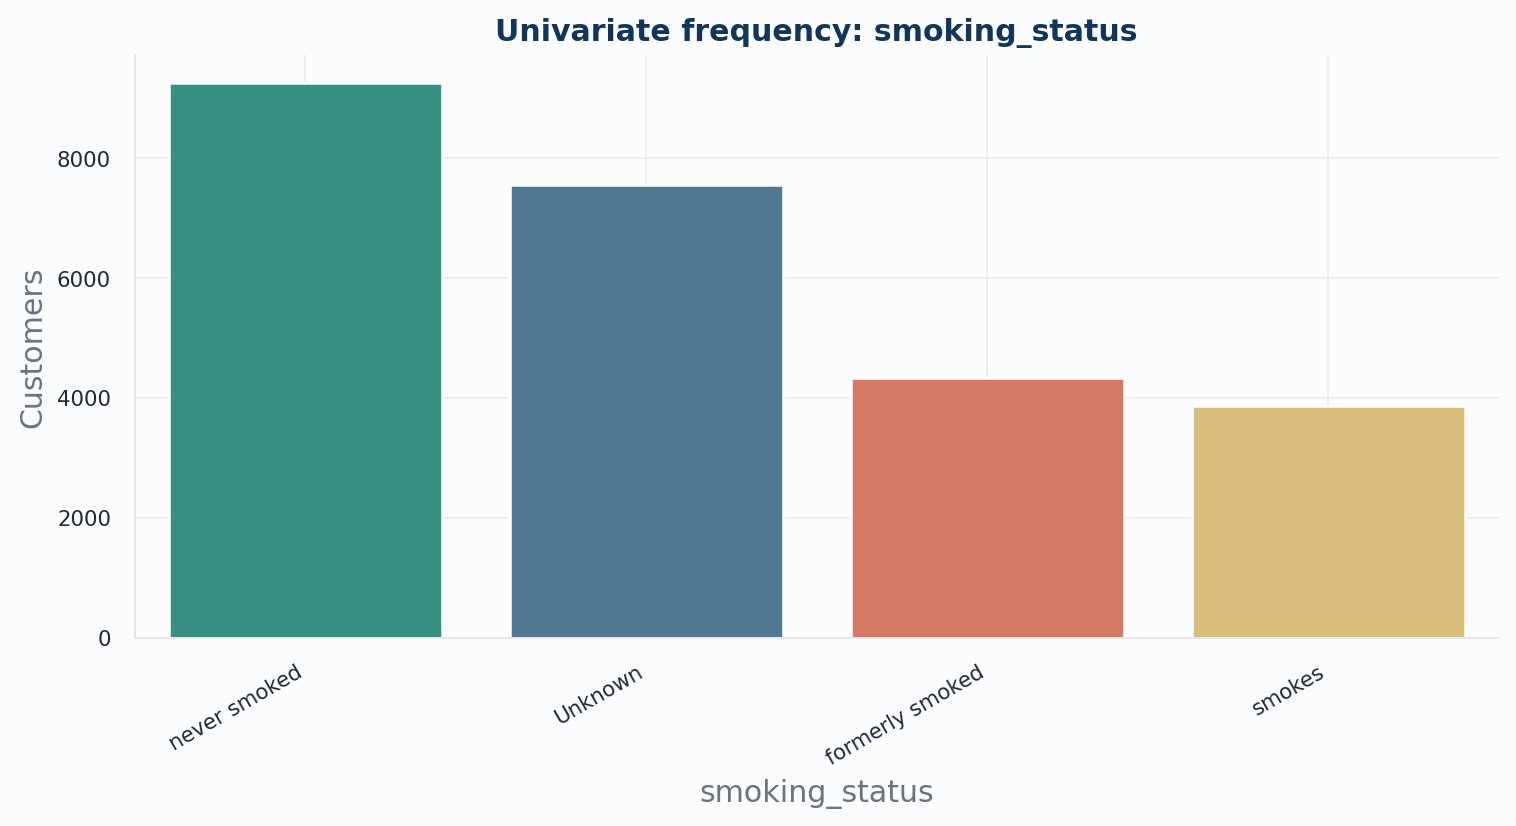

In [58]:
image_path = ROOT / 'outputs/figures/univariate_smoking_status.png'
display(Markdown("**Univariate plot: smoking_status**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>`smoking_status` has 4 non-missing levels and 0 missing values; the most frequent level is `never smoked` at 37.0% of rows.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The frequency view checks whether `smoking_status` is balanced enough for EDA and downstream encoding; the preprocessing action is: validate type, preserve for EDA, and feed through modeling pipeline.</span>
    </div>

</div>

**Univariate plot: Year_last_admitted**

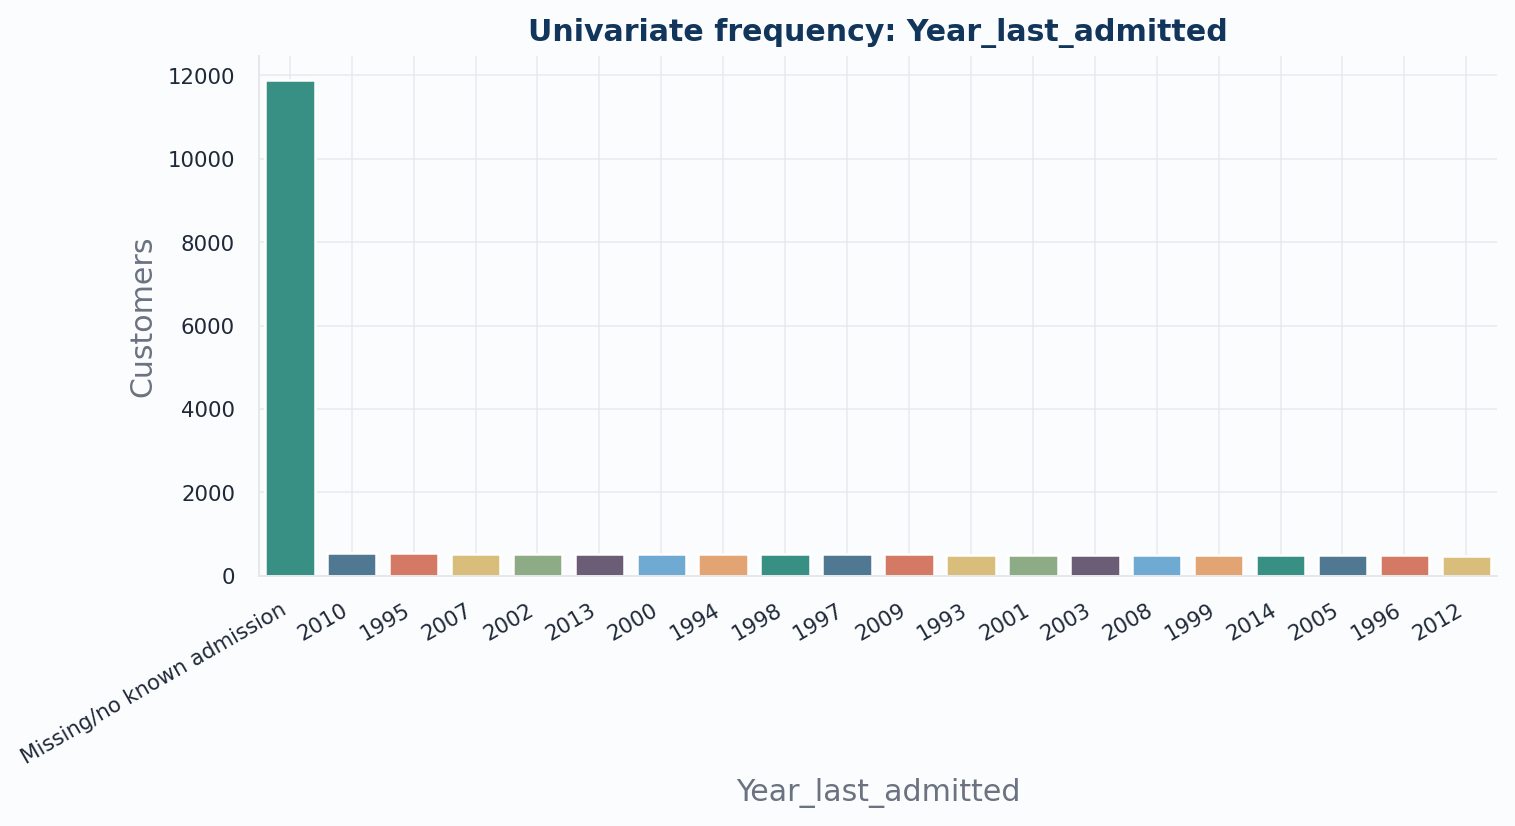

In [59]:
image_path = ROOT / 'outputs/figures/univariate_year_last_admitted.png'
display(Markdown("**Univariate plot: Year_last_admitted**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>`Year_last_admitted` has 29 non-missing levels and 11,881 missing values; the most frequent level is `Missing/no known admission` at 47.5% of rows.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The frequency view checks whether `Year_last_admitted` is balanced enough for EDA and downstream encoding; the preprocessing action is: create admission flags/status and recency; keep missingness signal.</span>
    </div>

</div>

**Univariate plot: Location**

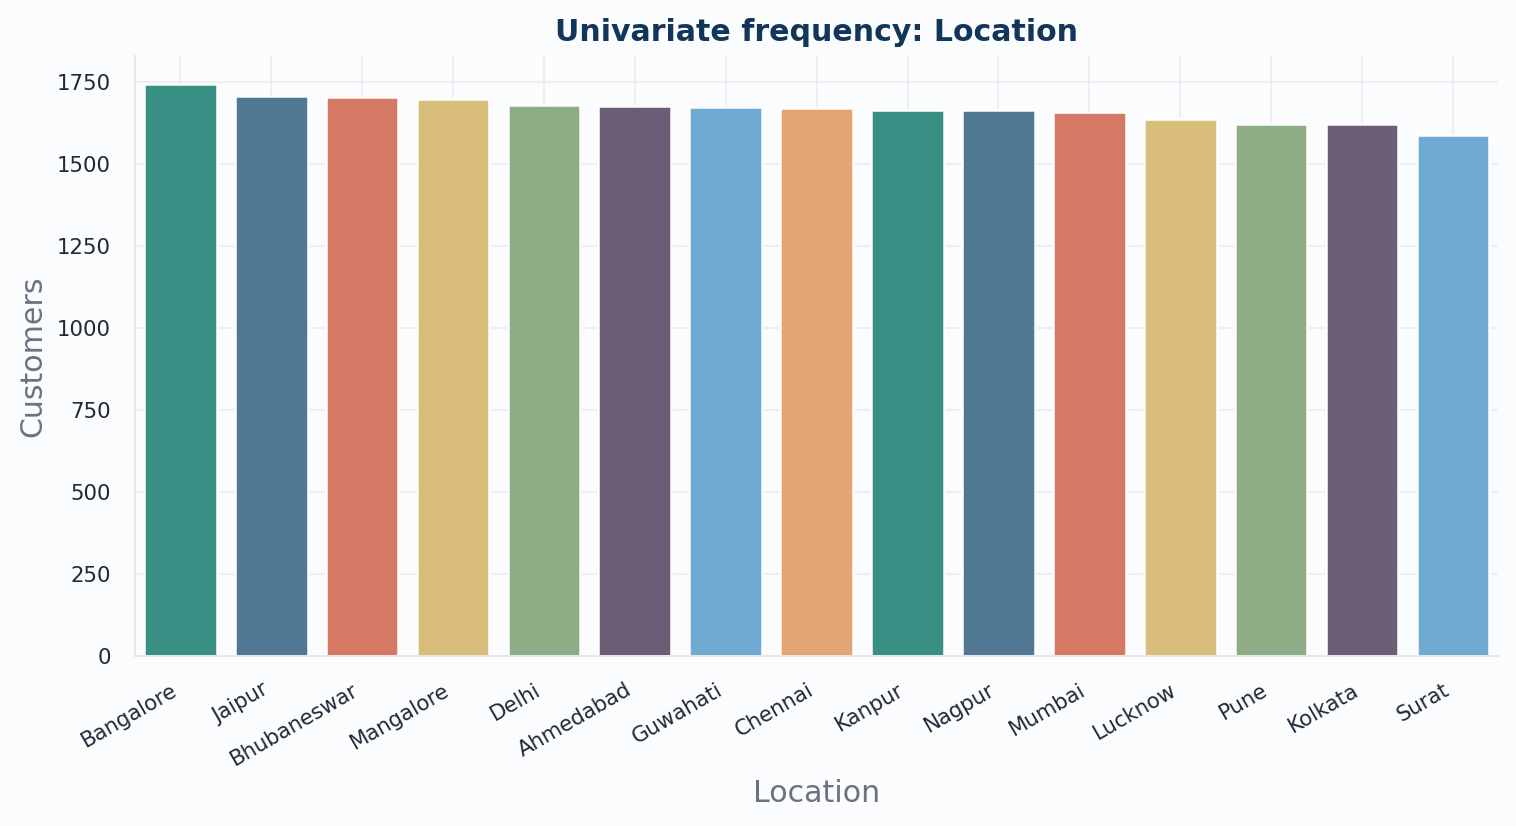

In [60]:
image_path = ROOT / 'outputs/figures/univariate_location.png'
display(Markdown("**Univariate plot: Location**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>`Location` has 15 non-missing levels and 0 missing values; the most frequent level is `Bangalore` at 7.0% of rows.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The frequency view checks whether `Location` is balanced enough for EDA and downstream encoding; the preprocessing action is: validate type, preserve for EDA, and feed through modeling pipeline.</span>
    </div>

</div>

**Univariate plot: weight**

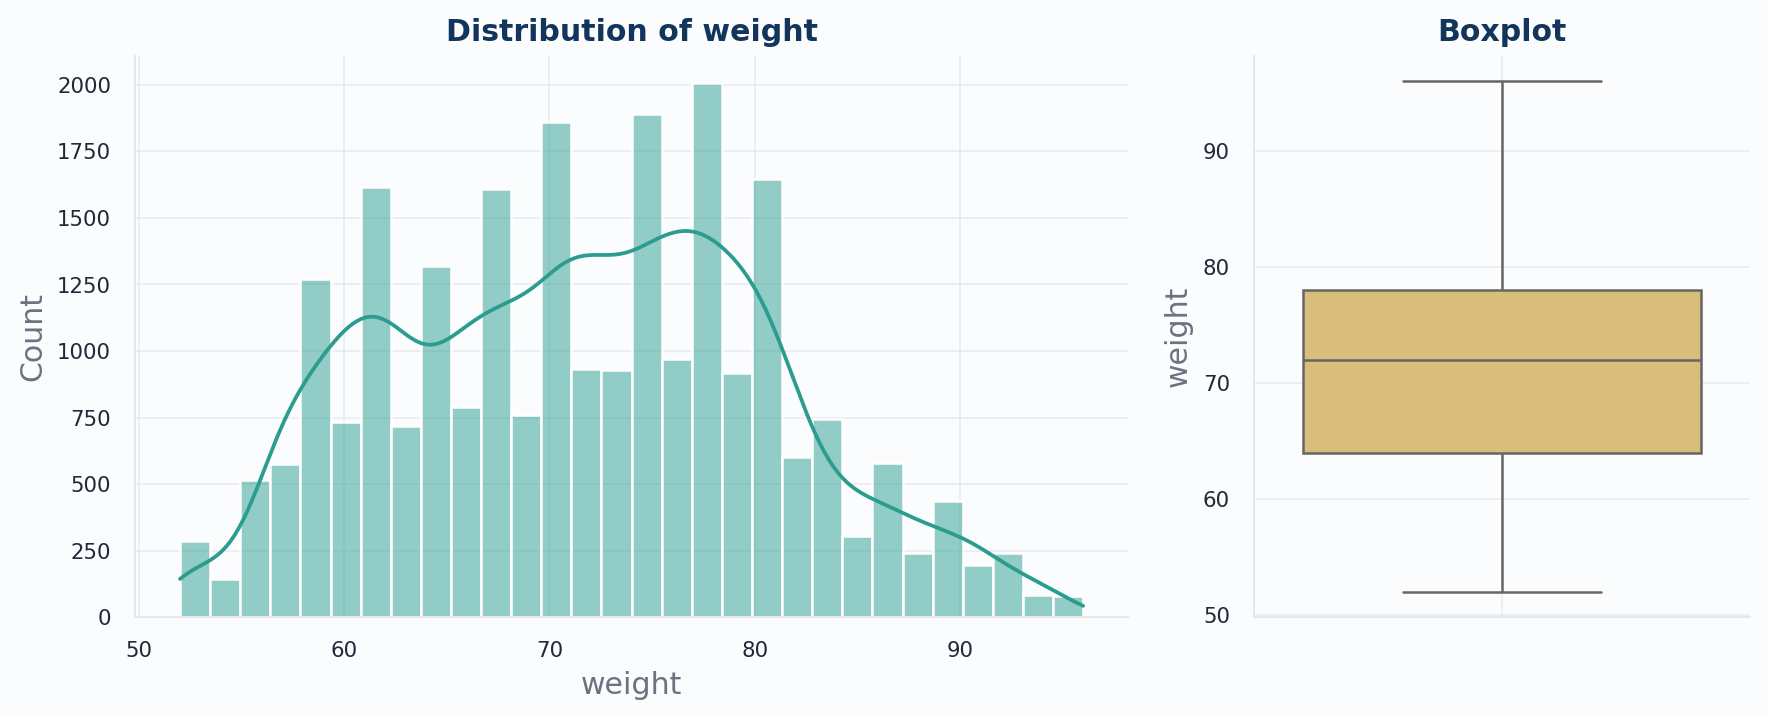

In [61]:
image_path = ROOT / 'outputs/figures/univariate_weight.png'
display(Markdown("**Univariate plot: weight**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>`weight` is numeric with 45 unique values, median 72.00, range 52.00 to 96.00, and 0 missing values.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The distribution documents the applicant spread for `weight` before modeling; the preprocessing action is: validate type, preserve for EDA, and feed through modeling pipeline.</span>
    </div>

</div>

**Univariate plot: covered_by_any_other_company**

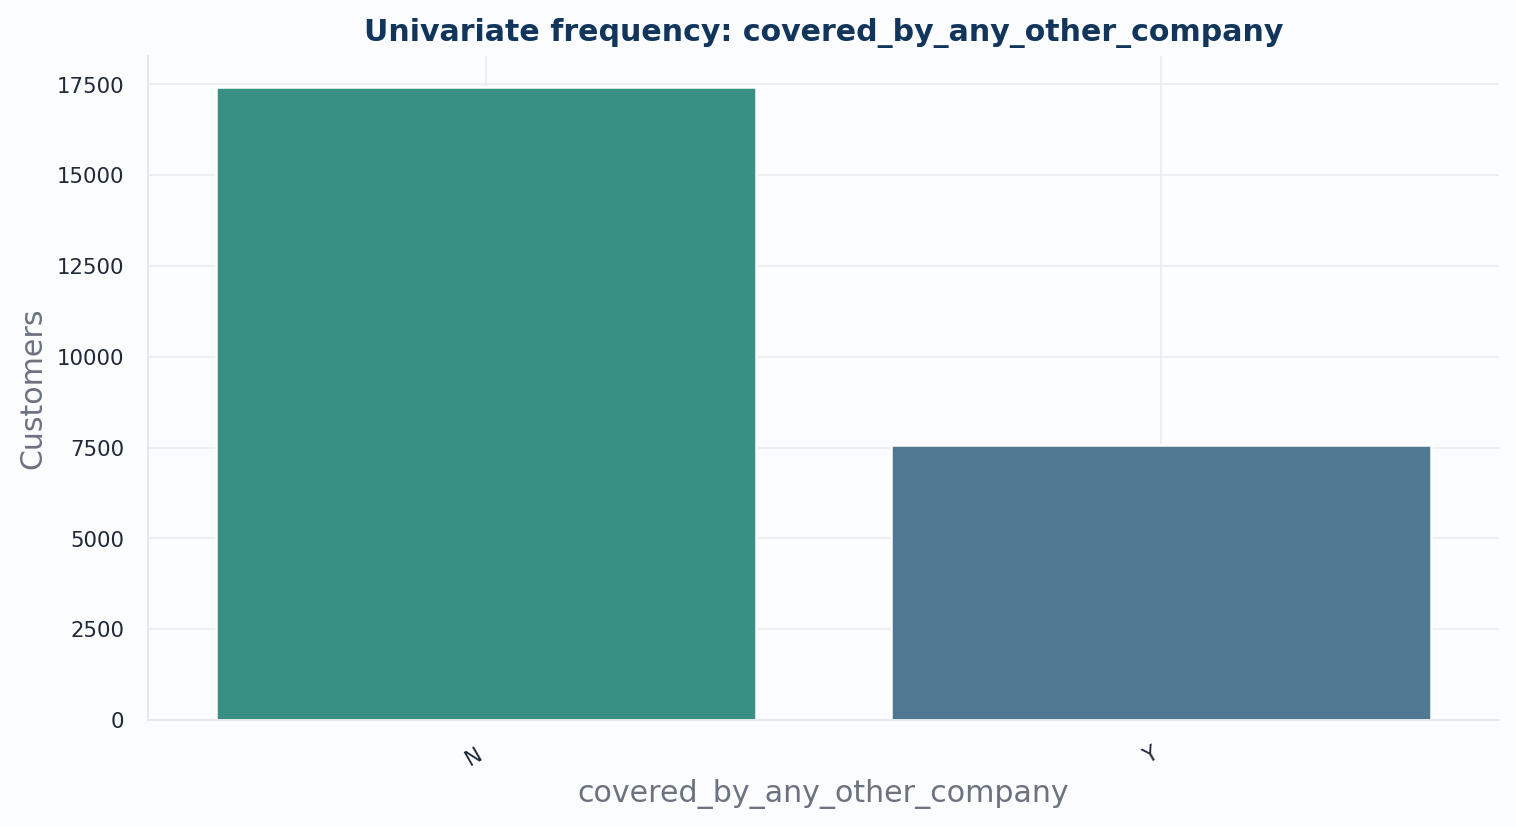

In [62]:
image_path = ROOT / 'outputs/figures/univariate_covered_by_any_other_company.png'
display(Markdown("**Univariate plot: covered_by_any_other_company**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>`covered_by_any_other_company` has 2 non-missing levels and 0 missing values; the most frequent level is `N` at 69.7% of rows.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The frequency view checks whether `covered_by_any_other_company` is balanced enough for EDA and downstream encoding; the preprocessing action is: validate type, preserve for EDA, and feed through modeling pipeline.</span>
    </div>

</div>

**Univariate plot: Alcohol**

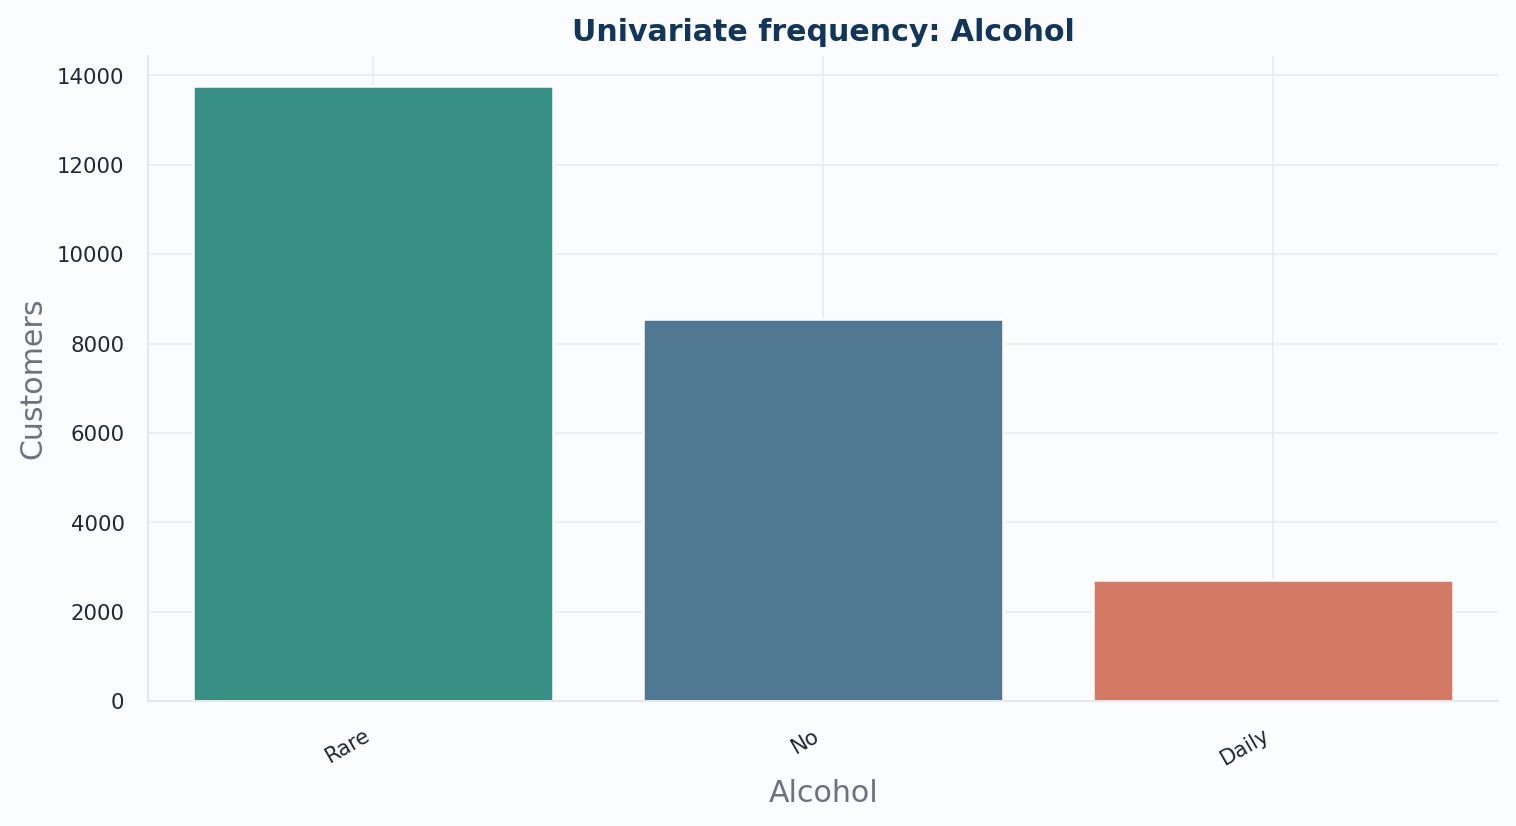

In [63]:
image_path = ROOT / 'outputs/figures/univariate_alcohol.png'
display(Markdown("**Univariate plot: Alcohol**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>`Alcohol` has 3 non-missing levels and 0 missing values; the most frequent level is `Rare` at 55.0% of rows.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The frequency view checks whether `Alcohol` is balanced enough for EDA and downstream encoding; the preprocessing action is: validate type, preserve for EDA, and feed through modeling pipeline.</span>
    </div>

</div>

**Univariate plot: exercise**

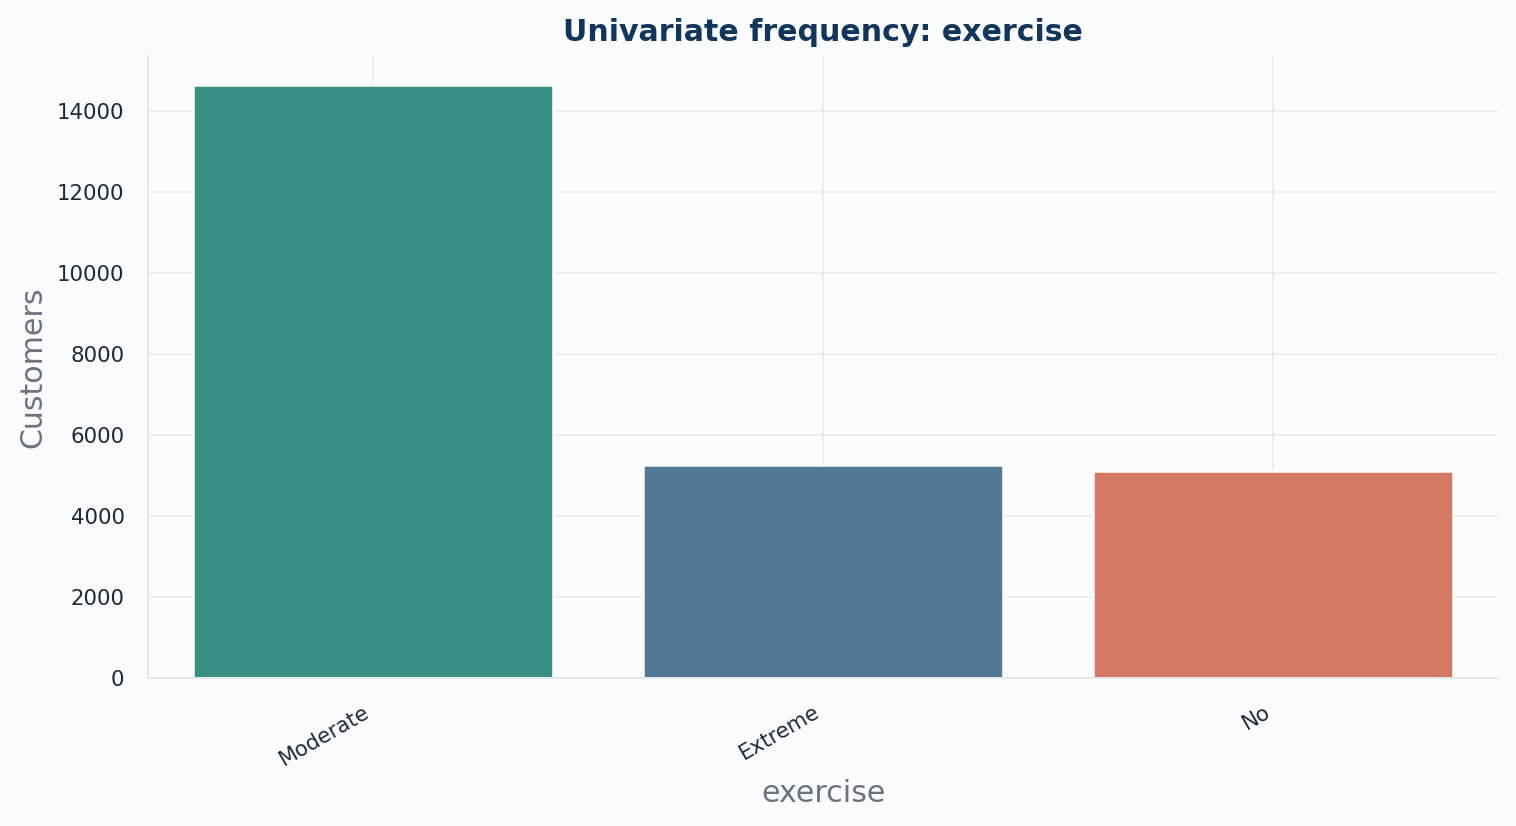

In [64]:
image_path = ROOT / 'outputs/figures/univariate_exercise.png'
display(Markdown("**Univariate plot: exercise**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>`exercise` has 3 non-missing levels and 0 missing values; the most frequent level is `Moderate` at 58.6% of rows.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The frequency view checks whether `exercise` is balanced enough for EDA and downstream encoding; the preprocessing action is: validate type, preserve for EDA, and feed through modeling pipeline.</span>
    </div>

</div>

**Univariate plot: weight_change_in_last_one_year**

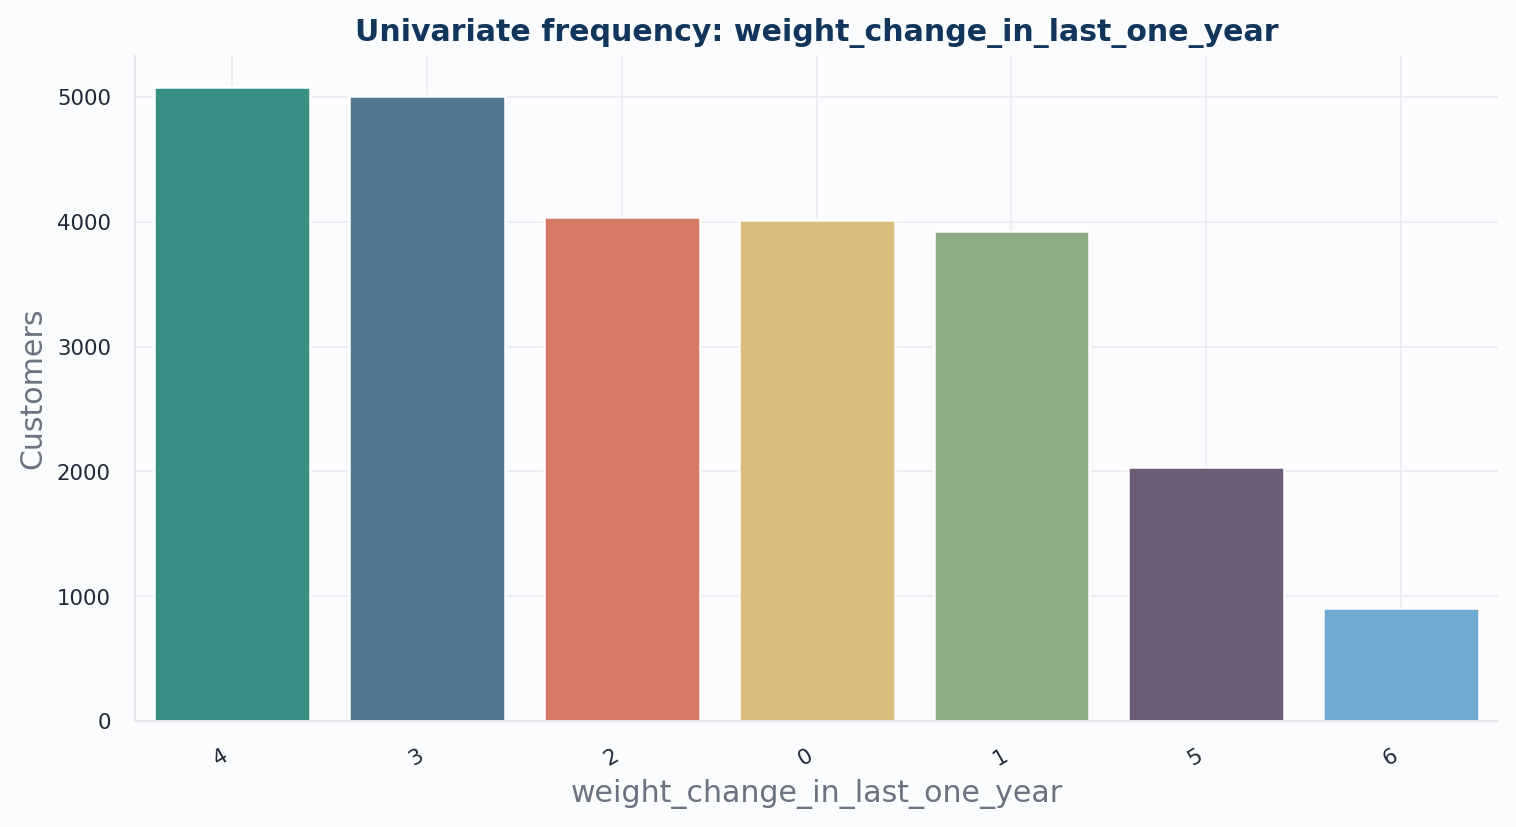

In [65]:
image_path = ROOT / 'outputs/figures/univariate_weight_change_in_last_one_year.png'
display(Markdown("**Univariate plot: weight_change_in_last_one_year**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>`weight_change_in_last_one_year` has 7 non-missing levels and 0 missing values; the most frequent level is `4` at 20.3% of rows.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The frequency view checks whether `weight_change_in_last_one_year` is balanced enough for EDA and downstream encoding; the preprocessing action is: validate type, preserve for EDA, and feed through modeling pipeline.</span>
    </div>

</div>

**Univariate plot: fat_percentage**

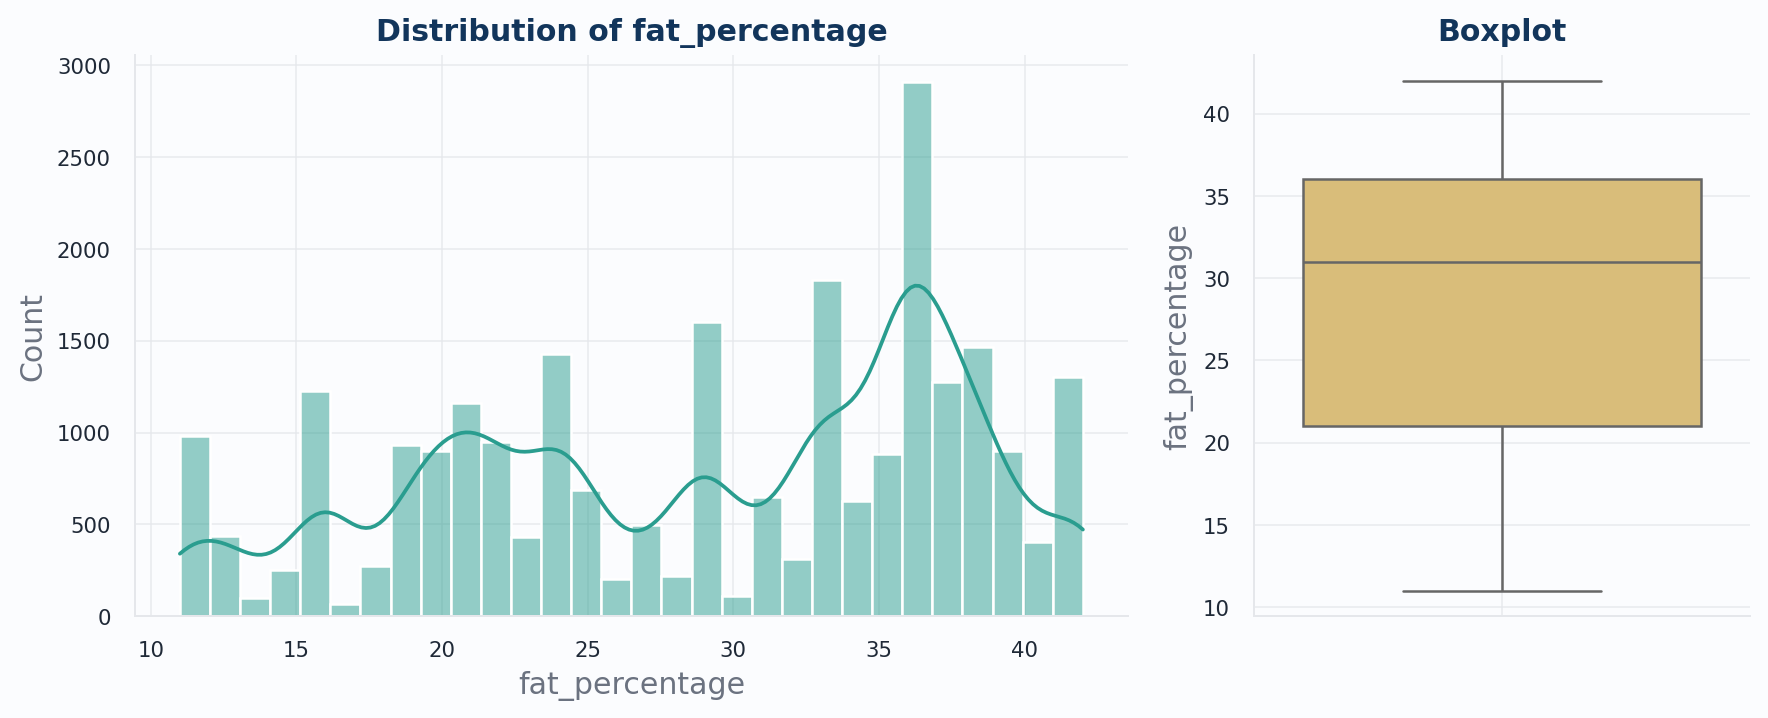

In [66]:
image_path = ROOT / 'outputs/figures/univariate_fat_percentage.png'
display(Markdown("**Univariate plot: fat_percentage**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>`fat_percentage` is numeric with 32 unique values, median 31.00, range 11.00 to 42.00, and 0 missing values.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The distribution documents the applicant spread for `fat_percentage` before modeling; the preprocessing action is: validate type, preserve for EDA, and feed through modeling pipeline.</span>
    </div>

</div>

**Univariate plot: insurance_cost**

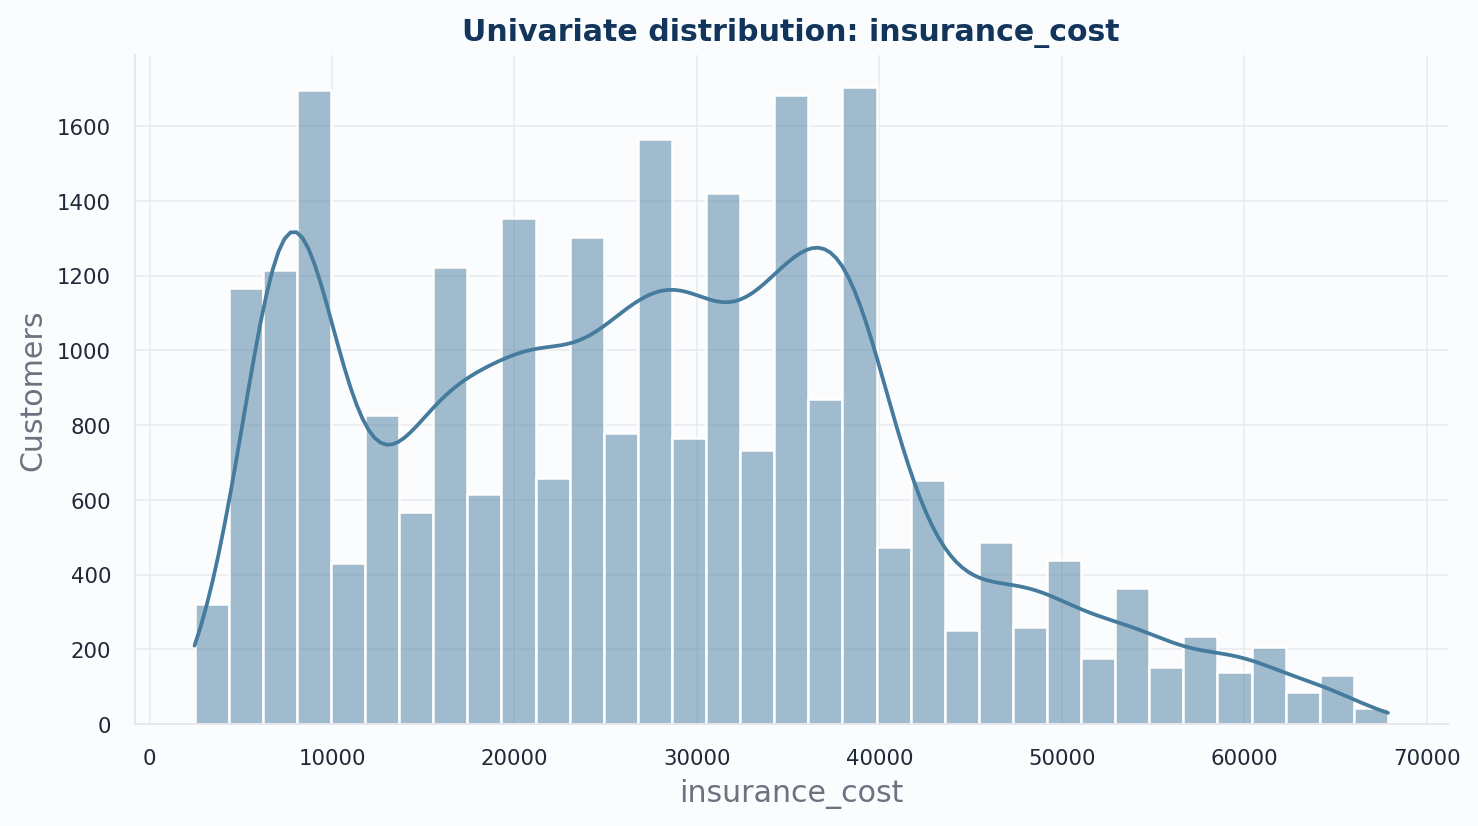

In [67]:
image_path = ROOT / 'outputs/figures/univariate_insurance_cost.png'
display(Markdown("**Univariate plot: insurance_cost**"))
if image_path.exists():
    display(Image(filename=str(image_path), width=700))
else:
    print(f"Missing image: {image_path}")

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>`insurance_cost` ranges from 2,468 to 67,870, has 54 unique quote bands, and a grid step of 1,234.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>This is the prediction target; it behaves like a fixed quote-band grid, so deployment should show both raw prediction and nearest valid quote band.</span>
    </div>

</div>

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>Other-company coverage has a visible mean-cost separation in the group summary.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>Coverage status should be explained as possible customer-history context, not as a causal premium rule.</span>
    </div>

</div>

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>Adventure-sports participation has clearer group separation than many lifestyle indicators.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>This flag is useful for risk context but should not drive an automatic decision alone.</span>
    </div>

</div>

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>Alcohol use has weak marginal separation in the current data.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The report should avoid claiming alcohol is a major standalone cost driver here.</span>
    </div>

</div>

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>Exercise category has weak marginal separation in the current data.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>Exercise is best treated as supporting applicant context rather than a headline driver.</span>
    </div>

</div>

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>BMI category is useful for descriptive health segmentation but does not dominate weight.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>Business interpretation should distinguish BMI context from the stronger weight gradient.</span>
    </div>

</div>

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>Disease-history flags show limited standalone signal in this dataset.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The field remains important for governance and monitoring despite weak marginal EDA.</span>
    </div>

</div>

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>Glucose and cholesterol are clinically intuitive but weak as individual EDA signals here.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The model may still use them in interactions, but the report should not overstate them.</span>
    </div>

</div>

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>Target tails are valid and belong to the same quote grid.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>Manual review is better than deleting high-premium cases.</span>
    </div>

</div>

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>Categorical frequencies confirm all major categories have enough representation for EDA.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>The reviewer can trust that segment comparisons are not purely anecdotal.</span>
    </div>

</div>

<div class="insight-card">
    <div class="insight-row">
        <span class="insight-label tech">Technical</span>
        <span>The preprocessing table ties each transformation to a data-quality or modeling-readiness reason.</span>
    </div>
    <div class="insight-row">
        <span class="insight-label biz">Business</span>
        <span>This makes the project easier to grade against the Milestone 1 rubric.</span>
    </div>

</div>